# Thesis - XAI

by Azhar Rafiq

Detection of intracranial haemorrhage (ICH) on non-contrast head CT, and the question of whether the explanations produced by such a detector point at the bleed.

ICH is a family diagnosis distinguished by where the blood collects. Bleeding within the brain tissue itself is termed intracerebral, or intraparenchymal haemorrhage (IPH). Blood entering the fluid-filled ventricles is intraventricular (IVH). The remaining three are extra-axial, meaning the blood lies outside the brain but still inside the skull, and each is named for the layer it occupies: epidural (EDH), subdural (SDH) and subarachnoid (SAH) (Benjamin & Karsonovich, 2026).

The notebook follows the order in which the work was carried out. Three CT datasets are loaded and examined; the RSNA volumes are preprocessed into a windowed cache; the models are specified here but trained on the cluster, because they do not fit in a notebook session; the artefacts each cluster job produced are verified; and the inferential statistics that answer the research questions are computed in the final sections from the per-slice results those jobs saved.

Three CT datasets are used, all held on BlueBEAR. RSNA 2019 supplies slice-level subtype labels at a scale sufficient for training a classifier, but carries no pixel annotation. PhysioNet CT-ICH and Seg-CQ500 are far smaller and supply binary pixel masks, which are the only means by which a saliency map can be scored against ground truth. That division of roles determines the structure of everything that follows: RSNA trains the classifiers, and the two mask datasets adjudicate their explanations.

Dataset in BlueBEAR:
- ✅[ downloaded] RSNA (kaggle.com/competitions/rsna-intracranial-hemorrhage-detection)
- ✅[ downloaded] PhysioNet (physionet.org/content/ct-ich/1.3.1/)
- ✅[ downloaded] Seg-CQ500 (zenodo.org/records/8063221)

In [1]:
#library
import os
from dotenv import load_dotenv

load_dotenv()

import sys
# check venv
print(sys.executable)

import glob
import json
import re

import numpy as np
import pandas as pd

import seaborn as sns
sns.set_style('darkgrid')
import matplotlib.pyplot as plt
from IPython.display import Image, display

import random

import tensorflow as tf
from tensorflow.keras import models, layers, losses, optimizers
from tensorflow.keras import callbacks

import sklearn
from sklearn.model_selection import GridSearchCV, StratifiedKFold, GroupShuffleSplit

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
from sklearn.utils.class_weight import compute_class_weight, compute_sample_weight
from sklearn.metrics import make_scorer, roc_auc_score, roc_curve, recall_score

import scikeras
from scikeras.wrappers import KerasClassifier
from skimage.transform import resize

import joblib

#

import pydicom
from pathlib import Path
import collections
from datetime import datetime

from iterstrat.ml_stratifiers import MultilabelStratifiedKFold

import nibabel as nib

import stats_utils as su

##

print("✅ Libraries imported succesfully\n")

print(f"🐍 Python Version: {sys.version.split()[0]}")
print(f"📖 Pandas Version: {pd.__version__}")
print(f"📖 Numpy Version: {np.__version__}")
print(f"📖 Seaborn Version: {sns.__version__}")

# print(f"📖 Tensorflow Version: {tf.__version__}")
print(f"📖 Joblib Version: {joblib.__version__}")

print(f"📖 PyDICOM Version: {pydicom.__version__}")
print(f"📖 nibabel Version: {nib.__version__}")

print(f"📖 Scikit-Learn Version: {sklearn.__version__}")
print(f"📖 scikeras Version: {scikeras.__version__}")



/rds/homes/a/axr1222/thesis-xai/thesis-venv/bin/python


I0000 00:00:1787471428.868898 1990222 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1787471428.875026 1990222 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1787471430.948647 1990222 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1787471447.997660 1990222 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them 

✅ Libraries imported succesfully

🐍 Python Version: 3.12.3
📖 Pandas Version: 3.0.2
📖 Numpy Version: 2.4.4
📖 Seaborn Version: 0.13.2
📖 Joblib Version: 1.5.3
📖 PyDICOM Version: 3.0.2
📖 nibabel Version: 5.4.2
📖 Scikit-Learn Version: 1.8.0
📖 scikeras Version: 0.13.0


## Datasets

### RSNA 2019

The competition data are already partitioned into `stage_2_train` and `stage_2_test` by the organisers. Only the training partition carries labels, which constrains the split strategy adopted later.

In [ ]:
# #import RSNA dataset

# import kagglehub
# kagglehub.login()


In [3]:
#specify dataset directory
os.environ['KAGGLEHUB_CACHE'] = os.getenv('KAGGLE_CACHE')
# os.makedirs(os.environ['KAGGLEHUB_CACHE'], exist_ok=True)

# rsnapath = kagglehub.competition_download('rsna-intracranial-hemorrhage-detection')
# rsnapath
# #files already downloaded

In [4]:
#load files
#files already separated by the RSNA Kaggle Challenge

BASE = Path('.')
RSNA_TRAIN_DIR = BASE / os.environ['KAGGLEHUB_CACHE'] / 'competitions/rsna-intracranial-hemorrhage-detection/rsna-intracranial-hemorrhage-detection/stage_2_train'
RSNA_TEST_DIR = BASE / os.environ['KAGGLEHUB_CACHE'] / 'competitions/rsna-intracranial-hemorrhage-detection/rsna-intracranial-hemorrhage-detection/stage_2_test'

labels_rsna_df = pd.read_csv(BASE / os.environ['KAGGLEHUB_CACHE'] / 'competitions/stage_2_train.csv')

#count RSNA training files
print(f'RSNA Train DICOMs: {len(list(RSNA_TRAIN_DIR.glob("*.dcm")))}')
print(f'RSNA Test DICOMs: {len(list(RSNA_TEST_DIR.glob("*.dcm")))}')

RSNA Train DICOMs: 752803
RSNA Test DICOMs: 121142


Confirming what the session has available. Memory growth is set on any visible GPU, otherwise TensorFlow reserves the whole device on first use and leaves nothing for a second process.

In [5]:
# no cuda/gpu used right now
# check cuda

gpus = tf.config.list_physical_devices('GPU')
print(f"GPUs available: {len(gpus)}")

for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)

#confirm which device TF will actually run on
with tf.device('/GPU:0'):
    x = tf.constant([1.0])
print(f"Test tensor device: {x.device}")

print(tf.sysconfig.get_build_info()['cuda_version'])
print(tf.sysconfig.get_build_info()['cudnn_version'])


GPUs available: 0
Test tensor device: /job:localhost/replica:0/task:0/device:CPU:0
12.5.1
9


E0000 00:00:1787471464.859745 1990222 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


### PhysioNet CT-ICH v1.3.1

75 patients supplied as NIfTI volumes, each with a binary haemorrhage mask per slice and per-subtype labels in `hemorrhage_diagnosis_raw_ct.csv`. Retrieved under credentialed access.

In [ ]:
os.environ['PHYSIO_CACHE'] = os.getenv('PHYSIO_CACHE')
# os.makedirs(os.environ['PHYSIO_CACHE'], exist_ok=True)

In [7]:
# !wget -r -N -c -np --user azharrafiq --ask-password -P os.environ['PHYSIO_CACHE'] https://physionet.org/files/ct-ich/1.3.1/

In [8]:
PHYSIONET_DIR = BASE / os.environ['PHYSIO_CACHE'] / 'physionet.org/files/ct-ich/1.3.1'

print(f'PhysioNet scans: {len(list((PHYSIONET_DIR / "ct_scans").glob("*.nii")))}')
print(f'PhysioNet masks: {len(list((PHYSIONET_DIR / "masks").glob("*.nii")))}')

PhysioNet scans: 75
PhysioNet masks: 75


### Seg-CQ500

51 CQ500 scans redistributed with pixel masks, one directory per patient holding `CT.nii` and `ICH_mask.nii.gz`. Retrieved with `download_segcq500.py`.

In [9]:
CQ500_DIR = BASE / os.environ['KAGGLE_CACHE'] / 'seg-cq500/Seg-CQ500/data/volumes'

cq500_info = pd.read_csv(CQ500_DIR / 'info.csv', index_col=0)

print(f'Seg-CQ500 scans in info.csv: {len(cq500_info)}')
print(f'Seg-CQ500 folders on disk: {len(list(CQ500_DIR.glob("CQ500-CT-*")))}')

Seg-CQ500 scans in info.csv: 51
Seg-CQ500 folders on disk: 51


## Exploratory Data Analysis

Each dataset is examined before any preprocessing decision is taken. Three questions are asked of each: what does a single row represent, what do the stored pixel values actually contain, and what structure in the data could leak across a training and test split.

### RSNA

In [10]:
#check metadata

dcm_files = list(RSNA_TRAIN_DIR.glob('*.dcm'))
ds = pydicom.dcmread(str(dcm_files[0]))
ds

/rds/homes/a/axr1222/thesis-xai/thesis-venv/lib/python3.12/site-packages/pydicom/valuerep.py:440: UserWarning: The value length (20) exceeds the maximum length of 16 allowed for VR SH.
  warn_and_log(msg)
/rds/homes/a/axr1222/thesis-xai/thesis-venv/lib/python3.12/site-packages/pydicom/valuerep.py:440: UserWarning: Invalid value for VR UI: 'ID_69e273863'. Please see <https://dicom.nema.org/medical/dicom/current/output/html/part05.html#table_6.2-1> for allowed values for each VR.
  warn_and_log(msg)
/rds/homes/a/axr1222/thesis-xai/thesis-venv/lib/python3.12/site-packages/pydicom/valuerep.py:440: UserWarning: Invalid value for VR UI: 'ID_5c33a2b716'. Please see <https://dicom.nema.org/medical/dicom/current/output/html/part05.html#table_6.2-1> for allowed values for each VR.
  warn_and_log(msg)
/rds/homes/a/axr1222/thesis-xai/thesis-venv/lib/python3.12/site-packages/pydicom/valuerep.py:440: UserWarning: Invalid value for VR UI: 'ID_9bb83869e0'. Please see <https://dicom.nema.org/medical/di

Dataset.file_meta -------------------------------
(0002,0002) Media Storage SOP Class UID         UI: CT Image Storage
(0002,0003) Media Storage SOP Instance UID      UI: 10000000024592
(0002,0010) Transfer Syntax UID                 UI: Implicit VR Little Endian
(0002,0012) Implementation Class UID            UI: 1.2.3.4
(0002,0013) Implementation Version Name         SH: 'RSNA Challenge 2019'
-------------------------------------------------
(0008,0018) SOP Instance UID                    UI: ID_69e273863
(0008,0060) Modality                            CS: 'CT'
(0010,0020) Patient ID                          LO: 'ID_048703f5'
(0020,000D) Study Instance UID                  UI: ID_5c33a2b716
(0020,000E) Series Instance UID                 UI: ID_9bb83869e0
(0020,0010) Study ID                            SH: ''
(0020,0032) Image Position (Patient)            DS: [-125, -13, 205.099976]
(0020,0037) Image Orientation (Patient)         DS: [1, 0, 0, 0, 1, 0]
(0028,0002) Samples per Pixel 

In [11]:
#check dicom tag keywords
# [x for x in dir(ds) if not x.startswith('_')]

The DICOM header carries four distinct identifiers, and the distinction between them determines how the data may legitimately be split:

- SOP Instance UID, Patient ID, Study Instance UID, and Series Instance UID

Example:

- (0008,0018) SOP Instance UID                    UI: ID_69e273863
- (0008,0060) Modality                            CS: 'CT'
- (0010,0020) Patient ID                          LO: 'ID_048703f5'
- (0020,000D) Study Instance UID                  UI: ID_5c33a2b716
- (0020,000E) Series Instance UID                 UI: ID_9bb83869e0

The full metadata of every file is therefore indexed before any split is decided.

In [12]:
#log all metadata in csv
#move to slurm

The raw pixel array is inspected first:

In [13]:
ds.pixel_array

array([[11, 11, 12, ..., 12, 11, 10],
       [12, 12, 12, ..., 12, 11, 11],
       [12, 13, 13, ..., 12, 12, 13],
       ...,
       [15, 15, 14, ..., 15, 15, 15],
       [15, 15, 14, ..., 14, 14, 15],
       [14, 15, 15, ..., 14, 14, 15]], shape=(512, 512), dtype=uint16)

In [14]:
#show image using raw pixel_array
ds = pydicom.dcmread(str(dcm_files[0]))
pixel_array = ds.pixel_array.astype(np.float32)
plt.imshow(pixel_array, cmap='gray', vmin=0, vmax=80)
plt.axis('off')
plt.show()

Rendered directly, the stored values appear uniformly bright and carry no usable contrast, because they are scanner-dependent integers. They are converted to Hounsfield Units using the rescale slope and intercept recorded in the header, which places every scanner on the same absolute scale.

Example from index 0:

    (0028,1052) Rescale Intercept                   DS: '-1024'
    (0028,1053) Rescale Slope                       DS: '1'

In [15]:
ds.RescaleIntercept

'-1024'

In [16]:
#show image with hounsfield unit
if dcm_files:
    n_images = 2
    n_cols = 2
    n_rows = (n_images + n_cols - 1) // n_cols  #ceiling division

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
    axes = axes.flatten()

    for i in range(n_images):
        ds = pydicom.dcmread(str(dcm_files[i]))
        pixel_array = ds.pixel_array.astype(np.float32)
        
        #converts to Hounsfield Units
        hu = pixel_array * ds.RescaleSlope + ds.RescaleIntercept

        axes[i].imshow(hu, cmap='gray', vmin=0, vmax=80)
        axes[i].set_title(f'Patient: {ds.PatientID}[{i}] / {ds.StudyInstanceUID}\n{ds.Rows}x{ds.Columns}, {ds.BitsStored}bit')
        axes[i].axis('off')

    #hide unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

/rds/homes/a/axr1222/thesis-xai/thesis-venv/lib/python3.12/site-packages/pydicom/valuerep.py:440: UserWarning: Invalid value for VR UI: 'ID_d7a634ec77'. Please see <https://dicom.nema.org/medical/dicom/current/output/html/part05.html#table_6.2-1> for allowed values for each VR.
  warn_and_log(msg)


Distinct patient identifiers are expected between patients. The combination of identifiers distinguishes two further cases within a patient:

1. same Patient ID and same Study Instance UID: multiple slices belonging to one study
2. same Patient ID and different Study Instance UID: one patient imaged on more than one occasion

The indexed metadata is examined below.

The count of non-unique identifiers establishes how many files are slices of a larger volume:

In [17]:
df = pd.read_csv('/rds/homes/a/axr1222/rsna_dicom_index_2.csv') #output of slurm job

print('PatientID ---')
print(df.groupby('split')['PatientID'].nunique())
print('StudyInstanceUID ---')
print(df.groupby('split')['StudyInstanceUID'].nunique())
print('SeriesInstanceUID ---')
print(df.groupby('split')['SeriesInstanceUID'].nunique())
print('SOPInstanceUID ---')
print(df.groupby('split')['SOPInstanceUID'].nunique())

PatientID ---
split
test      3518
train    18938
Name: PatientID, dtype: int64
StudyInstanceUID ---
split
test      3518
train    21744
Name: StudyInstanceUID, dtype: int64
SeriesInstanceUID ---
split
test      3518
train    21744
Name: SeriesInstanceUID, dtype: int64
SOPInstanceUID ---
split
test     121142
train    752803
Name: SOPInstanceUID, dtype: int64


In [18]:
#summarizing
summary = df.groupby('split').agg(
    Total_Files       = ('filename',         'count'),
    Unique_Patients   = ('PatientID',        'nunique'),
    Unique_Studies    = ('StudyInstanceUID',  'nunique'),
    Unique_Series     = ('SeriesInstanceUID', 'nunique'),
    Unique_Slices     = ('SOPInstanceUID',    'nunique'),
).T

summary['total'] = summary.sum(axis=1)

# Slices per group
summary.loc['Avg Slices per Patient'] = (summary.loc['Total_Files'] / summary.loc['Unique_Patients']).round(1)
summary.loc['Avg Slices per Study']   = (summary.loc['Total_Files'] / summary.loc['Unique_Studies']).round(1)
summary.loc['Avg Slices per Series']  = (summary.loc['Total_Files'] / summary.loc['Unique_Series']).round(1)

print(summary.to_string())

split                       test     train     total
Total_Files             121142.0  752803.0  873945.0
Unique_Patients           3518.0   18938.0   22456.0
Unique_Studies            3518.0   21744.0   25262.0
Unique_Series             3518.0   21744.0   25262.0
Unique_Slices           121142.0  752803.0  873945.0
Avg Slices per Patient      34.4      39.8      38.9
Avg Slices per Study        34.4      34.6      34.6
Avg Slices per Series       34.4      34.6      34.6


The dataset is volumetric: each patient contributes an ordered stack of axial slices. One patient is examined to establish how that stack is ordered.

In [19]:
df.describe()

,ImagePositionZ,InstanceNumber
count,873945.000000,0.0
mean,168.720927,NaN
std,247.918089,NaN
min,-998.400024,NaN
25%,67.500000,NaN
50%,123.968000,NaN
75%,186.754776,NaN
max,1794.012760,NaN


In [20]:
check_sample = df[df['PatientID']=="ID_048703f5"]
check_sample.count()

filename             40
split                40
PatientID            40
StudyInstanceUID     40
SeriesInstanceUID    40
SOPInstanceUID       40
ImagePositionZ       40
InstanceNumber        0
dtype: int64

In [ ]:
check_sample

,filename,split,PatientID,StudyInstanceUID,SeriesInstanceUID,SOPInstanceUID,ImagePositionZ,InstanceNumber
0,ID_69e273863.dcm,train,ID_048703f5,ID_5c33a2b716,ID_9bb83869e0,ID_69e273863,205.099976,NaN
8638,ID_6a56f4d7d.dcm,train,ID_048703f5,ID_5c33a2b716,ID_9bb83869e0,ID_6a56f4d7d,125.099976,NaN
20797,ID_abe7db767.dcm,train,ID_048703f5,ID_5c33a2b716,ID_9bb83869e0,ID_abe7db767,200.099976,NaN
29122,ID_0082f9066.dcm,train,ID_048703f5,ID_5c33a2b716,ID_9bb83869e0,ID_0082f9066,130.099976,NaN
70326,ID_9960426fa.dcm,train,ID_048703f5,ID_5c33a2b716,ID_9bb83869e0,ID_9960426fa,195.099976,NaN
103197,ID_ee3626bdd.dcm,train,ID_048703f5,ID_5c33a2b716,ID_9bb83869e0,ID_ee3626bdd,190.099976,NaN
121123,ID_a003e82fd.dcm,train,ID_048703f5,ID_5c33a2b716,ID_9bb83869e0,ID_a003e82fd,215.099976,NaN
121583,ID_b8aa09f9f.dcm,train,ID_048703f5,ID_5c33a2b716,ID_9bb83869e0,ID_b8aa09f9f,155.099976,NaN
130747,ID_30ca14fbe.dcm,train,ID_048703f5,ID_5c33a2b716,ID_9bb83869e0,ID_30ca14fbe,240.099976,NaN
180769,ID_f79a78e9c.dcm,train,ID_048703f5,ID_5c33a2b716,ID_9bb83869e0,ID_f79a78e9c,170.099976,NaN


In [22]:
#rerun slurm to fetch other metadata to check image order of the study

Slices are ordered by the z component of `ImagePositionPatient`, which is the through-plane position:

In [23]:
check_sample = check_sample.sort_values("ImagePositionZ")

In [24]:
#show images for this patient
if dcm_files:
    n_images = 40
    n_cols = 4
    n_rows = (n_images + n_cols - 1) // n_cols  #ceiling division

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
    axes = axes.flatten()

    for i in range(n_images):
        file_path = RSNA_TRAIN_DIR / check_sample.iloc[i]['filename']
        ds = pydicom.dcmread(str(file_path))
        pixel_array = ds.pixel_array.astype(np.float32)
        
        #converts to Hounsfield Units
        hu = pixel_array * ds.RescaleSlope + ds.RescaleIntercept

        axes[i].imshow(hu, cmap='gray', vmin=0, vmax=80)
        #apparently they have ds.ImagePositionPatient metadata
        # axes[i].set_title(f'Patient: {ds.PatientID}[{i}] / {ds.StudyInstanceUID}\n{ds.ImagePositionPatient}, {ds.BitsStored}bit')
        axes[i].axis('off')

    #hide unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

The data are confirmed as volumetric but are not stored in acquisition order. `ImagePositionPatient` holds [x, y, z], and z recovers the correct through-plane ordering.

In [25]:
df.describe()

,ImagePositionZ,InstanceNumber
count,873945.000000,0.0
mean,168.720927,NaN
std,247.918089,NaN
min,-998.400024,NaN
25%,67.500000,NaN
50%,123.968000,NaN
75%,186.754776,NaN
max,1794.012760,NaN


Overlap in `PatientID` between the training and test partitions is checked, since a patient appearing in both would leak information across the split:

The RSNA labels are supplied in long format, one row per slice and subtype. They are reshaped to one row per slice with one column per subtype:

In [26]:
# Split ID into slice ID and subtype
labels_rsna_df['SubType'] = labels_rsna_df['ID'].str.rsplit('_', n=1).str[-1]
labels_rsna_df['SliceID'] = labels_rsna_df['ID'].str.rsplit('_', n=1).str[0]

Duplicate slice and subtype pairs are present and are examined before removal:

In [27]:
dupes = labels_rsna_df[labels_rsna_df.duplicated(subset=['SliceID', 'SubType'], keep=False)]
print(f"Duplicate rows: {len(dupes)}")
print(dupes.head(12))

Duplicate rows: 48
                                  ID  Label           SubType       SliceID
56340          ID_a64d5deed_epidural      0          epidural  ID_a64d5deed
56341  ID_a64d5deed_intraparenchymal      0  intraparenchymal  ID_a64d5deed
56342  ID_a64d5deed_intraventricular      0  intraventricular  ID_a64d5deed
56343      ID_a64d5deed_subarachnoid      0      subarachnoid  ID_a64d5deed
56344          ID_a64d5deed_subdural      0          subdural  ID_a64d5deed
56345               ID_a64d5deed_any      0               any  ID_a64d5deed
56346          ID_a64d5deed_epidural      0          epidural  ID_a64d5deed
56347  ID_a64d5deed_intraparenchymal      0  intraparenchymal  ID_a64d5deed
56348  ID_a64d5deed_intraventricular      0  intraventricular  ID_a64d5deed
56349      ID_a64d5deed_subarachnoid      0      subarachnoid  ID_a64d5deed
56350          ID_a64d5deed_subdural      0          subdural  ID_a64d5deed
56351               ID_a64d5deed_any      0               any  ID_a64

The duplicates are dropped, keeping the first occurrence:

In [28]:
labels_rsna_df = labels_rsna_df.drop_duplicates(subset=['SliceID', 'SubType'], keep='first')

In [29]:
#pivot to wide format
labels_wide = labels_rsna_df.pivot(index='SliceID', columns='SubType', values='Label').reset_index()

#reorder columns
label_cols = ['epidural', 'intraparenchymal', 'intraventricular', 'subarachnoid', 'subdural', 'any']
labels_wide = labels_wide[['SliceID'] + label_cols]

print(labels_wide.head())
print(f"Total slices: {len(labels_wide)}")
print(f"Hemorrhage positive: {labels_wide['any'].sum()}")

SubType       SliceID  epidural  intraparenchymal  intraventricular  \
0        ID_000012eaf         0                 0                 0   
1        ID_000039fa0         0                 0                 0   
2        ID_00005679d         0                 0                 0   
3        ID_00008ce3c         0                 0                 0   
4        ID_0000950d7         0                 0                 0   

SubType  subarachnoid  subdural  any  
0                   0         0    0  
1                   0         0    0  
2                   0         0    0  
3                   0         0    0  
4                   0         0    0  
Total slices: 752803
Hemorrhage positive: 107933


In [30]:
#DO NOT INCLUDE any to prevent leak
labels_wide = labels_wide.drop(columns=['any'])
labels_wide

SubType,SliceID,epidural,intraparenchymal,intraventricular,subarachnoid,subdural
0,ID_000012eaf,0,0,0,0,0
1,ID_000039fa0,0,0,0,0,0
2,ID_00005679d,0,0,0,0,0
3,ID_00008ce3c,0,0,0,0,0
4,ID_0000950d7,0,0,0,0,0
...,...,...,...,...,...,...
752798,ID_ffff82e46,0,0,0,0,0
752799,ID_ffff922b9,0,0,1,0,0
752800,ID_ffffb670a,0,0,0,1,0
752801,ID_ffffcbff8,0,0,0,0,0


### Multiple studies per patient

Where a patient was imaged on more than one occasion, the subtype labels attached to each study are checked for consistency. An inconsistency would mean the patient-level label is ambiguous.

In [31]:
print(df['filename'].iloc[0])
print(labels_wide['SliceID'].iloc[0])

ID_69e273863.dcm
ID_000012eaf


In [32]:
# For patients with multiple studies, check if labels are consistent across studies
multi_study_patients = (
    df[df['split'] == 'train']
    .groupby('PatientID')['StudyInstanceUID']
    .nunique()
)
multi_study_patients = multi_study_patients[multi_study_patients > 1].index
print(f"Patients with >1 study: {len(multi_study_patients)}")

# Join DICOM index with labels
df_labelled = df[df['split'] == 'train'].merge(
    labels_wide,
    left_on='filename',   # check your column name - might be SliceID
    right_on='SliceID',
    how='inner'
)

subtype_cols = ['epidural', 'intraparenchymal', 'intraventricular', 'subarachnoid', 'subdural']

# For each multi-study patient, check if ANY subtype label differs across studies
results = []
for pid in multi_study_patients:
    patient_df = df_labelled[df_labelled['PatientID'] == pid]
    study_labels = patient_df.groupby('StudyInstanceUID')[subtype_cols].max()
    is_consistent = (study_labels.nunique() == 1).all()
    results.append({'PatientID': pid, 'consistent': is_consistent})

results_df = pd.DataFrame(results)
print(results_df['consistent'].value_counts())
print(f"\nInconsistent patients: {(~results_df['consistent']).sum()}")

Patients with >1 study: 1758
consistent
False    1758
Name: count, dtype: int64

Inconsistent patients: 1758


### Overlap between the supplied partitions

In [33]:
train_patients = set(df[df.split=='train']['PatientID'])
test_patients  = set(df[df.split=='test']['PatientID'])
print(f"Patient overlap between train and test: {len(train_patients & test_patients)}")

Patient overlap between train and test: 0


No `PatientID` appears in both the training and test partitions as supplied by RSNA.

The number of slices per study is examined to establish the typical volume length:

In [34]:
#check slices distribution
slices_per_study = {}
slices_per_study['train'] = df[df['split']=='train'].groupby('StudyInstanceUID').size()
slices_per_study['test'] = df[df['split']=='test'].groupby('StudyInstanceUID').size()

print("Slices of - Train set -")
print(slices_per_study['train'].describe())
print(f"\nMin:    {slices_per_study['train'].min()}")
print(f"Max:    {slices_per_study['train'].max()}")
print(f"Median: {slices_per_study['train'].median()}")

print("Slices of - Test set -")
print(slices_per_study['test'].describe())
print(f"\nMin:    {slices_per_study['test'].min()}")
print(f"Max:    {slices_per_study['test'].max()}")
print(f"Median: {slices_per_study['test'].median()}")

#plot
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

slices_per_study['train'].hist(bins=50, ax=axes[0])
axes[0].set_xlabel('Slices per Study')
axes[0].set_ylabel('Number of Studies')
axes[0].set_title('Distribution of Slices per CT Study (Train)')

slices_per_study['test'].hist(bins=50, ax=axes[1])
axes[1].set_xlabel('Slices per Study')
axes[1].set_ylabel('Number of Studies')
axes[1].set_title('Distribution of Slices per CT Study (Test)')

plt.tight_layout()
plt.savefig('slices_per_study_dist.png')
plt.show()

Slices of - Train set -
count    21744.000000
mean        34.621183
std          5.095558
min         20.000000
25%         32.000000
50%         33.000000
75%         37.000000
max         60.000000
dtype: float64

Min:    20
Max:    60
Median: 33.0
Slices of - Test set -
count    3518.000000
mean       34.434906
std         4.981701
min        20.000000
25%        32.000000
50%        33.000000
75%        37.000000
max        60.000000
dtype: float64

Min:    20
Max:    60
Median: 33.0


The two distributions are similar, with most studies comprising 28 to 40 slices.

Missing values are checked across the index:

### PhysioNet

The total number of slices and patients:

In [35]:
labels_physio_df = pd.read_csv(PHYSIONET_DIR / 'hemorrhage_diagnosis_raw_ct.csv')
print(f'Total slices labelled: {len(labels_physio_df)}')
print(f'Patients: {labels_physio_df["PatientNumber"].nunique()}')
print()

Total slices labelled: 2814
Patients: 75



The distribution of slices with and without haemorrhage:

In [36]:
has_hemorrhage = labels_physio_df['No_Hemorrhage'] == 0
print(f'Slices WITH hemorrhage: {has_hemorrhage.sum()} ({has_hemorrhage.mean()*100:.1f}%)')
print(f'Slices WITHOUT hemorrhage: {(~has_hemorrhage).sum()} ({(~has_hemorrhage).mean()*100:.1f}%)')
print()

Slices WITH hemorrhage: 318 (11.3%)
Slices WITHOUT hemorrhage: 2496 (88.7%)



The same distribution broken down by subtype:

In [37]:
subtypes = ['Intraventricular', 'Intraparenchymal', 'Subarachnoid', 'Epidural', 'Subdural']
print('Hemorrhage Subtype Counts (slice-level)')
for st in subtypes:
    count = labels_physio_df[st].sum()
    print(f'  {st}: {count} slices ({count/len(labels_physio_df)*100:.1f}%)')

Hemorrhage Subtype Counts (slice-level)
  Intraventricular: 24 slices (0.9%)
  Intraparenchymal: 73 slices (2.6%)
  Subarachnoid: 18 slices (0.6%)
  Epidural: 173 slices (6.1%)
  Subdural: 56 slices (2.0%)


The shape of a single volume:

In [38]:
#look at ONE scan
sample_patient = labels_physio_df[labels_physio_df['No_Hemorrhage'] == 0]['PatientNumber'].iloc[0]
print(f'Looking at patient {sample_patient}')

#load NIfTI
ct_nii = nib.load(str(PHYSIONET_DIR / 'ct_scans' / f'{sample_patient:03d}.nii'))
mask_nii = nib.load(str(PHYSIONET_DIR / 'masks' / f'{sample_patient:03d}.nii'))

ct_data = ct_nii.get_fdata() #hape: (H, W, num_slices)
mask_data = mask_nii.get_fdata()

print(f'CT shape: {ct_data.shape}')
print(f'Mask shape: {mask_data.shape}')
print(f'CT value range: [{ct_data.min():.0f}, {ct_data.max():.0f}] (Hounsfield Units)')
print(f'Mask unique values: {np.unique(mask_data)}')

Looking at patient 49
CT shape: (512, 512, 39)
Mask shape: (512, 512, 39)
CT value range: [-1024, 2914] (Hounsfield Units)
Mask unique values: [  0.         254.99999994]


A slice carrying haemorrhage, shown against its mask:

In [39]:
#find a slice that actually has blood in it
patient_labels = labels_physio_df[labels_physio_df['PatientNumber'] == sample_patient]
hemorrhage_slices = patient_labels[patient_labels['No_Hemorrhage'] == 0]['SliceNumber'].values
mid_slice = hemorrhage_slices[len(hemorrhage_slices)//2] - 1  # 0-indexed

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

#raw CT
axes[0].imshow(ct_data[:, :, mid_slice], cmap='gray')
axes[0].set_title(f'Raw CT (slice {mid_slice+1})')

#brain window (W:80, L:40)
brain_win = np.clip(ct_data[:, :, mid_slice], 0, 80) / 80
axes[1].imshow(brain_win, cmap='gray')
axes[1].set_title('Brain Window (W:80, L:40)')

#mask
axes[2].imshow(mask_data[:, :, mid_slice], cmap='Reds')
axes[2].set_title('Ground Truth Mask')

#overlay
axes[3].imshow(brain_win, cmap='gray')
axes[3].imshow(mask_data[:, :, mid_slice], cmap='Reds', alpha=0.4)
axes[3].set_title('CT + Mask Overlay')

for ax in axes:
    ax.axis('off')
plt.suptitle(f'Patient {sample_patient}, Slice {mid_slice+1}', fontsize=14)
plt.tight_layout()
plt.show()

### Seg-CQ500

The contents of `info.csv`:

In [40]:
print(f'Patients: {len(cq500_info)}')
print(f'Columns: {list(cq500_info.columns)}')

cq500_info.head()

Patients: 51
Columns: ['index', 'name', 'Category_New', 'ICH', 'IPH', 'IVH', 'SDH', 'EDH', 'SAH', 'CalvarialFracture', 'MassEffect', 'MidlineShift', 'CT_fn', 'mask_fn']


,index,name,Category_New,ICH,IPH,IVH,SDH,EDH,SAH,CalvarialFracture,MassEffect,MidlineShift,CT_fn,mask_fn
0,0,CQ500-CT-159,B2,0.93,0.69,0.04,0.34,0.00,0.22,0.000,0.21,0.04,CQ500-CT-159/CT.nii,CQ500-CT-159/ICH_mask.nii.gz
1,4,CQ500-CT-35,B2,0.94,0.86,0.03,0.00,0.02,0.17,0.195,0.01,0.00,CQ500-CT-35/CT.nii,CQ500-CT-35/ICH_mask.nii.gz
2,5,CQ500-CT-61,B1,0.99,0.16,0.00,0.92,0.04,0.05,0.265,0.99,0.94,CQ500-CT-61/CT.nii,CQ500-CT-61/ICH_mask.nii.gz
3,6,CQ500-CT-95,B1,1.00,0.99,0.71,0.01,0.00,0.18,0.065,0.81,0.09,CQ500-CT-95/CT.nii,CQ500-CT-95/ICH_mask.nii.gz
4,13,CQ500-CT-57,B2,0.94,0.89,0.07,0.02,0.02,0.37,0.090,0.94,0.85,CQ500-CT-57/CT.nii,CQ500-CT-57/ICH_mask.nii.gz


Every scan in this dataset is ICH-positive. The subtype columns hold scores, where RSNA uses 0/1 labels:

In [41]:
subtypes_cq = ['IPH', 'IVH', 'SDH', 'EDH', 'SAH']

print(cq500_info[['ICH'] + subtypes_cq].describe().T.round(3).to_string())

print('\nScans with score > 0.5:')
for st in ['ICH'] + subtypes_cq:
    n = (cq500_info[st] > 0.5).sum()
    print(f'  {st}: {n} scans ({n/len(cq500_info)*100:.1f}%)')

     count   mean    std   min    25%   50%    75%   max
ICH   51.0  0.970  0.028  0.91  0.950  0.98  0.990  1.00
IPH   51.0  0.725  0.314  0.02  0.635  0.88  0.960  1.00
IVH   51.0  0.172  0.262  0.00  0.000  0.02  0.265  0.91
SDH   51.0  0.240  0.317  0.00  0.010  0.07  0.415  0.97
EDH   51.0  0.088  0.198  0.00  0.000  0.01  0.055  0.91
SAH   51.0  0.222  0.254  0.00  0.035  0.14  0.270  0.93

Scans with score > 0.5:
  ICH: 51 scans (100.0%)
  IPH: 39 scans (76.5%)
  IVH: 9 scans (17.6%)
  SDH: 11 scans (21.6%)
  EDH: 3 scans (5.9%)
  SAH: 9 scans (17.6%)


Further findings distributed with the dataset:

In [42]:
print('Category_New ---')
print(cq500_info['Category_New'].value_counts().to_string())

print('\nExtra findings (score > 0.5) ---')
for col in ['CalvarialFracture', 'MassEffect', 'MidlineShift']:
    print(f'  {col}: {(cq500_info[col] > 0.5).sum()} scans')

Category_New ---
Category_New
B2    44
B1     7

Extra findings (score > 0.5) ---
  CalvarialFracture: 9 scans
  MassEffect: 29 scans
  MidlineShift: 18 scans


The shape of a single volume:

In [43]:
#look at ONE scan
sample_cq = cq500_info['name'].iloc[0]
print(f'Looking at {sample_cq}')

ct_cq_nii   = nib.load(str(CQ500_DIR / sample_cq / 'CT.nii'))
mask_cq_nii = nib.load(str(CQ500_DIR / sample_cq / 'ICH_mask.nii.gz'))

ct_cq   = ct_cq_nii.get_fdata()
mask_cq = mask_cq_nii.get_fdata()

print(f'CT shape: {ct_cq.shape}')
print(f'Mask shape: {mask_cq.shape}')
print(f'CT value range: [{ct_cq.min():.0f}, {ct_cq.max():.0f}] (Hounsfield Units)')
print(f'Mask unique values: {np.unique(mask_cq)}')

Looking at CQ500-CT-159


CT shape: (512, 512, 256)
Mask shape: (512, 512, 256)
CT value range: [-3024, 3071] (Hounsfield Units)
Mask unique values: [0. 1.]


The slice containing the largest lesion, shown against its mask:

In [44]:
#find the slice with the most blood in it
lesion_per_slice = (mask_cq > 0.5).sum(axis=(0, 1))
big_slice = int(np.argmax(lesion_per_slice))
print(f'Slice {big_slice} has {lesion_per_slice[big_slice]} lesion pixels')

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

#raw CT
axes[0].imshow(ct_cq[:, :, big_slice], cmap='gray')
axes[0].set_title(f'Raw CT (slice {big_slice})')

#brain window (W:80, L:40)
brain_win_cq = np.clip(ct_cq[:, :, big_slice], 0, 80) / 80
axes[1].imshow(brain_win_cq, cmap='gray')
axes[1].set_title('Brain Window (W:80, L:40)')

#mask
axes[2].imshow(mask_cq[:, :, big_slice], cmap='Reds')
axes[2].set_title('Ground Truth Mask')

#overlay
axes[3].imshow(brain_win_cq, cmap='gray')
axes[3].imshow(mask_cq[:, :, big_slice], cmap='Reds', alpha=0.4)
axes[3].set_title('CT + Mask Overlay')

for ax in axes:
    ax.axis('off')
plt.suptitle(f'{sample_cq} - Slice {big_slice}', fontsize=14)
plt.tight_layout()
plt.show()

Slice 86 has 2052 lesion pixels


### Comparison across the three datasets

The three datasets are placed side by side before any model is trained, so that differences in the later results can be attributed to the models with the differences in the data already known.

The pixel masks are the only basis on which lesion size can be compared between PhysioNet and Seg-CQ500. Every volume is read, but only every fourth slice, since a full pass is prohibitively slow. The result is cached to `eda_slice_stats.csv` so that the pass runs once.

In [45]:
SLICE_STEP = 4
EDA_CACHE  = Path('eda_slice_stats.csv')

def slice_stats(dataset, patient, ct_path, mask_path):
    ct   = nib.load(str(ct_path))
    mask = nib.load(str(mask_path))
    n    = ct.shape[2]
    rows = []
    for s in range(0, n, SLICE_STEP):
        hu = np.asarray(ct.dataobj[:, :, s], dtype=np.float32)
        m  = np.asarray(mask.dataobj[:, :, s], dtype=np.float32) > 0.5
        rows.append({
            'dataset':     dataset,
            'patient':     str(patient),
            'slice':       s,
            'n_slices':    n,
            'h':           hu.shape[0],
            'w':           hu.shape[1],
            'lesion_px':   int(m.sum()),
            'lesion_frac': float(m.mean()),
            'hu_median':   float(np.median(hu)),
            'brain_frac':  float(((hu > 0) & (hu < 80)).mean()),
        })
    return rows

if EDA_CACHE.exists():
    slice_df = pd.read_csv(EDA_CACHE)
    print(f'loaded cache: {len(slice_df)} sampled slices')
else:
    rows = []

    physio_patients = sorted(int(p.stem) for p in (PHYSIONET_DIR / 'ct_scans').glob('*.nii'))
    for i, p in enumerate(physio_patients):
        mask_path = PHYSIONET_DIR / 'masks' / f'{p:03d}.nii'
        if not mask_path.exists():
            print(f'  no mask for physionet {p}, skipped')
            continue
        rows += slice_stats('PhysioNet', p, PHYSIONET_DIR / 'ct_scans' / f'{p:03d}.nii', mask_path)
        print(f'  physionet {i+1}/{len(physio_patients)}', end='\r')

    for i, name in enumerate(cq500_info['name']):
        rows += slice_stats('Seg-CQ500', name,
                            CQ500_DIR / name / 'CT.nii',
                            CQ500_DIR / name / 'ICH_mask.nii.gz')
        print(f'  cq500 {i+1}/{len(cq500_info)}          ', end='\r')

    slice_df = pd.DataFrame(rows)
    slice_df.to_csv(EDA_CACHE, index=False)
    print(f'\nsaved {EDA_CACHE} with {len(slice_df)} sampled slices')

slice_df.head()

loaded cache: 3531 sampled slices


,dataset,patient,slice,n_slices,h,w,lesion_px,lesion_frac,hu_median,brain_frac
0,PhysioNet,49,0,39,512,512,0,0.000000,-972.0,0.222145
1,PhysioNet,49,4,39,512,512,0,0.000000,-907.0,0.199760
2,PhysioNet,49,8,39,512,512,0,0.000000,-460.0,0.262840
3,PhysioNet,49,12,39,512,512,0,0.000000,-61.0,0.305851
4,PhysioNet,49,16,39,512,512,1130,0.004311,7.0,0.430115


RSNA carries no masks and so contributes to the label side of the comparison only. Hounsfield values are sampled from the raw DICOM, since the cache is already windowed:

In [46]:
CACHE_DIR = Path(os.environ['KAGGLE_CACHE']) / 'preprocessed'
meta_path = sorted(CACHE_DIR.glob('*_256_meta.json'))[-1]
meta      = json.load(open(meta_path))

y_test_rsna   = np.load(str(meta_path).replace('_meta.json', '_y_test.npy'), mmap_mode='r')
rsna_pos_rate = float((np.asarray(y_test_rsna).sum(axis=1) > 0).mean())

print(f'cache: {meta_path.name}')
print(f'test slices: {len(y_test_rsna):,}, positive rate: {rsna_pos_rate:.3f}')

#hu of 200 random rsna slices
rng          = np.random.default_rng(20260605)
sample_files = rng.choice(np.array(dcm_files, dtype=object), size=200, replace=False)

rsna_hu_median = []
for f in sample_files:
    ds_s = pydicom.dcmread(str(f))
    hu   = ds_s.pixel_array.astype(np.float32) * float(ds_s.RescaleSlope) + float(ds_s.RescaleIntercept)
    rsna_hu_median.append(float(np.median(hu)))

rsna_hu_median = np.array(rsna_hu_median)
print(f'rsna median HU over {len(rsna_hu_median)} slices: {rsna_hu_median.mean():.0f}')

cache: rsna_tr12784_va2731_te2738_256_meta.json
test slices: 101,823, positive rate: 0.130
rsna median HU over 200 slices: -903


The three datasets side by side:

In [47]:
rows = []
for ds_name, g in slice_df.groupby('dataset'):
    pos = g[g['lesion_px'] > 0]
    rows.append({
        'dataset':              ds_name,
        'patients':             g['patient'].nunique(),
        'slices_sampled':       len(g),
        'positive_slices':      len(pos),
        'positive_rate':        round(len(pos) / len(g), 3),
        'lesion_frac_pos':      round(pos['lesion_frac'].mean(), 5),
        'slices_per_volume':    int(g.groupby('patient')['n_slices'].first().median()),
        'image_size':           f"{int(g['h'].median())}x{int(g['w'].median())}",
        'median_hu':            round(g['hu_median'].mean(), 1),
    })

rows.append({
    'dataset':           'RSNA (test)',
    'patients':          meta['N_TEST_PATIENTS'],
    'slices_sampled':    len(y_test_rsna),
    'positive_slices':   int((np.asarray(y_test_rsna).sum(axis=1) > 0).sum()),
    'positive_rate':     round(rsna_pos_rate, 3),
    'lesion_frac_pos':   np.nan,          # no pixel masks
    'slices_per_volume': np.nan,
    'image_size':        f"{meta['IMG_SIZE']}x{meta['IMG_SIZE']}",
    'median_hu':         round(float(rsna_hu_median.mean()), 1),
})

compare_df = pd.DataFrame(rows)
print(compare_df.to_string(index=False))

    dataset  patients  slices_sampled  positive_slices  positive_rate  lesion_frac_pos  slices_per_volume image_size  median_hu
  PhysioNet        75             731               77          0.105          0.00759               36.0    512x512     -771.1
  Seg-CQ500        51            2800              877          0.313          0.01049              244.0    512x512     -970.6
RSNA (test)      2738          101823            13258          0.130              NaN                NaN    256x256     -903.1


In [48]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

for ds_name, g in slice_df.groupby('dataset'):
    pos = g[g['lesion_px'] > 0]
    axes[0].hist(pos['lesion_frac'] * 100, bins=50, alpha=0.6, label=ds_name)
    axes[1].hist(g.groupby('patient')['n_slices'].first(), bins=30, alpha=0.6, label=ds_name)
    axes[2].hist(g['hu_median'], bins=50, alpha=0.6, label=ds_name)

axes[2].hist(rsna_hu_median, bins=50, alpha=0.6, label='RSNA (sample)')

axes[0].set_xlabel('lesion area (% of slice)')
axes[0].set_ylabel('slices')
axes[0].set_yscale('log')
axes[0].set_title('Lesion size, positive slices only')

axes[1].set_xlabel('slices per volume')
axes[1].set_ylabel('volumes')
axes[1].set_title('Volume length')

axes[2].set_xlabel('median HU per slice')
axes[2].set_ylabel('slices')
axes[2].set_title('Slice intensity')

for ax in axes:
    ax.legend()

plt.tight_layout()
plt.show()

The two mask datasets do not present equal difficulty. Every Seg-CQ500 scan contains haemorrhage, whereas only 36 of the 75 PhysioNet patients do, and the Seg-CQ500 volumes are considerably longer. This asymmetry is relevant when the zero-shot AUCs are read later.

## Preprocessing

A slice from any of the three datasets must reach a model in the same representation. Where the representations differ, a zero-shot comparison measures the preprocessing.

### RSNA

In [49]:
df

,filename,split,PatientID,StudyInstanceUID,SeriesInstanceUID,SOPInstanceUID,ImagePositionZ,InstanceNumber
0,ID_69e273863.dcm,train,ID_048703f5,ID_5c33a2b716,ID_9bb83869e0,ID_69e273863,205.099976,NaN
1,ID_4ff13f8b1.dcm,train,ID_9eb32732,ID_d7a634ec77,ID_17f87147e0,ID_4ff13f8b1,176.000000,NaN
2,ID_0ad9fea38.dcm,train,ID_d7d213a6,ID_7fdbd503f9,ID_150c867a28,ID_0ad9fea38,173.129415,NaN
3,ID_440562517.dcm,train,ID_3c45cca3,ID_7b72f23129,ID_443e596744,ID_440562517,87.161957,NaN
4,ID_92c893a0e.dcm,train,ID_c23b7634,ID_b240bf301a,ID_bb02db43f0,ID_92c893a0e,995.000031,NaN
...,...,...,...,...,...,...,...,...
873940,ID_4c2f12bfa.dcm,test,ID_d55976c9,ID_46ddfdeba5,ID_62b80b67d5,ID_4c2f12bfa,182.224733,NaN
873941,ID_944003c35.dcm,test,ID_0d6bf43e,ID_c7dd05fb83,ID_ae78750e67,ID_944003c35,-76.500000,NaN
873942,ID_2ae7700b7.dcm,test,ID_84ad715b,ID_33a55abe8e,ID_be04134a27,ID_2ae7700b7,108.300049,NaN
873943,ID_a37c4963f.dcm,test,ID_64423c34,ID_1f94267dbb,ID_ef7c5b2884,ID_a37c4963f,51.000000,NaN


The random seed is fixed before any split is drawn, so that every stage of the study operates on the same partition:

In [50]:
#seed
SEED = 20260605
def change_seed(SEED=42):
    #lock python and libraries random generator to make sure reproducibility
    os.environ['PYTHONHASHSEED'] = str(SEED)
    random.seed(SEED)
    np.random.seed(SEED)
    tf.random.set_seed(SEED)
change_seed(SEED) #using the assigned seed

`RSNA_TEST_DIR` carries no ground truth and cannot be used for evaluation. The labelled training partition is therefore split into training, validation and test sets. The split is made by `PatientID`: adjacent slices from one patient are near-duplicates, and a slice-level split would place them on both sides of the boundary.

In [51]:

dicom_index = df
#only select from original train dataset
dicom_index = dicom_index[dicom_index['split'] == 'train']

#merge with labels to get PatientID per slice
labels_wide['filename'] = labels_wide['SliceID'] + '.dcm'
labels_with_patient = labels_wide.merge(dicom_index[['filename', 'PatientID']], on='filename', how='left')

#split by patient, not by slice
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
train_idx, test_idx = next(gss.split(labels_with_patient, groups=labels_with_patient['PatientID']))

train_df = labels_with_patient.iloc[train_idx]
test_df = labels_with_patient.iloc[test_idx]

#verify no overlap
train_patients = set(train_df['PatientID'])
test_patients = set(test_df['PatientID'])
print(f"Train-Test patient overlap: {len(train_patients & test_patients)}")
print(f"Train slices: {len(train_df)}, Test slices: {len(test_df)}")

Train-Test patient overlap: 0
Train slices: 602842, Test slices: 149961


In [52]:
train_df

,SliceID,epidural,intraparenchymal,intraventricular,subarachnoid,subdural,filename,PatientID
1,ID_000039fa0,0,0,0,0,0,ID_000039fa0.dcm,ID_eeaf99e7
2,ID_00005679d,0,0,0,0,0,ID_00005679d.dcm,ID_18f2d431
3,ID_00008ce3c,0,0,0,0,0,ID_00008ce3c.dcm,ID_ce8a3cd2
4,ID_0000950d7,0,0,0,0,0,ID_0000950d7.dcm,ID_d278c67b
5,ID_0000aee4b,0,0,0,0,0,ID_0000aee4b.dcm,ID_ce5f0b6c
...,...,...,...,...,...,...,...,...
752795,ID_ffff639f4,0,0,0,0,0,ID_ffff639f4.dcm,ID_3aafe942
752796,ID_ffff73ede,0,0,0,0,0,ID_ffff73ede.dcm,ID_d9b54e99
752797,ID_ffff80705,0,0,0,0,0,ID_ffff80705.dcm,ID_c771391a
752800,ID_ffffb670a,0,0,0,1,0,ID_ffffb670a.dcm,ID_4f7414e4


The image size is fixed at 256 and is the value baked into the cache, so it cannot be changed here without regenerating it.

In [53]:
#define training configuration
IMG_SIZE=256

### The preprocessing routine

The cell below is the version that ran inside the notebook, retained as a record of what it did. It was superseded by `0_preprocess_rsna.py` for two reasons: converting 752k DICOMs exceeds the walltime of an interactive allocation, and the result is roughly 500 GB, which has to be written as a memmap. The windowing itself is unchanged between the two versions.

In [54]:
# def load_dicom_as_array(filepath, img_size):
#     ds = pydicom.dcmread(str(filepath))
#     pixel_array = ds.pixel_array.astype(np.float32)
    
#     # Convert to Hounsfield Units
#     hu = pixel_array * ds.RescaleSlope + ds.RescaleIntercept
    
#     # Brain window (center=40, width=80) range [0, 80]
#     hu = np.clip(hu, 0, 80)
    
#     # Normalize to [0, 1]
#     hu = hu / 80.0
    
#     #resize
#     hu = resize(hu, (img_size, img_size), anti_aliasing=True)
    
#     return hu

# #load all slices for selected patients
# def load_from_df(df):
#     images, labels, missing = [], [], 0
#     for _, row in df.iterrows():
#         dcm_path = RSNA_TRAIN_DIR / row['filename']
#         if dcm_path.exists():
#             img = load_dicom_as_array(dcm_path, img_size=IMG_SIZE)
#             images.append(img)
#             labels.append(row[label_cols].values.astype(np.float32))
#         else:
#             missing += 1
#     print(f"Loaded: {len(images)}, Missing: {missing}")
#     return np.array(images)[..., np.newaxis], np.array(labels)

# #cache to save preprocessed in later run
# CACHE_DIR = Path(os.environ['KAGGLEHUB_CACHE']) / 'preprocessed'
# CACHE_DIR.mkdir(parents=True, exist_ok=True)

# N_TRAIN_PATIENTS = 3000
# N_TEST_PATIENTS = 750

# cache_file = CACHE_DIR / f'rsna_train{N_TRAIN_PATIENTS}_test{N_TEST_PATIENTS}_{IMG_SIZE}.npz'

# if cache_file.exists():
#     print(f"Loading from cache: {cache_file}")
#     data = np.load(cache_file)
#     x_train, y_train = data['x_train'], data['y_train']
#     x_test, y_test = data['x_test'], data['y_test']
# else:
#     # Check if smaller cache exists to extend
#     OLD_TRAIN = N_TRAIN_PATIENTS
#     OLD_TEST = N_TEST_PATIENTS
#     old_cache = CACHE_DIR / f'rsna_train{OLD_TRAIN}_test{OLD_TEST}_{IMG_SIZE}.npz'
    
#     if old_cache.exists():
#         print(f"Extending from existing cache: {old_cache}")
#         old_data = np.load(old_cache)
#         x_train_old, y_train_old = old_data['x_train'], old_data['y_train']
#         x_test_old, y_test_old = old_data['x_test'], old_data['y_test']
        
#         # Load only new patients
#         new_train_patients = train_df['PatientID'].unique()[OLD_TRAIN:N_TRAIN_PATIENTS]
#         new_test_patients = test_df['PatientID'].unique()[OLD_TEST:N_TEST_PATIENTS]
        
#         new_train_sample = train_df[train_df['PatientID'].isin(new_train_patients)]
#         new_test_sample = test_df[test_df['PatientID'].isin(new_test_patients)]
        
#         print(f"Loading {len(new_train_sample)} new train slices, {len(new_test_sample)} new test slices")
#         x_train_new, y_train_new = load_from_df(new_train_sample)
#         x_test_new, y_test_new = load_from_df(new_test_sample)
        
#         x_train = np.concatenate([x_train_old, x_train_new])
#         y_train = np.concatenate([y_train_old, y_train_new])
#         x_test = np.concatenate([x_test_old, x_test_new])
#         y_test = np.concatenate([y_test_old, y_test_new])
#     else:
#         # Fresh load
#         print("Processing DICOMs from scratch...")
#         train_patients_sample = train_df['PatientID'].unique()[:N_TRAIN_PATIENTS]
#         test_patients_sample = test_df['PatientID'].unique()[:N_TEST_PATIENTS]
        
#         train_sample = train_df[train_df['PatientID'].isin(train_patients_sample)]
#         test_sample = test_df[test_df['PatientID'].isin(test_patients_sample)]
        
#         x_train, y_train = load_from_df(train_sample)
#         x_test, y_test = load_from_df(test_sample)
    
#     print(f"Saving to cache: {cache_file}")
#     np.savez(cache_file, x_train=x_train, y_train=y_train, x_test=x_test, y_test=y_test)

# print(f"x_train: {x_train.shape}, y_train: {y_train.shape}")
# print(f"x_test: {x_test.shape}, y_test: {y_test.shape}")

### Loading the cache

The arrays written by `0_preprocess_rsna.py`. `x_train` is 349 GB and stays a memmap; the labels are small enough to hold in memory.

In [55]:
#load from cache, the memmap one written by 0_preprocess_rsna.py
PREP_DIR   = Path(os.environ['KAGGLE_CACHE']) / 'preprocessed'
meta_path  = sorted(PREP_DIR.glob('*_256_meta.json'))[-1]
meta       = json.load(open(meta_path))
IMG_SIZE   = meta['IMG_SIZE']
cache_cols = meta['label_cols']

#x_train is 349 GB so it stays a memmap, y is small enough to hold
x_train = np.load(str(meta_path).replace('_meta.json', '_x_train.npy'), mmap_mode='r')
y_train = np.asarray(np.load(str(meta_path).replace('_meta.json', '_y_train.npy'), mmap_mode='r'))
x_test  = np.load(str(meta_path).replace('_meta.json', '_x_test.npy'),  mmap_mode='r')
y_test  = np.asarray(np.load(str(meta_path).replace('_meta.json', '_y_test.npy'),  mmap_mode='r'))

print(f'cache: {meta_path.name}')
print(f'x_train: {x_train.shape}, y_train: {y_train.shape}')
print(f'x_test:  {x_test.shape},  y_test:  {y_test.shape}')
print(f'labels: {cache_cols}')

cache: rsna_tr12784_va2731_te2738_256_meta.json
x_train: (475870, 256, 256, 3), y_train: (475870, 5)
x_test:  (101823, 256, 256, 3),  y_test:  (101823, 5)
labels: ['epidural', 'intraparenchymal', 'intraventricular', 'subarachnoid', 'subdural']


In [56]:
print("Train label distribution:")
print(y_train.sum(axis=0))
print(f"Train hemorrhage rate: {(y_train.sum(axis=1) > 0).mean():.2%}")

print("\nTest label distribution:")
print(y_test.sum(axis=0))
print(f"Test hemorrhage rate: {(y_test.sum(axis=1) > 0).mean():.2%}")

Train label distribution:
[ 1643. 20430. 15242. 19862. 27446.]
Train hemorrhage rate: 13.07%

Test label distribution:
[ 351. 4674. 3191. 4218. 5924.]
Test hemorrhage rate: 13.02%


In [57]:
#per-type breakdown, the cache has no 'any' column on purpose
for i, col in enumerate(cache_cols):
    print(f"  {col:25s} train: {y_train[:, i].mean():.2%}  test: {y_test[:, i].mean():.2%}")

  epidural                  train: 0.35%  test: 0.34%
  intraparenchymal          train: 4.29%  test: 4.59%
  intraventricular          train: 3.20%  test: 3.13%
  subarachnoid              train: 4.17%  test: 4.14%
  subdural                  train: 5.77%  test: 5.82%


The totals across the full split:

In [58]:
print(f"Total train slices available: {len(train_df)}")
print(f"Total train patients: {train_df['PatientID'].nunique()}")
print(f"Avg slices per patient: {len(train_df) / train_df['PatientID'].nunique():.0f}")

Total train slices available: 602842
Total train patients: 15150
Avg slices per patient: 40


### PhysioNet and Seg-CQ500

Both are read from NIfTI with nibabel and put through the same three-window stack and the same resize, so that a slice from any of the three datasets reaches a model in an identical representation. This is applied at evaluation time inside `7_compare_all.py`, since the two datasets together are only a few gigabytes and need no cache.

## Model specification and training strategy

The architecture defined below is the reference specification of the baseline CNN: three convolutional blocks with batch normalisation, max pooling and dropout, and a five-unit sigmoid output, one per haemorrhage subtype. The `any` label is excluded because it is derived from the other five and would leak the answer.

Training is not performed in this notebook. The preprocessed RSNA training split alone is 349 GB as float32, and a Jupyter kernel on a shared interactive allocation is terminated well before a single epoch completes. Training is therefore submitted to SLURM through the numbered scripts, and this notebook is confined to specifying the model, verifying the artefacts each job produced, and analysing them. The sequence of scripts, and what each contributes, is set out in the next section.

In [59]:
def getModel(filters1=16, filters2=32, filters3=64,
             lr=0.0001, layer_number=3, dropoutrate=0.3):
    
    img_dimension = (256, 256, 1)

    cnn = models.Sequential()
    cnn.add(layers.Input(img_dimension))

    cnn.add(layers.Conv2D(filters=filters1, kernel_size=(3, 3), padding='same'))
    cnn.add(layers.BatchNormalization())
    cnn.add(layers.Activation('relu'))
    cnn.add(layers.MaxPooling2D(pool_size=(2, 2)))
    cnn.add(layers.Dropout(dropoutrate))

    if layer_number >= 2:
        cnn.add(layers.Conv2D(filters=filters2, kernel_size=(3, 3), padding='same'))
        cnn.add(layers.BatchNormalization())
        cnn.add(layers.Activation('relu'))
        cnn.add(layers.MaxPooling2D(pool_size=(2, 2)))
        cnn.add(layers.Dropout(dropoutrate))

    if layer_number >= 3:
        cnn.add(layers.Conv2D(filters=filters3, kernel_size=(3, 3), padding='same'))
        cnn.add(layers.BatchNormalization())
        cnn.add(layers.Activation('relu'))
        cnn.add(layers.MaxPooling2D(pool_size=(2, 2)))
        cnn.add(layers.Dropout(dropoutrate))

    cnn.add(layers.Flatten())
    cnn.add(layers.Dense(128, activation='relu'))  # relu, not sigmoid
    cnn.add(layers.Dropout(dropoutrate))
    cnn.add(layers.Dense(5, activation='sigmoid')) # 5 categories of hemorrhage (exclude 'any')

    cnn.compile(
        optimizer=optimizers.Adam(learning_rate=lr),
        loss='binary_crossentropy',
        metrics=['recall', tf.keras.metrics.AUC(name='auc', multi_label=True)]
    )
    return cnn

### Hyperparameter selection

The search was originally specified in this notebook as a `GridSearchCV` over the second filter count and the learning rate, wrapped by `KerasClassifier`. Run against the full dataset it was repeatedly terminated by the scheduler for exceeding memory, and the one search that did complete returned a degenerate cross-validated score of 0.5000, caused by `make_scorer` mishandling multilabel `predict_proba` output in recent scikit-learn versions.

The hyperparameters were fixed from that run and the search is disabled in `1_train_cnn.py`, leaving the CNN checkpoints with `nan` in place of a cross-validated AUC. The test AUCs reported throughout come from complete retrains and are unaffected. The failure modes and their resolutions are recorded in the project README.

## Pipeline execution

Each numbered script implements one stage of the study and is submitted to SLURM independently, since each has different hardware requirements and the later stages depend on artefacts the earlier ones wrote. The stages are, in order: convert and cache the RSNA volumes; train the CNN; train the ViT; ensemble the two; generate GradCAM maps on RSNA; train a supervised segmenter on PhysioNet masks; train the same architecture on Seg-CQ500 masks.

The cells below state what each stage contributes to the argument, verify that its declared output exists and has the expected shape, and confirm that it is attributable to the run recorded in `training_log.csv`. No model is trained or re-trained here. A stage whose output is missing or stale would invalidate everything downstream of it, which is what these checks exist to catch.

In [61]:
MODEL_DIR = Path('/rds/projects/k/karwatha-karwath-hds-pg-research/axr1222/models')

def check_file(path, note=''):
    path = Path(path)
    if not path.exists():
        print(f'  MISSING: {path}')
        return False
    st = path.stat()
    when = datetime.fromtimestamp(st.st_mtime).strftime('%Y-%m-%d %H:%M')
    print(f'  {path.name:48s} {st.st_size/1e6:9.1f} MB  {when}  {note}')
    return True

def newest_file(directory, pattern, exclude=None):
    hits = [p for p in Path(directory).glob(pattern) if not (exclude and exclude in p.name)]
    return max(hits, key=lambda p: p.stat().st_mtime) if hits else None

def newest_log(pattern, exclude=None):
    hits = []
    for d in [Path('.'), Path('logs')]:
        if d.exists():
            hits += [p for p in d.glob(pattern) if not (exclude and exclude in p.name)]
    return max(hits, key=lambda p: p.stat().st_mtime) if hits else None

def val_curve(path, metric='val_auc'):
    #keras only prints the val metric once, on the epoch summary line
    pat  = re.compile(rf'{metric}: ([0-9.]+)')
    vals = []
    with open(path, errors='ignore') as f:
        for line in f:
            if 'loss:' not in line:
                continue
            hit = pat.findall(line)
            if hit:
                vals.append(float(hit[-1]))
    return vals

def plot_curve(vals, title, metric):
    if not vals:
        print(f'no {metric} found in the log')
        return
    best = int(np.argmax(vals))
    fig, ax = plt.subplots(figsize=(7, 3))
    ax.plot(range(1, len(vals) + 1), vals, marker='o', ms=3)
    ax.axvline(best + 1, ls='--', c='r', lw=1)
    ax.set_xlabel('epoch')
    ax.set_ylabel(metric)
    ax.set_title(f'{title} - best {vals[best]:.4f} @ epoch {best+1} of {len(vals)}')
    plt.tight_layout()
    plt.show()

#things every check below needs, kept here so this section runs on its own
train_log  = pd.read_csv('training_log.csv')
RESULT_DIR = Path('result')

def newest(pattern):
    hits = sorted(RESULT_DIR.glob(pattern))
    if not hits:
        raise FileNotFoundError(f'nothing matching {pattern} in {RESULT_DIR}')
    return hits[-1]

TS     = newest('all_raw_*.npz').stem.replace('all_raw_', '')
auc_df = pd.read_csv(newest('all_auc_results_*.csv'))

#every check below fills this so the last cell can print one status table
pipeline_status = []

def track(step, script, output):
    p  = Path(output) if output else None
    ok = bool(p and p.exists())
    pipeline_status.append({
        'step':   step,
        'script': script,
        'output': p.name if p else '-',
        'exists': ok,
        'when':   datetime.fromtimestamp(p.stat().st_mtime).strftime('%Y-%m-%d') if ok else '-',
    })

print('helpers ready')

helpers ready


### Stage 0: preprocessing

752k DICOMs, stored by a range of scanners with differing rescale parameters, are converted to Hounsfield Units once and cached as a three-window stack. Performing this conversion inside each training run would repeat the same cost on every job. The patient-level split is also decided here, once, and every subsequent stage reads that same partition, which is what makes the results comparable across stages.

In [62]:
PREP_DIR  = Path(os.environ['KAGGLE_CACHE']) / 'preprocessed'
meta_path = sorted(PREP_DIR.glob('*_256_meta.json'))[-1]
meta      = json.load(open(meta_path))

print(f'cache: {meta_path.name}')
for k in ['created', 'SEED', 'IMG_SIZE', 'split_ratios', 'stratified_capping']:
    print(f'  {k}: {meta[k]}')

print()
for split in ['train', 'val', 'test']:
    y_path = Path(str(meta_path).replace('_meta.json', f'_y_{split}.npy'))
    x_path = Path(str(meta_path).replace('_meta.json', f'_x_{split}.npy'))
    y      = np.asarray(np.load(y_path, mmap_mode='r'))
    print(f'  {split:5s} {len(y):>8,} slices  {x_path.stat().st_size/1e9:6.1f} GB  '
          f'positive {float((y.sum(axis=1) > 0).mean()):.3f}')

track(0, '0_preprocess_rsna.py', meta_path)

cache: rsna_tr12784_va2731_te2738_256_meta.json
  created: 2026-06-01T10:56:28.271516
  SEED: 20260605
  IMG_SIZE: 256
  split_ratios: 70/15/15
  stratified_capping: True

  train  475,870 slices   374.2 GB  positive 0.131
  val    103,101 slices    81.1 GB  positive 0.130
  test   101,823 slices    80.1 GB  positive 0.130


### Stage 1: baseline CNN

The convolutional baseline. Beyond its own classification performance it serves a second purpose: its encoder is the initialisation that every U-Net in stages 4, 5 and 6 freezes and reuses, so its quality bounds what those segmenters can achieve.

In [63]:
CNN_CKPT = MODEL_DIR / 'rsna_cnn_20260722-BD_nan_auc.keras'
check_file(CNN_CKPT, 'current CNN')

print('\ntraining_log row:')
print(train_log[train_log['model_h5'].str.endswith(CNN_CKPT.name)][
    ['timestamp', 'loss', 'lr', 'dropout', 'epochs', 'test_auc_weighted', 'duration_min']
].to_string(index=False))

cnn_log = newest_log('train_cnn_*.log', exclude='optuna')
print(f'\nlog: {cnn_log}')
plot_curve(val_curve(cnn_log, 'val_auc'), 'CNN', 'val_auc')

track(1, '1_train_cnn.py', CNN_CKPT)

  rsna_cnn_20260722-BD_nan_auc.keras                   201.9 MB  2026-07-22 00:13  current CNN

training_log row:
          timestamp  loss    lr  dropout  epochs  test_auc_weighted  duration_min
2026-07-22 00:13:47 focal 0.001     0.25    30.0             0.9467       2667.64

log: train_cnn_47652577.log


### Stage 1b: hyperparameter search (exploratory)

The grid covered only four combinations, so a sampled search was run to establish whether more thorough tuning moved the CNN materially before committing further GPU time. It is reported for completeness; its best trial was not adopted, and the current CNN does not derive from it.

In [64]:
trials_csv = MODEL_DIR / 'cnn_optuna_trials.csv'

if trials_csv.exists():
    trials = pd.read_csv(trials_csv)
    print(f'{len(trials)} trials')
    val_col = [c for c in trials.columns if 'value' in c.lower()]
    if val_col:
        print(trials.sort_values(val_col[0], ascending=False).head(5).to_string(index=False))
    else:
        print(trials.head(5).to_string(index=False))
else:
    print('no optuna trials csv, skipped')

track('1b', '1b_train_cnn_optuna.py', trials_csv)

41 trials
 trial_number    value    state                   datetime  filters1  filters2  filters3       lr  dropoutrate  focal_gamma  epochs
           30 0.907036 COMPLETE 2026-07-18T22:03:14.028802        32       128       128 0.000537         0.25          1.0      20
           16 0.905685 COMPLETE 2026-07-18T04:51:28.729262        32       128       128 0.000471         0.15          1.0      20
           14 0.905392 COMPLETE 2026-07-18T02:09:13.429598        32       128       128 0.000500         0.10          1.0      20
           22 0.904694 COMPLETE 2026-07-18T12:36:04.660024        32       128       128 0.009979         0.15          1.0      20
           23 0.904338 COMPLETE 2026-07-18T14:41:24.525818        32       128       128 0.000280         0.15          1.0      20


### Stage 2: vision transformer

A second architecture, chosen because attention over patches aggregates evidence differently from a convolutional receptive field. If the two architectures make different errors, averaging them should improve on both, which is the premise stage 3 tests.

In [65]:
VIT_CKPT = MODEL_DIR / 'rsna_vit_20260713-ET_08916_auc.keras'
check_file(VIT_CKPT, 'current ViT')

print('\ntraining_log row:')
print(train_log[train_log['model_h5'].str.endswith(VIT_CKPT.name)][
    ['timestamp', 'loss', 'patch_size', 'embed_dim', 'num_blocks', 'test_auc_weighted', 'duration_min']
].to_string(index=False))

vit_log = newest_log('train_vit_*.log')
print(f'\nlog: {vit_log}')
plot_curve(val_curve(vit_log, 'val_auc'), 'ViT', 'val_auc')

track(2, '2_train_vit.py', VIT_CKPT)

  rsna_vit_20260713-ET_08916_auc.keras                   6.8 MB  2026-07-13 10:58  current ViT

training_log row:
          timestamp  loss  patch_size  embed_dim  num_blocks  test_auc_weighted  duration_min
2026-07-13 10:58:45 focal        16.0      128.0         4.0             0.9407        834.48

log: logs/train_vit_47003091.log


### Stage 3: hybrid ensemble

The arithmetic mean of the CNN and ViT sigmoid outputs, involving no additional training. An ensemble is justified only if it exceeds both of its components, so that is the condition checked below.

In [66]:
HYBRID_CKPT = MODEL_DIR / 'rsna_hybrid_20260722-HY_09554_auc.keras'
check_file(HYBRID_CKPT, 'current Hybrid')

w = auc_df[(auc_df['dataset'] == 'RSNA') & (auc_df['target'] == 'weighted average')]
w = w.set_index('model')['auc']

print()
print(f"  CNN    {w['CNN']:.4f}")
print(f"  ViT    {w['ViT']:.4f}")
print(f"  Hybrid {w['Hybrid']:.4f}  -> beats both: {w['Hybrid'] > max(w['CNN'], w['ViT'])}")

track(3, '3_train_hybrid.py', HYBRID_CKPT)

  rsna_hybrid_20260722-HY_09554_auc.keras              208.7 MB  2026-07-22 08:29  current Hybrid

  CNN    0.9467
  ViT    0.9407
  Hybrid 0.9541  -> beats both: True


### Stage 4: explanation maps on RSNA

The first explainability pass. GradCAM maps are generated from all three classifiers, alongside a weakly supervised U-Net trained on the slice-level labels. RSNA has no pixel masks, so nothing here can be scored against ground truth and the output is necessarily qualitative. That limitation is the entire reason stages 5 and 6 exist.

These maps are not reused by stage 7, which regenerates GradCAM on the external slices directly.

In [67]:
cam_path = newest_file(MODEL_DIR, 'cnn_gradcam_maps_*.npy')
idx_path = newest_file(MODEL_DIR, 'seg_maps_test_idx_*.npy')

for p in [cam_path,
          newest_file(MODEL_DIR, 'vit_gradcam_maps_*.npy'),
          newest_file(MODEL_DIR, 'hybrid_gradcam_maps_*.npy'),
          newest_file(MODEL_DIR, 'unet_seg_maps_*.npy'),
          idx_path]:
    if p:
        check_file(p)

cams    = np.load(cam_path, mmap_mode='r')
cam_idx = np.load(idx_path)
x_test_mm   = np.load(str(meta_path).replace('_meta.json', '_x_test.npy'), mmap_mode='r')
y_test_full = np.asarray(np.load(str(meta_path).replace('_meta.json', '_y_test.npy'), mmap_mode='r'))

print(f'\ncam maps: {cams.shape} {cams.dtype}   (slices, H, W, class)')
print(f'slice index: {cam_idx.shape}')

#first indexed slice that actually has a bleed
pos = [i for i, s in enumerate(cam_idx) if y_test_full[s].sum() > 0][0]
slice_id = int(cam_idx[pos])
cam      = np.asarray(cams[pos], dtype=np.float32).max(axis=-1)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(np.asarray(x_test_mm[slice_id])[:, :, 0], cmap='gray')
axes[0].set_title(f'CT (test slice {slice_id})')
axes[1].imshow(cam, cmap='hot', vmin=0, vmax=1)
axes[1].set_title('CNN GradCAM (max over classes)')
axes[2].imshow(np.asarray(x_test_mm[slice_id])[:, :, 0], cmap='gray')
axes[2].imshow(cam, cmap='hot', alpha=0.4, vmin=0, vmax=1)
axes[2].set_title('overlay')
for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.show()

track(4, '4_segmentation_xai.py', cam_path)

  cnn_gradcam_maps_20260802_093155.npy                1310.7 MB  2026-08-02 11:36  
  vit_gradcam_maps_20260802_093155.npy                1310.7 MB  2026-08-02 11:36  
  hybrid_gradcam_maps_20260802_093155.npy             1310.7 MB  2026-08-02 11:36  
  unet_seg_maps_20260802_093155.npy                   1310.7 MB  2026-08-02 11:35  
  seg_maps_test_idx_20260802_093155.npy                  0.0 MB  2026-08-02 11:36  

cam maps: (2000, 256, 256, 5) float16   (slices, H, W, class)
slice index: (2000,)


### Stage 5: supervised segmenter on PhysioNet

A heatmap cannot be shown to be wrong without something known to be right. PhysioNet supplies pixel masks, so a segmenter trained on them provides the reference against which GradCAM is measured. The encoder is frozen from the stage 1 CNN and only the decoder is trained, because 60 training patients is far too few to learn a representation from scratch.

The check below also confirms that the saved maps align with the recorded test patient list, since a mismatch there would silently misattribute every slice.

In [68]:
phys_seg  = newest_file(MODEL_DIR, 'physionet_seg_maps_*.npy')
phys_pats = newest_file(MODEL_DIR, 'physionet_test_patients_*.npy')

check_file(phys_seg)
check_file(phys_pats)

seg   = np.load(phys_seg, mmap_mode='r')
pats  = np.load(phys_pats)
print(f'\nseg maps: {seg.shape} {seg.dtype}')
print(f'test patients ({len(pats)}): {list(pats)}')

#first test patient, its slices are the first block of the seg map array
p       = int(pats[0])
ct_v    = nib.load(str(PHYSIONET_DIR / 'ct_scans' / f'{p:03d}.nii')).get_fdata()
mask_v  = nib.load(str(PHYSIONET_DIR / 'masks'    / f'{p:03d}.nii')).get_fdata()
n       = ct_v.shape[2]
best    = int(np.argmax((mask_v > 0.5).sum(axis=(0, 1))))

gt   = resize(mask_v[:, :, best], (256, 256), anti_aliasing=False) > 0.5
ct   = np.clip(resize(ct_v[:, :, best], (256, 256), anti_aliasing=True), 0, 80) / 80
pred = np.asarray(seg[best], dtype=np.float32)[:, :, 0]

print(f'patient {p}: {n} slices, showing slice {best}')

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].imshow(ct, cmap='gray');                     axes[0].set_title(f'CT p{p} s{best}')
axes[1].imshow(gt, cmap='Reds');                     axes[1].set_title('GT mask')
axes[2].imshow(pred, cmap='hot', vmin=0, vmax=1);    axes[2].set_title('U-Net prediction')
axes[3].imshow(ct, cmap='gray')
axes[3].contour(gt, levels=[0.5], colors='cyan', linewidths=1.0)
axes[3].imshow(pred > 0.5, cmap='Reds', alpha=0.4);  axes[3].set_title('pred (red) vs GT (cyan)')
for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.show()

track(5, '5_train_physionet_seg.py', phys_seg)

  physionet_seg_maps_20260817_105446.npy                71.0 MB  2026-08-17 10:56  
  physionet_test_patients_20260817_105446.npy            0.0 MB  2026-08-17 10:56  

seg maps: (542, 256, 256, 1) float16
test patients (15): [np.int64(49), np.int64(54), np.int64(56), np.int64(58), np.int64(80), np.int64(88), np.int64(89), np.int64(90), np.int64(98), np.int64(99), np.int64(100), np.int64(113), np.int64(118), np.int64(122), np.int64(129)]
patient 49: 39 slices, showing slice 14


The validation curve from the same job. Early stopping monitors `val_dice_positive_only`, since most slices contain no haemorrhage and a metric averaged over all of them is dominated by empty masks.

In [69]:
phys_log = newest_log('physionet_seg_*.log')
print(f'log: {phys_log}')
plot_curve(val_curve(phys_log, 'val_dice_positive_only'), 'PhysioNet U-Net', 'val_dice_positive_only')

log: physionet_seg_51520153.log


### Stage 6: supervised segmenter on Seg-CQ500

A single external dataset establishes little: PhysioNet has 75 patients, of whom only 36 have haemorrhage. Seg-CQ500 is an independent set of masks from different scanners and a different institution, trained with the identical architecture and encoder. A finding that holds on both is attributable to the method; one that holds on only one is attributable to the cohort.

In [70]:
cq_seg  = newest_file(MODEL_DIR, 'cq500_seg_maps_*.npy')
cq_pats = newest_file(MODEL_DIR, 'cq500_test_patients_*.npy')

check_file(cq_seg)
check_file(cq_pats)

seg_c  = np.load(cq_seg, mmap_mode='r')
pats_c = np.load(cq_pats, allow_pickle=True)
print(f'\nseg maps: {seg_c.shape} {seg_c.dtype}')
print(f'test patients ({len(pats_c)}): {list(pats_c)}')

name    = str(pats_c[0])
ct_v    = nib.load(str(CQ500_DIR / name / 'CT.nii')).get_fdata()
mask_v  = nib.load(str(CQ500_DIR / name / 'ICH_mask.nii.gz')).get_fdata()
best    = int(np.argmax((mask_v > 0.5).sum(axis=(0, 1))))

gt   = resize(mask_v[:, :, best], (256, 256), anti_aliasing=False) > 0.5
ct   = np.clip(resize(ct_v[:, :, best], (256, 256), anti_aliasing=True), 0, 80) / 80
pred = np.asarray(seg_c[best], dtype=np.float32)[:, :, 0]

print(f'{name}: {ct_v.shape[2]} slices, showing slice {best}')

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].imshow(ct, cmap='gray');                     axes[0].set_title(f'CT {name} s{best}')
axes[1].imshow(gt, cmap='Reds');                     axes[1].set_title('GT mask')
axes[2].imshow(pred, cmap='hot', vmin=0, vmax=1);    axes[2].set_title('U-Net prediction')
axes[3].imshow(ct, cmap='gray')
axes[3].contour(gt, levels=[0.5], colors='cyan', linewidths=1.0)
axes[3].imshow(pred > 0.5, cmap='Reds', alpha=0.4);  axes[3].set_title('pred (red) vs GT (cyan)')
for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.show()

track(6, '6_train_cq500.py', cq_seg)

  cq500_seg_maps_20260817_110225.npy                   340.0 MB  2026-08-17 11:06  
  cq500_test_patients_20260817_110225.npy                0.0 MB  2026-08-17 11:06  

seg maps: (2594, 256, 256, 1) float16
test patients (11): [np.str_('CQ500-CT-10'), np.str_('CQ500-CT-4'), np.str_('CQ500-CT-159'), np.str_('CQ500-CT-15'), np.str_('CQ500-CT-480'), np.str_('CQ500-CT-113'), np.str_('CQ500-CT-488'), np.str_('CQ500-CT-64'), np.str_('CQ500-CT-183'), np.str_('CQ500-CT-52'), np.str_('CQ500-CT-485')]
CQ500-CT-10: 224 slices, showing slice 103


The corresponding curve for Seg-CQ500, on the same monitored metric.

In [71]:
cq_log = newest_log('cq500_unet_*.log')
print(f'log: {cq_log}')
plot_curve(val_curve(cq_log, 'val_dice_positive_only'), 'Seg-CQ500 U-Net', 'val_dice_positive_only')

log: cq500_unet_51521878.log


The status of every stage in a single table, so that a missing artefact is visible before the analysis reads it:

In [72]:
status_df = pd.DataFrame(pipeline_status)
print(status_df.to_string(index=False))

missing = status_df[~status_df['exists']]
print(f'\n{len(missing)} missing' if len(missing) else '\nall steps have output')

step                   script                                   output  exists       when
   0     0_preprocess_rsna.py rsna_tr12784_va2731_te2738_256_meta.json    True 2026-06-01
   1           1_train_cnn.py       rsna_cnn_20260722-BD_nan_auc.keras    True 2026-07-22
  1b   1b_train_cnn_optuna.py                    cnn_optuna_trials.csv    True 2026-07-19
   2           2_train_vit.py     rsna_vit_20260713-ET_08916_auc.keras    True 2026-07-13
   3        3_train_hybrid.py  rsna_hybrid_20260722-HY_09554_auc.keras    True 2026-07-22
   4    4_segmentation_xai.py     cnn_gradcam_maps_20260802_093155.npy    True 2026-08-02
   5 5_train_physionet_seg.py   physionet_seg_maps_20260817_105446.npy    True 2026-08-17
   6         6_train_cq500.py       cq500_seg_maps_20260817_110225.npy    True 2026-08-17

all steps have output


### Training outcomes

Every run is appended to `training_log.csv` by `training_logger.py`, including the runs that failed or produced a checkpoint that was later found to be corrupt. The full history is shown because the losses and seeds changed between runs, and the earlier rows are what justify the current configuration.

The `model_status` column distinguishes a usable checkpoint from one that was superseded. No model is scored in this cell; these are the AUCs recorded by each training job at the time it ran, and they are cross-checked against an independent recomputation later in the notebook.

In [73]:
#auc history of every run
train_log = pd.read_csv('training_log.csv')

cols = ['timestamp', 'method', 'loss', 'test_auc_weighted', 'best_cv_auc', 'duration_min', 'model_status']
print(train_log[cols].tail(10).to_string(index=False))

          timestamp method  loss  test_auc_weighted  best_cv_auc  duration_min model_status
2026-06-07 06:40:38   unet   bce             0.8783          NaN        552.01    corrupted
2026-06-07 08:33:00 hybrid focal             0.9513       0.9521          0.00    corrupted
2026-06-07 11:28:59   unet   bce             0.8781          NaN        129.71    corrupted
2026-06-08 05:22:36    vit focal             0.9473       0.8740        671.85           ok
2026-06-08 10:33:38 hybrid focal             0.9513       0.9512          0.00           ok
2026-06-08 19:26:09   unet   bce             0.8673          NaN         84.73           ok
2026-07-13 10:58:45    vit focal             0.9407       0.8916        834.48           ok
2026-07-22 00:13:47    cnn focal             0.9467          NaN       2667.64           ok
2026-07-22 08:29:33 hybrid focal             0.9541       0.9554          0.00           ok
2026-08-02 11:36:52   unet   bce             0.8957          NaN        119.74  

The per-class AUCs of the four checkpoints that the downstream stages actually load. EDH is consistently the weakest class across all four models, which follows from its prevalence of roughly 0.27 percent.

In [74]:
current = [
    'rsna_cnn_20260722-BD_nan_auc.keras',
    'rsna_vit_20260713-ET_08916_auc.keras',
    'rsna_hybrid_20260722-HY_09554_auc.keras',
    'rsna_unet_20260802-NB_nan_auc.keras',
]

auc_cols = [c for c in train_log.columns if c.startswith('test_auc_') and c != 'test_auc_any']
used     = train_log[train_log['model_h5'].str.split('/').str[-1].isin(current)]

print(used.set_index('method')[auc_cols].T.round(4).to_string())

method                        vit     cnn  hybrid    unet
test_auc_epidural          0.9110  0.9305  0.9321  0.9172
test_auc_intraparenchymal  0.9567  0.9597  0.9673  0.9145
test_auc_intraventricular  0.9711  0.9774  0.9802  0.9541
test_auc_subarachnoid      0.9221  0.9308  0.9389  0.8867
test_auc_subdural          0.9266  0.9323  0.9417  0.8545
test_auc_weighted          0.9407  0.9467  0.9541  0.8957


## Cross-dataset evaluation

Stage 7 (`7_compare_all.py`) is the final stage that requires a GPU. It loads the four RSNA checkpoints, streams the 101,823-slice RSNA test set through each of them, regenerates GradCAM for the CNN, ViT and Hybrid directly on the PhysioNet and Seg-CQ500 slices, and pairs every activation map with the corresponding ground-truth mask. GradCAM is recomputed on these slices, since a map produced on an RSNA slice carries no information about a slice drawn from another dataset.

A uniform random saliency map is thresholded at the same cut-off and entered as an additional method, so that every localisation figure below has an explicit chance reference. An absolute Dice of 0.02 carries no interpretation on its own; it becomes interpretable only against what a map containing no information scores on the same lesions.

The stage writes a single bundle, `all_raw_{ts}.npz`, holding one probability per slice per model and one metric value per ICH-positive slice per method. Everything from this point is derived from that bundle and needs neither a GPU nor a model, and is computed in this notebook.

## Inferential statistics

The bundle contains the complete input the significance tests require, so the analysis is performed here. Each test below is run in its own cell, and the result of each cell determines which test is appropriate next.

Two conventions are fixed before anything is computed. The significance level is alpha = 0.05, two-sided throughout. Every family of related tests is corrected for multiple comparisons independently, so that a p-value in one table is left unadjusted by tests in another.

In [75]:
bundle_path = newest('all_raw_*.npz')
bundle      = su.load_bundle(bundle_path)
SEED        = int(bundle['meta'].get('seed', 0))
tables      = {}

print(f'bundle: {bundle_path.name}')
for k, v in bundle['meta'].items():
    print(f'  {k}: {v}')

print(f"\nRSNA       {len(bundle['rsna']['y']):>7,} slices                    "
      f"models {list(bundle['rsna']['probs'])}")
for ds, d in bundle['external'].items():
    n_pat = len(set(d['pos_patient']))
    print(f"{ds:<10} {len(d['y_any']):>7,} slices   {int(sum(d['y_any'])):>4} ICH positive "
          f"from {n_pat:>2} patients   methods {list(d['seg'])}")

bundle: all_raw_20260823_083800.npz
  generated: 20260823_083800
  seed: 20260605
  img_size: 256
  cam_threshold: 0.5
  rsna_cache: rsna_tr12784_va2731_te2738_256_meta.json
  rsna_slices: 101823
  cnn_ckpt: rsna_cnn_20260722-BD_nan_auc.keras
  vit_ckpt: rsna_vit_20260713-ET_08916_auc.keras
  unet_cls_ckpt: rsna_unet_20260802-NB_nan_auc.keras
  physionet_unet: physionet_seg_maps_20260817_105446.npy
  cq500_unet: cq500_seg_maps_20260817_110225.npy
  hybrid_definition: mean of CNN and ViT probabilities / CAMs
  any_ich_score: max over the five subtype probabilities
  chance_seed: 20260606
  chance_definition: uniform random saliency map at the same threshold; its pointing game expectation is the mean lesion area fraction

RSNA       101,823 slices                    models ['CNN', 'ViT', 'Hybrid', 'U-Net']
CQ500        2,594 slices     31 ICH positive from 11 patients   methods ['CNN', 'ViT', 'Hybrid', 'U-Net', 'Chance']
PhysioNet      542 slices     40 ICH positive from  6 patients   me

/tmp/ipykernel_1990222/3848564088.py:14: RuntimeWarning: overflow encountered in scalar add
  print(f"{ds:<10} {len(d['y_any']):>7,} slices   {int(sum(d['y_any'])):>4} ICH positive "


### Sample size and the unit of analysis

The three datasets differ greatly in size, and the consequence extends beyond precision. RSNA contributes 101,823 test slices, which is ample for any test applied to the classification arm. The two mask datasets contribute the entire localisation arm, and there the effective sample is much smaller than the slice count suggests: PhysioNet supplies 40 ICH-positive slices drawn from only 6 test patients, and Seg-CQ500 supplies 799 from 11.

Forty slices from six patients constitute six independent observations. Slices from one scan share the same patient, the same acquisition and, in most cases, the same lesion imaged at successive levels. Any procedure that treats them as independent will understate the uncertainty. This governs two choices made throughout the rest of the section: confidence intervals on the localisation metrics are obtained by resampling patients, and every paired test is computed twice, once per slice and once after collapsing each patient to a single value.

The classification arm is examined first, being the arm where the sample is large enough for the tests to be uncontroversial.

In [76]:
tables['auc'] = su.classification_auc_table(bundle, seed=SEED)

headline = tables['auc'][tables['auc']['target'].isin(['any ICH', 'weighted average'])]
print(headline[['dataset', 'target', 'model', 'n_pos', 'auc',
                'ci_lo', 'ci_hi', 'ap', 'validation']].round(4).to_string(index=False))

  dataset           target  model  n_pos    auc  ci_lo  ci_hi     ap         validation
     RSNA weighted average    CNN  18358 0.9467 0.9453 0.9486 0.6343           internal
     RSNA weighted average    ViT  18358 0.9407 0.9391 0.9424 0.5999           internal
     RSNA weighted average Hybrid  18358 0.9541 0.9527 0.9555 0.6612           internal
     RSNA weighted average  U-Net  18358 0.8957 0.8935 0.8979 0.3546           internal
PhysioNet          any ICH    CNN     40 0.8098 0.7600 0.8596 0.2193 zero-shot transfer
PhysioNet          any ICH    ViT     40 0.8047 0.7591 0.8503 0.1725 zero-shot transfer
PhysioNet          any ICH Hybrid     40 0.8015 0.7593 0.8436 0.1771 zero-shot transfer
PhysioNet          any ICH  U-Net     40 0.8618 0.7918 0.9318 0.4858          in-domain
    CQ500          any ICH    CNN    799 0.7234 0.7008 0.7460 0.6290 zero-shot transfer
    CQ500          any ICH    ViT    799 0.7746 0.7569 0.7923 0.5314 zero-shot transfer
    CQ500          any ICH Hybri

### Discrimination metrics and interval estimation

Discrimination is quantified by the area under the ROC curve. It is threshold-free, and no operating threshold has been clinically fixed for this task, so a metric that presupposes one would report an arbitrary choice.

The interval on each single AUC is the analytic DeLong interval. The AUC is equivalent to the Mann-Whitney U statistic, and DeLong's method derives its variance from that equivalence using the structural components of the two score distributions. This yields an interval directly, without resampling, and it is the standard interval for a single ROC curve. No analytic form exists for a macro- or weighted-averaged AUC across five classes, so those two rows carry a percentile bootstrap interval, computed differently from the remainder of the table.

Average precision accompanies every AUC because these classes are severely imbalanced. EDH has a prevalence of roughly 0.27 percent, and at that prevalence the false-positive rate on the ROC axis is divided by a very large negative class, so a substantial number of false positives moves it very little. ROC can therefore remain high while the precision attainable at any useful recall is poor. The precision-recall summary escapes this dilution and is the more honest figure at this prevalence.

**Reading the result.** Internally the three classifiers are strong and closely spaced, with weighted AUCs near 0.95. Scored zero-shot the same checkpoints fall to 0.80 to 0.81 on PhysioNet and 0.72 to 0.79 on Seg-CQ500. Two things now require testing. The internal gap between the Hybrid and the CNN is roughly 0.007, which is smaller than the width of either interval, and the external ordering differs from the internal one. Neither question can be settled by checking whether two intervals overlap, because all four models are scored on the same slices and their AUC estimates are therefore correlated. A paired test is required.

In [77]:
tables['delong'] = su.delong_pairwise_table(bundle)

sig = tables['delong'][tables['delong']['p_holm'] < 0.05]
print(f"{len(sig)} of {len(tables['delong'])} pairwise comparisons significant after Holm\n")
print(sig[['dataset', 'target', 'model_a', 'model_b', 'auc_a', 'auc_b',
           'diff', 'ci_lo', 'ci_hi', 'p_holm']].round(4).to_string(index=False))

ext = tables['delong'][tables['delong']['target'] == 'any ICH']
print('\n-- external datasets, all pairs --')
print(ext[['dataset', 'model_a', 'model_b', 'auc_a', 'auc_b',
           'diff', 'p_raw', 'p_holm']].round(4).to_string(index=False))

32 of 42 pairwise comparisons significant after Holm

dataset           target model_a model_b  auc_a  auc_b    diff   ci_lo   ci_hi  p_holm
   RSNA         epidural     CNN     ViT 0.9305 0.9110  0.0195  0.0069  0.0321  0.0123
   RSNA         epidural     ViT  Hybrid 0.9110 0.9321 -0.0211 -0.0278 -0.0145  0.0000
   RSNA intraparenchymal     CNN     ViT 0.9597 0.9567  0.0030  0.0005  0.0055  0.0178
   RSNA intraparenchymal     CNN  Hybrid 0.9597 0.9673 -0.0076 -0.0092 -0.0060  0.0000
   RSNA intraparenchymal     CNN   U-Net 0.9597 0.9145  0.0452  0.0421  0.0483  0.0000
   RSNA intraparenchymal     ViT  Hybrid 0.9567 0.9673 -0.0106 -0.0118 -0.0095  0.0000
   RSNA intraparenchymal     ViT   U-Net 0.9567 0.9145  0.0422  0.0392  0.0452  0.0000
   RSNA intraparenchymal  Hybrid   U-Net 0.9673 0.9145  0.0529  0.0500  0.0557  0.0000
   RSNA intraventricular     CNN     ViT 0.9774 0.9711  0.0063  0.0043  0.0083  0.0000
   RSNA intraventricular     CNN  Hybrid 0.9774 0.9802 -0.0028 -0.0040 -0.00

### Paired AUC comparison and family-wise error control

The four models are scored on an identical set of slices. Their AUC estimates are consequently positively correlated, and comparing them by asking whether two independent confidence intervals overlap discards that correlation entirely. That procedure is conservative by an unknown amount: it can fail to detect a real difference precisely because the shared slices make the two estimates move together. DeLong's test for correlated ROC curves estimates the covariance between the two AUCs from the structural components the two models compute on the same cases, and returns the standard error of the difference, which is the quantity actually being asked about.

Every model pair is tested within each dataset and target, which is six comparisons per family. The family-wise error rate is controlled by the Holm step-down procedure. Holm controls the same family-wise rate as Bonferroni while being uniformly more powerful, and it requires no assumption about the dependence structure between the tests, which procedures controlling the false discovery rate do require. That matters here, because the comparisons within a family share models and are therefore dependent on one another.

**Reading the result.** On RSNA, differences of a few thousandths of an AUC reach significance. That demonstrates the sample size and carries no clinical importance, and it is the reason the interval width is printed alongside every p-value.

Externally the picture divides by sample size. On PhysioNet, with 40 positive slices, no pair of classifiers differs significantly: every Holm-adjusted p is 1.00, so its apparent ordering carries no weight at all. On Seg-CQ500, with 799, all three pairs differ, and the ordering there is Hybrid 0.7906, ViT 0.7746, CNN 0.7234. The CNN is the second-best model internally and the worst externally, and that reordering is significant. Internal performance is therefore an unreliable guide to which model will transfer, which is itself a finding.

The classification arm is settled: the models detect haemorrhage, and they detect it substantially less well off-domain. Whether they *localise* it is a separate question, and it is the one the pixel masks exist to answer.

In [78]:
tables['seg_desc'] = su.seg_descriptive_table(bundle, n_boot=2000, seed=SEED)

sd = tables['seg_desc']
for ds in sd['dataset'].unique():
    sub = sd[(sd['dataset'] == ds) & (sd['metric'].isin(['dice', 'iou', 'pg', 'ap']))].copy()
    sub['value'] = sub.apply(
        lambda r: f"{r['mean']:.4f} [{r['ci_lo']:.4f}, {r['ci_hi']:.4f}]", axis=1)
    print(f"\n-- {ds}: {sub['n_slices'].iloc[0]} positive slices from "
          f"{sub['n_patients'].iloc[0]} patients, mean [95% CI] --")
    print(sub.pivot(index='method', columns='metric', values='value').to_string())


-- PhysioNet: 40 positive slices from 6 patients, mean [95% CI] --
metric                       ap                     dice                      iou                       pg
method                                                                                                    
CNN     0.0143 [0.0074, 0.0233]  0.0173 [0.0049, 0.0351]  0.0092 [0.0026, 0.0188]  0.0000 [0.0000, 0.0000]
Chance  0.0042 [0.0032, 0.0049]  0.0080 [0.0062, 0.0095]  0.0041 [0.0031, 0.0048]  0.0000 [0.0000, 0.0000]
Hybrid  0.0202 [0.0108, 0.0322]  0.0307 [0.0121, 0.0545]  0.0164 [0.0064, 0.0291]  0.0000 [0.0000, 0.0000]
U-Net   0.4477 [0.2631, 0.6617]  0.3315 [0.1284, 0.5739]  0.2482 [0.0811, 0.4544]  0.7000 [0.5000, 0.8478]
ViT     0.0211 [0.0086, 0.0461]  0.0187 [0.0115, 0.0293]  0.0096 [0.0060, 0.0150]  0.0500 [0.0000, 0.1026]

-- CQ500: 799 positive slices from 11 patients, mean [95% CI] --
metric                       ap                     dice                      iou                       pg
method    

### Patient-level cluster bootstrapping

Dice, IoU, recall, precision and average precision are computed once per ICH-positive slice, so the obvious interval would come from resampling those per-slice values. That interval would be wrong here. Slices from one scan share the same patient anatomy and, in most cases, the same lesion imaged at successive levels, so the population of interest is patients and the slices within one are dependent draws. A slice-level bootstrap would treat the 40 PhysioNet values as 40 independent observations when they originate from 6 patients, and would return an interval far narrower than the evidence supports.

The intervals above are therefore produced by a cluster bootstrap: whole patients are resampled with replacement, and the mean is recomputed over all slices belonging to the drawn patients. The resampling unit is the unit of independence, so the within-patient correlation is preserved. The `n_patients` column gives the effective sample size for every interval in the table, and it is the number that should be read.

**Reading the result.** Every GradCAM variant scores a Dice between 0.017 and 0.059, the same order of magnitude as the Chance row at 0.008 on PhysioNet and 0.018 on Seg-CQ500. The U-Net scores 0.33 and 0.36, and its interval overlaps no other method's on either dataset. Some CAM intervals sit slightly above the Chance interval and others overlap it, though the intervals are wide relative to the differences being read: the PhysioNet U-Net interval alone spans 0.13 to 0.57 on 6 patients, which is what an effective sample of that size buys.

Chance recall is close to 0.5 by construction, since a random map thresholded at the same cut-off marks roughly half the image. Recall is the one column here that carries no information about a method, and it is left out of the comparison against the baseline.

This is descriptive only, and inspecting whether two intervals overlap falls short of a test. The methods are scored on the same slices, so what is needed is a paired comparison of each pair, corrected across the family, and that is what follows.

In [79]:
tables['wilcoxon'] = su.slice_and_patient(bundle, su.wilcoxon_table, patient_kw={'skip': ()})

wx  = tables['wilcoxon']
pat = wx[(wx['unit'] == 'patient') & (wx['metric'] == 'dice')]
print('-- Dice, patient level, every pair --')
print(pat[['dataset', 'method_a', 'method_b', 'mean_a', 'mean_b', 'median_diff',
           'effect_rank_biserial', 'p_raw', 'p_holm']].round(4).to_string(index=False))

vs_chance = pat[(pat['method_a'] == 'Chance') | (pat['method_b'] == 'Chance')]
print('\n-- the comparisons that decide the research question: every method against Chance --')
print(vs_chance[['dataset', 'method_a', 'method_b', 'mean_a', 'mean_b',
                 'effect_rank_biserial', 'p_holm']].round(4).to_string(index=False))

-- Dice, patient level, every pair --
  dataset method_a method_b  mean_a  mean_b  median_diff  effect_rank_biserial  p_raw  p_holm
PhysioNet      CNN      ViT  0.0163  0.0192      -0.0049               -0.4286 0.4375  0.9375
PhysioNet      CNN   Hybrid  0.0163  0.0307      -0.0060               -1.0000 0.0312  0.3125
PhysioNet      CNN    U-Net  0.0163  0.3036      -0.1604               -1.0000 0.0312  0.3125
PhysioNet      CNN   Chance  0.0163  0.0070      -0.0012                0.0476 1.0000  1.0000
PhysioNet      ViT   Hybrid  0.0192  0.0307      -0.0012               -0.5238 0.3125  0.9375
PhysioNet      ViT    U-Net  0.0192  0.3036      -0.1554               -1.0000 0.0312  0.3125
PhysioNet      ViT   Chance  0.0192  0.0070       0.0068                0.9048 0.0625  0.3125
PhysioNet   Hybrid    U-Net  0.0307  0.3036      -0.1568               -1.0000 0.0312  0.3125
PhysioNet   Hybrid   Chance  0.0307  0.0070       0.0176                0.7143 0.1562  0.6250
PhysioNet    U-Net   C

### Pairwise testing and effect size

Five methods are scored on the same slices, so the design is a randomised complete block: the slice is the block, the method is the treatment, and every block receives every treatment. The parametric choice would be a paired t-test on each pair, which requires the paired differences to be approximately normal.

That assumption is not tenable for these data. Dice is bounded on [0, 1], strongly right-skewed, and heavily zero-inflated, because most CAM slices overlap the mask barely or not at all; the distribution figure later in this section shows the resulting spike at zero directly. Transforming the values would leave this intact, since the mass at exactly zero is a genuine feature of the metric. The Wilcoxon signed-rank test replaces the paired differences by their ranks, which makes no distributional assumption while preserving the pairing the block design provides.

No omnibus test precedes it. An omnibus such as Friedman exists to protect the error rate before pairwise testing is permitted, but Holm-Bonferroni is applied within each family of pairwise comparisons and controls the family-wise rate directly. A preliminary gate would therefore add no protection, and would only change which comparisons are allowed to run rather than which survive correction.

The rank-biserial correlation is reported with every p-value. With 799 paired Seg-CQ500 slices a difference of negligible magnitude will reach significance, so the p-value establishes only that a difference exists. The effect size establishes its magnitude, and where the two disagree it is the effect size that should be believed.

Each test appears twice, distinguished by the `unit` column. The `slice` rows treat every slice as an independent observation, which it is not, for the same reason the slice-level bootstrap was rejected above; those p-values are anti-conservative. The `patient` rows repeat the identical test after averaging each patient's ICH-positive slices to a single value, giving the test a genuinely independent unit. **Only the `unit=patient` rows are quoted in the results and the discussion.** The slice-level rows are retained so that the difference between the two readings stays visible in the notebook.

**Reading the result.** Against Chance at patient level, exactly one comparison survives Holm correction: the ViT on Seg-CQ500, mean Dice 0.0484 against 0.0139, adjusted p = 0.0098. The CNN and the Hybrid fail to separate from Chance on either dataset, and on Seg-CQ500 the CNN's mean of 0.0149 is indistinguishable from the Chance mean of 0.0139.

PhysioNet returns no significant comparison whatsoever, and that fact needs careful reading before it is reported as a null result. With 6 test patients the smallest attainable two-sided Wilcoxon p-value is 0.031, which cannot survive Holm correction across a family of ten comparisons. The U-Net on PhysioNet scores Dice 0.3036 against Chance 0.0070, a difference no reasonable reading would call absent, and its adjusted p is nonetheless 0.3125. PhysioNet is therefore uninformative about significance in the localisation arm, since the sample size alone produces the null. The localisation conclusion consequently rests on Seg-CQ500, where the U-Net does separate from every CAM method and from Chance.

One metric has been excluded from the Wilcoxon table so far. The pointing game is binary per slice, and ranking a variable that takes only two values produces almost entirely tied ranks, which the signed-rank test does not handle well. It requires its own test.

In [80]:
tables['mcnemar'] = su.mcnemar_table(bundle)
tables['chance']  = su.chance_reference_table(bundle)

print('-- McNemar exact, paired post-hoc, discordant slices only --')
print(tables['mcnemar'][['dataset', 'method_a', 'method_b', 'hits_a', 'hits_b',
                         'a_only', 'b_only', 'p_raw', 'p_holm']].to_string(index=False))

print('\n-- pointing game expectation under a uniformly random peak --')
print(tables['chance'].round(4).to_string(index=False))

-- McNemar exact, paired post-hoc, discordant slices only --
  dataset method_a method_b  hits_a  hits_b  a_only  b_only         p_raw        p_holm
PhysioNet      CNN      ViT       0       2       0       2  5.000000e-01  1.000000e+00
PhysioNet      CNN   Hybrid       0       0       0       0  1.000000e+00  1.000000e+00
PhysioNet      CNN    U-Net       0      28       0      28  7.450581e-09  7.450581e-08
PhysioNet      CNN   Chance       0       0       0       0  1.000000e+00  1.000000e+00
PhysioNet      ViT   Hybrid       2       0       2       0  5.000000e-01  1.000000e+00
PhysioNet      ViT    U-Net       2      28       0      26  2.980232e-08  2.086163e-07
PhysioNet      ViT   Chance       2       0       2       0  5.000000e-01  1.000000e+00
PhysioNet   Hybrid    U-Net       0      28       0      28  7.450581e-09  7.450581e-08
PhysioNet   Hybrid   Chance       0       0       0       0  1.000000e+00  1.000000e+00
PhysioNet    U-Net   Chance      28       0      28       0

### Binary outcome testing for the pointing game

The pointing game records whether the single highest-activation pixel falls inside the ground-truth mask. Its outcome is 0 or 1 per slice, so the rank-based tests used above do not apply: ranking a variable with two distinct values produces ties almost everywhere and the rank statistic loses its meaning.

McNemar's test is the paired test for dichotomous outcomes on the same subjects. It conditions on the discordant slices alone, those where one method hits and the other misses, because slices on which both methods hit or both miss carry no information about which of the two is better; the `a_only` and `b_only` columns are those discordant counts and are the entire basis of the test. The exact binomial form is used because the discordant counts on PhysioNet are far too small for the chi-squared approximation to be reliable.

McNemar stays at slice level only. Averaged within a patient the pointing game becomes a hit *rate*, a continuous form already covered by the `unit=patient` rows of the Wilcoxon table above, so repeating it here would be the same test twice.

**Reading the result.** The pointing game is the metric on which a coarse activation map is least unfairly judged, since it asks only whether the map is centred correctly and never penalises it for failing to trace a boundary. It is therefore the metric on which the CAMs have the best prospect of clearing chance, and the one to weigh most heavily. Its chance expectation is the mean lesion area fraction, 0.0040 on PhysioNet and 0.0091 on Seg-CQ500; on PhysioNet that is 0.16 expected hits across all 40 slices, so a score of 0.00 there is indistinguishable from chance.

all_roc_rsna_20260823_083800.png


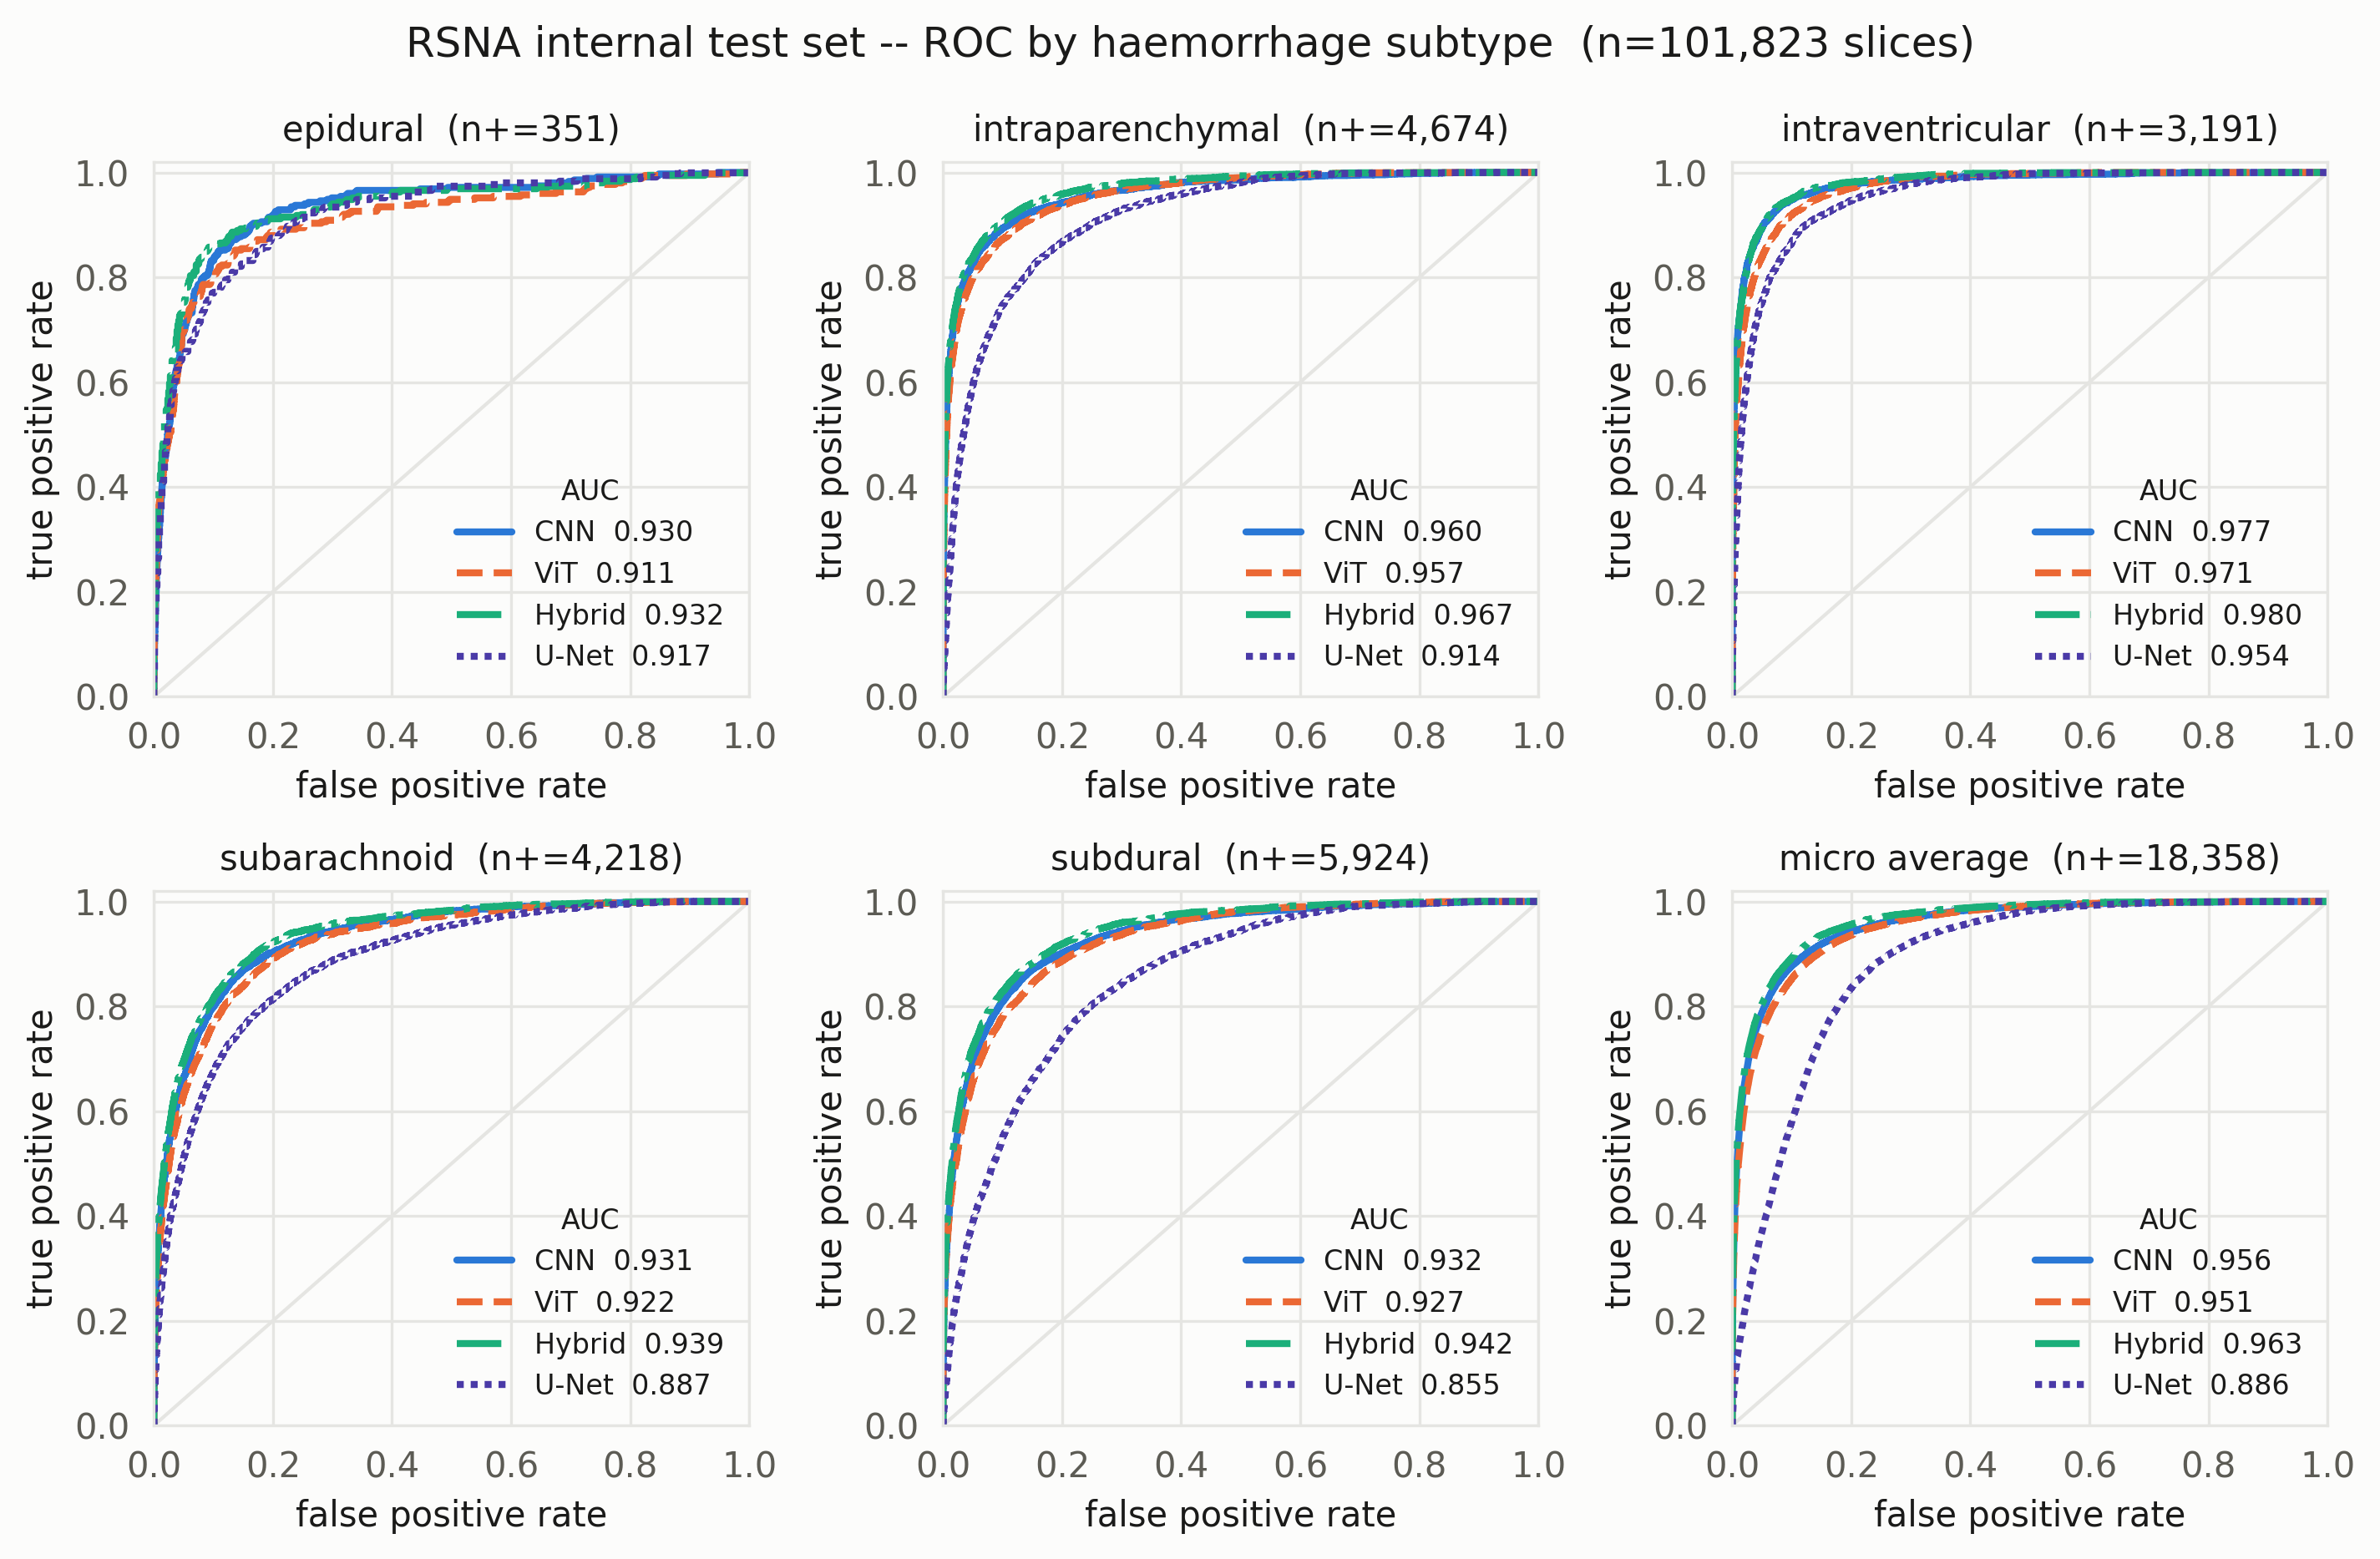

all_auc_rsna_dots_20260823_083800.png


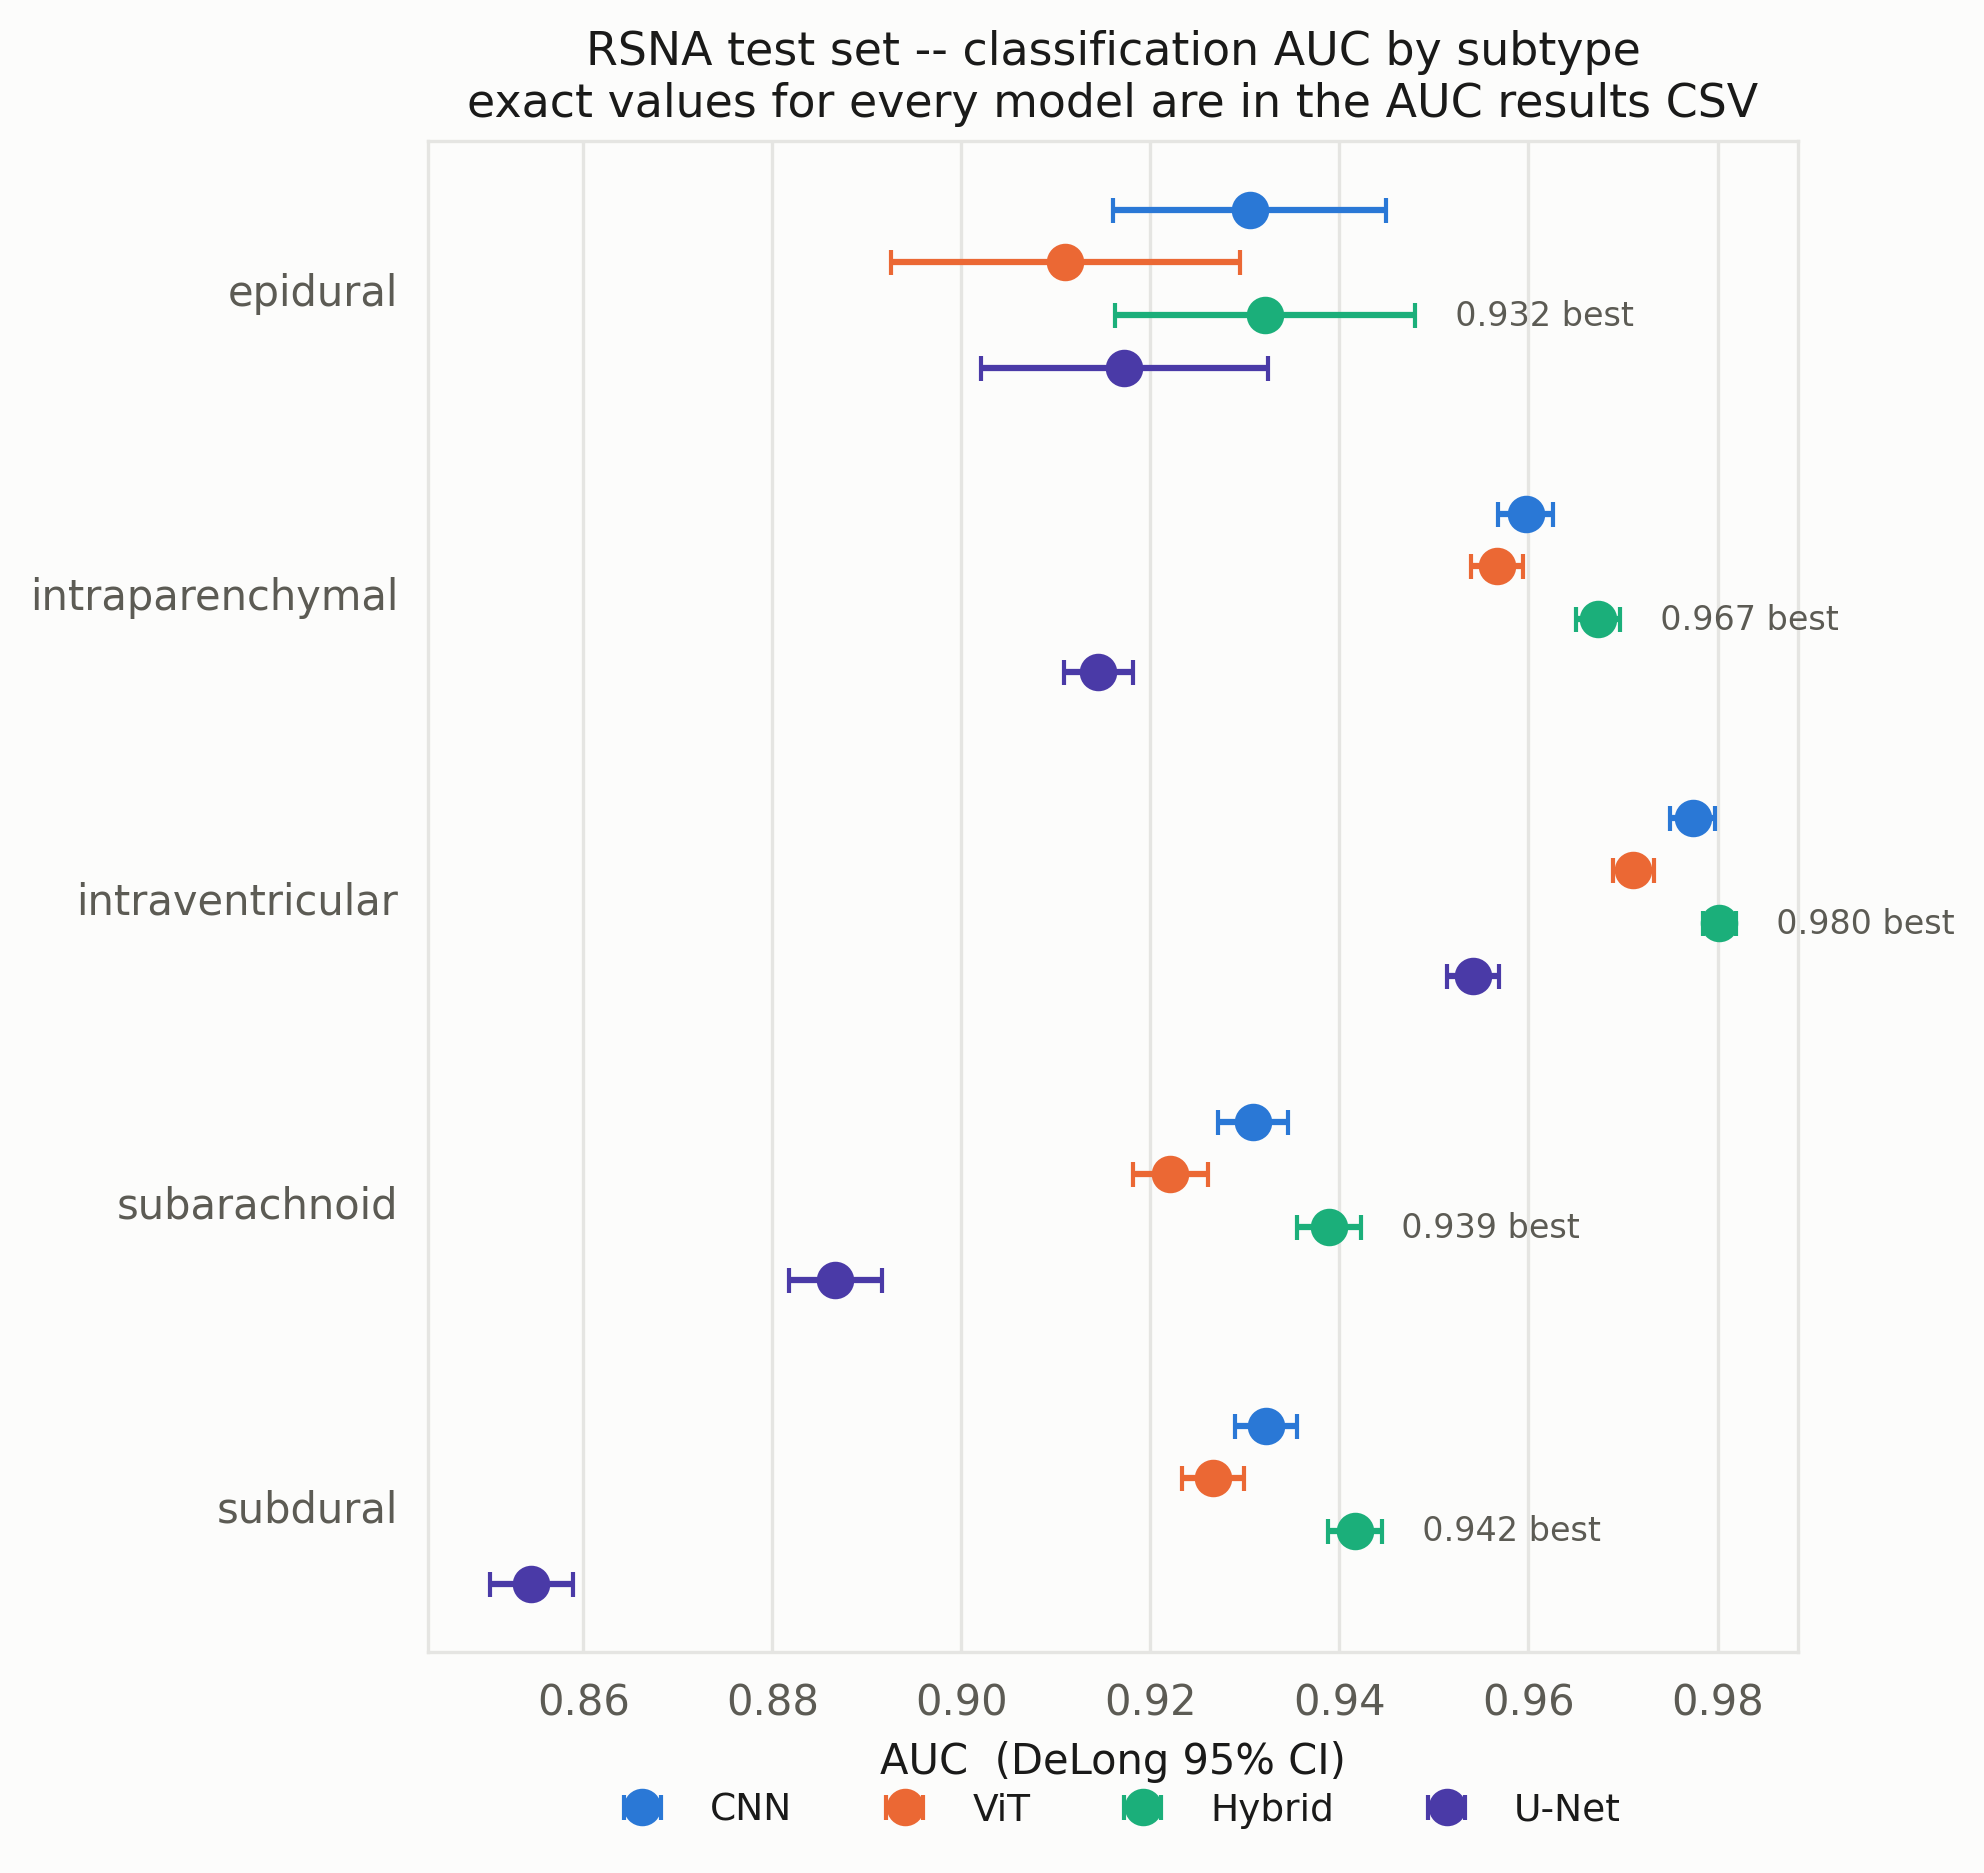

all_auc_forest_20260823_083800.png


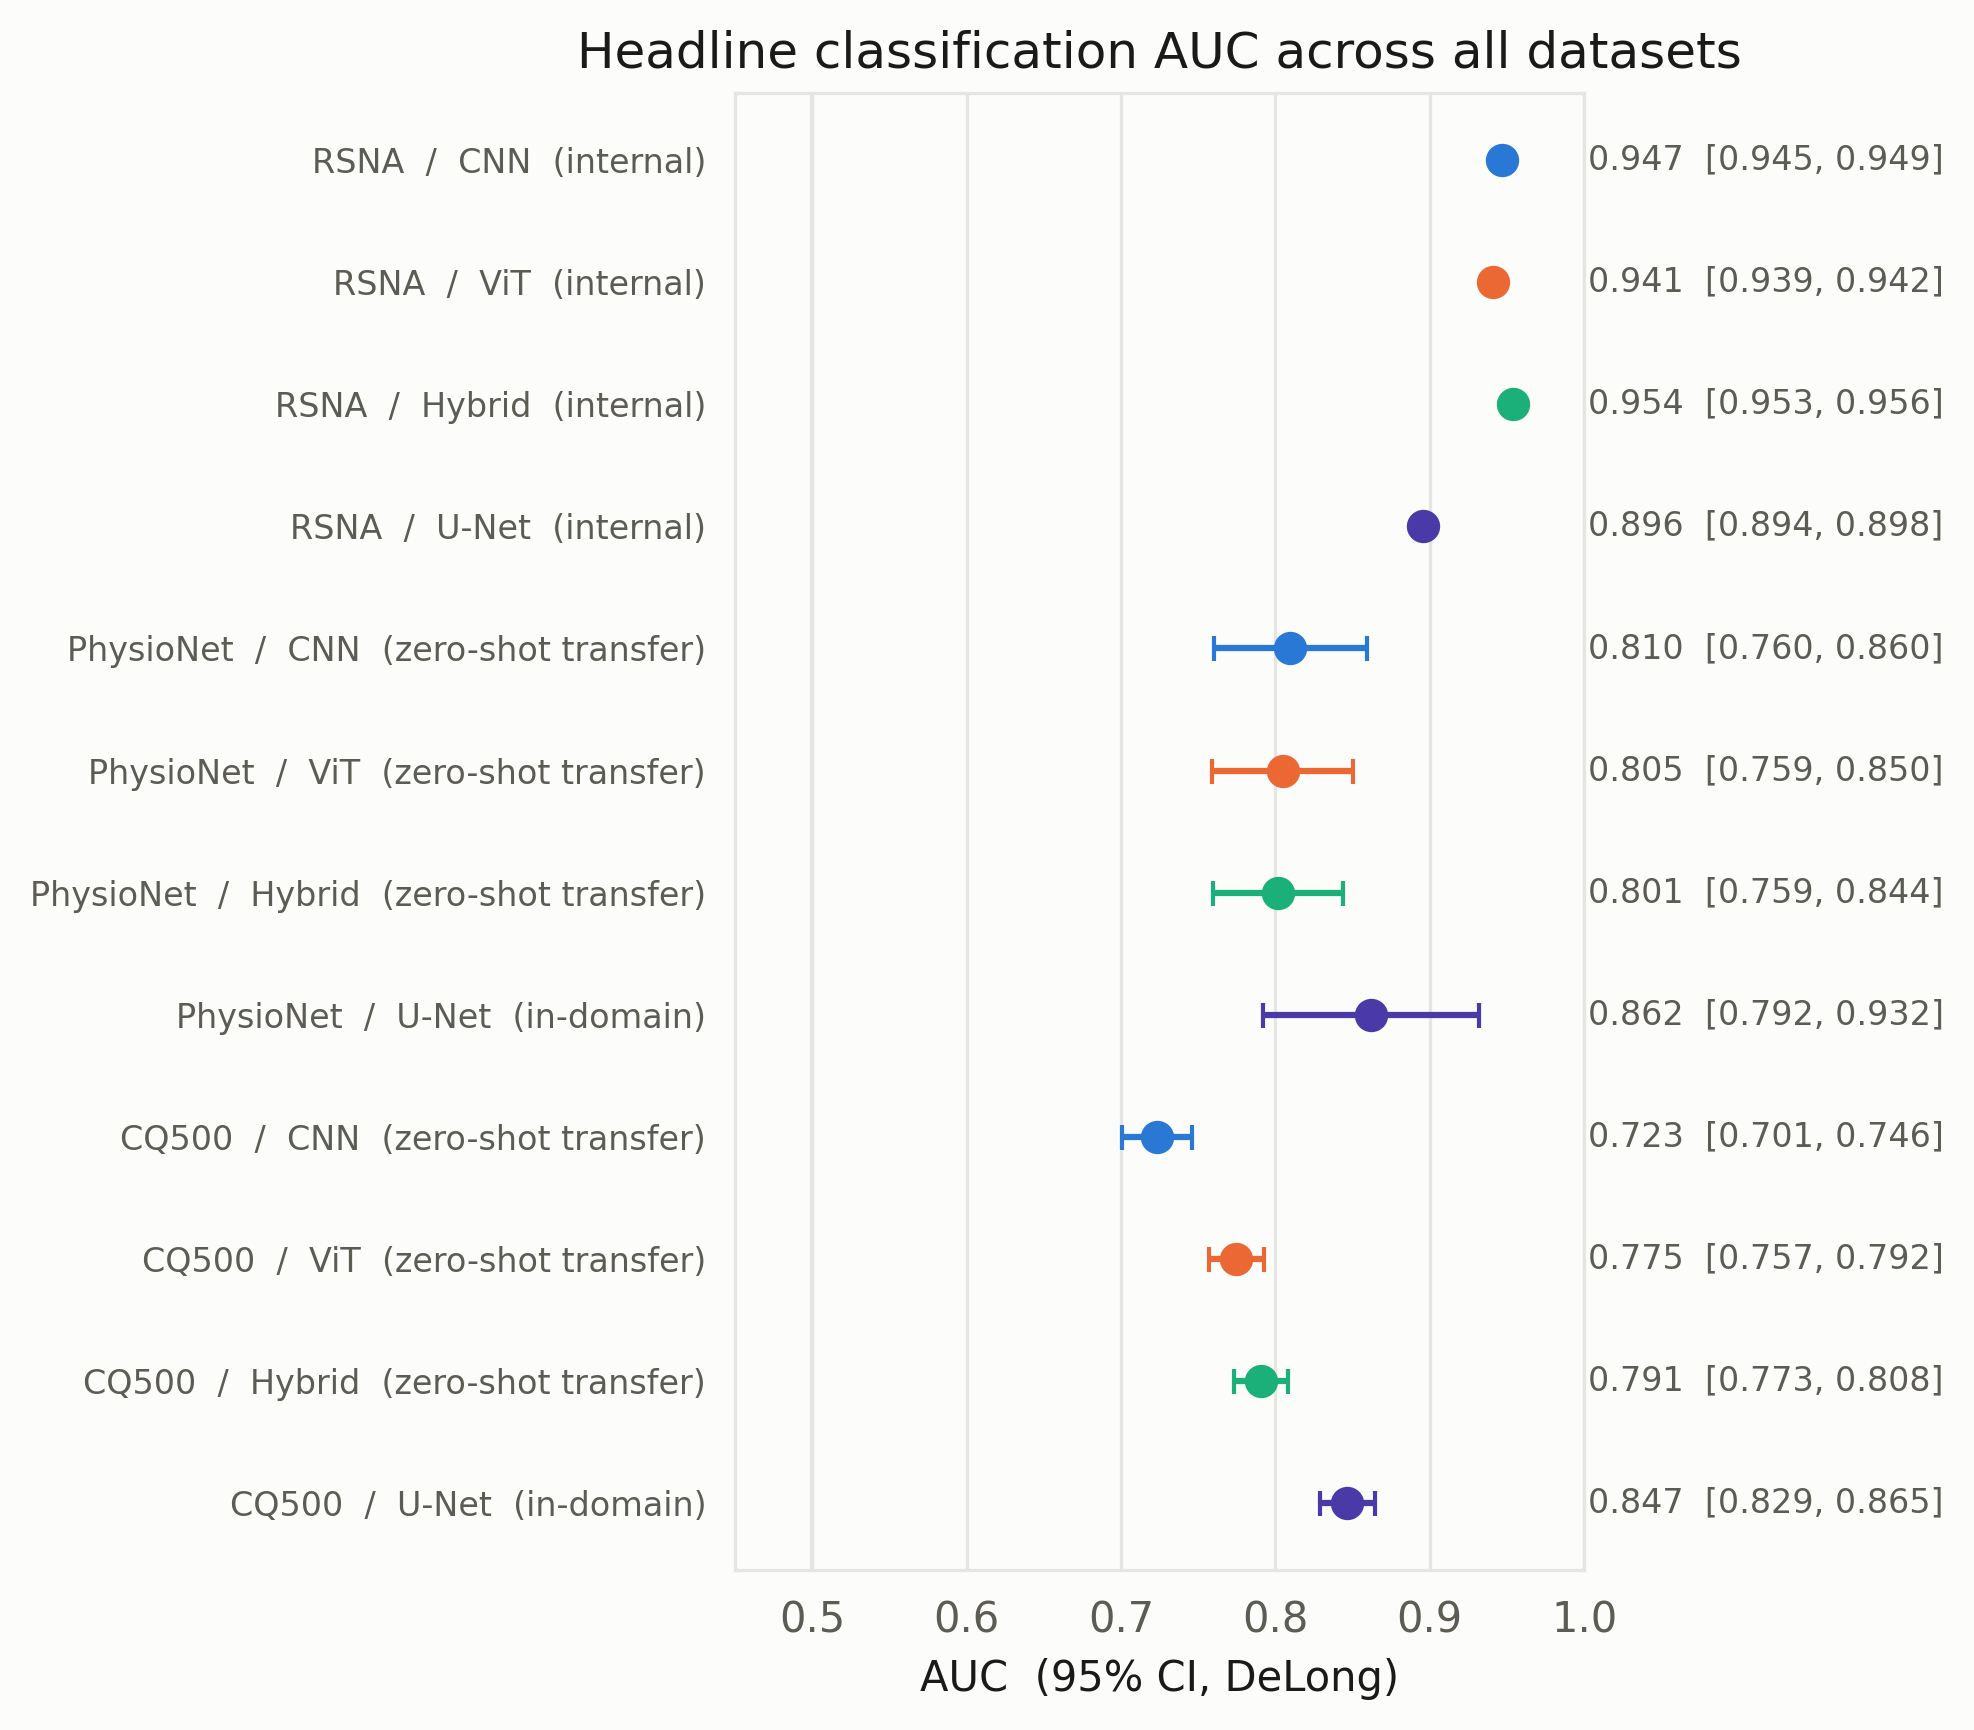

all_roc_external_20260823_083800.png


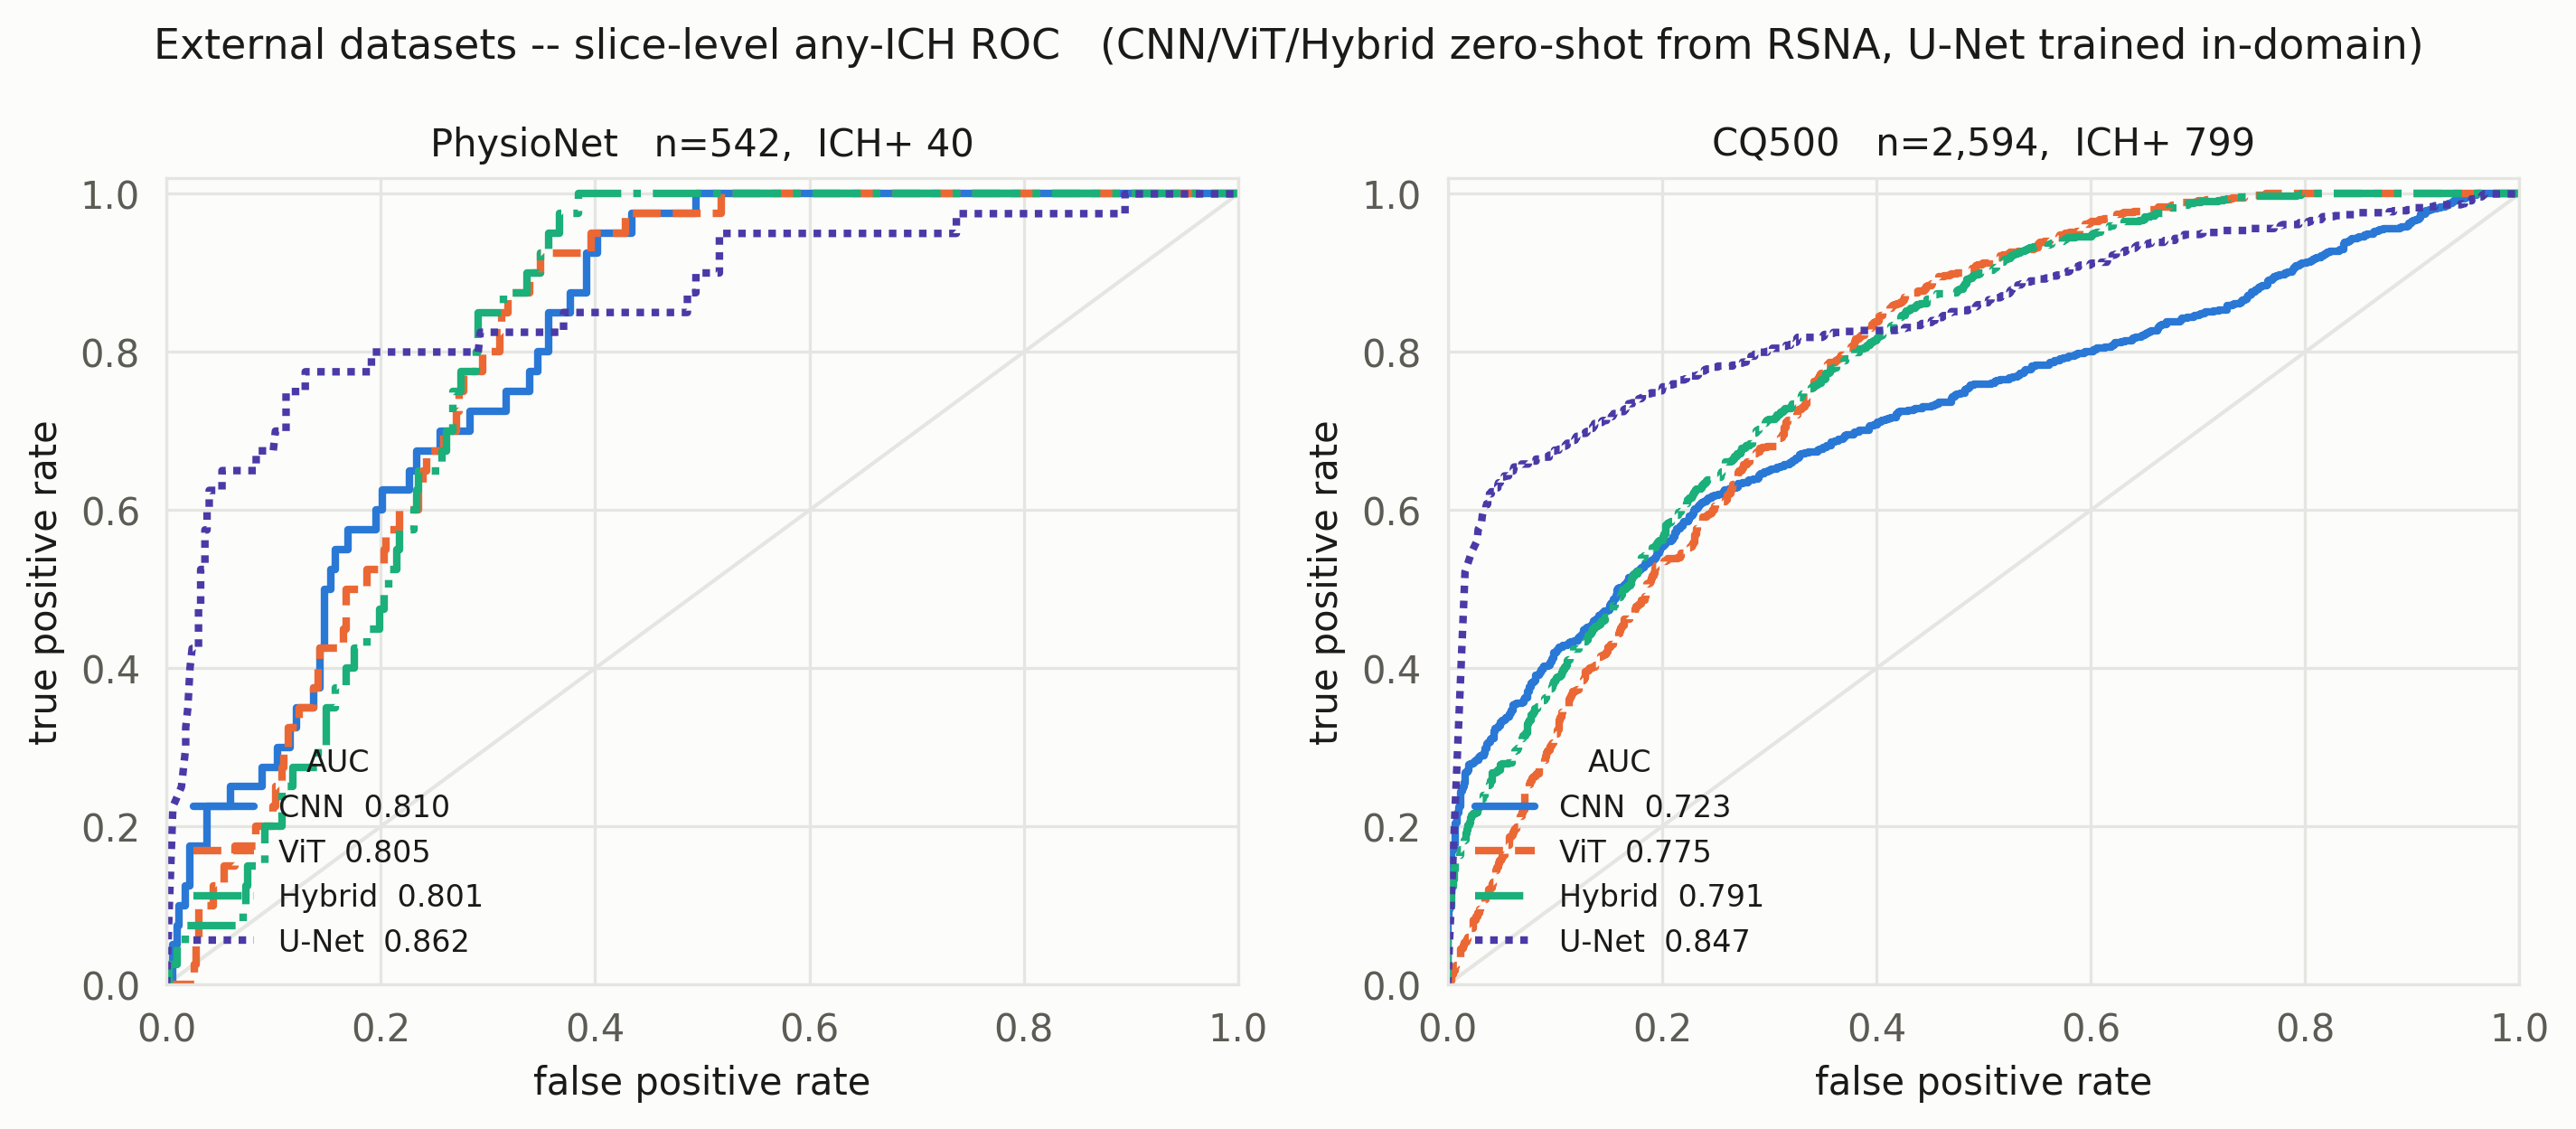

all_pr_external_20260823_083800.png


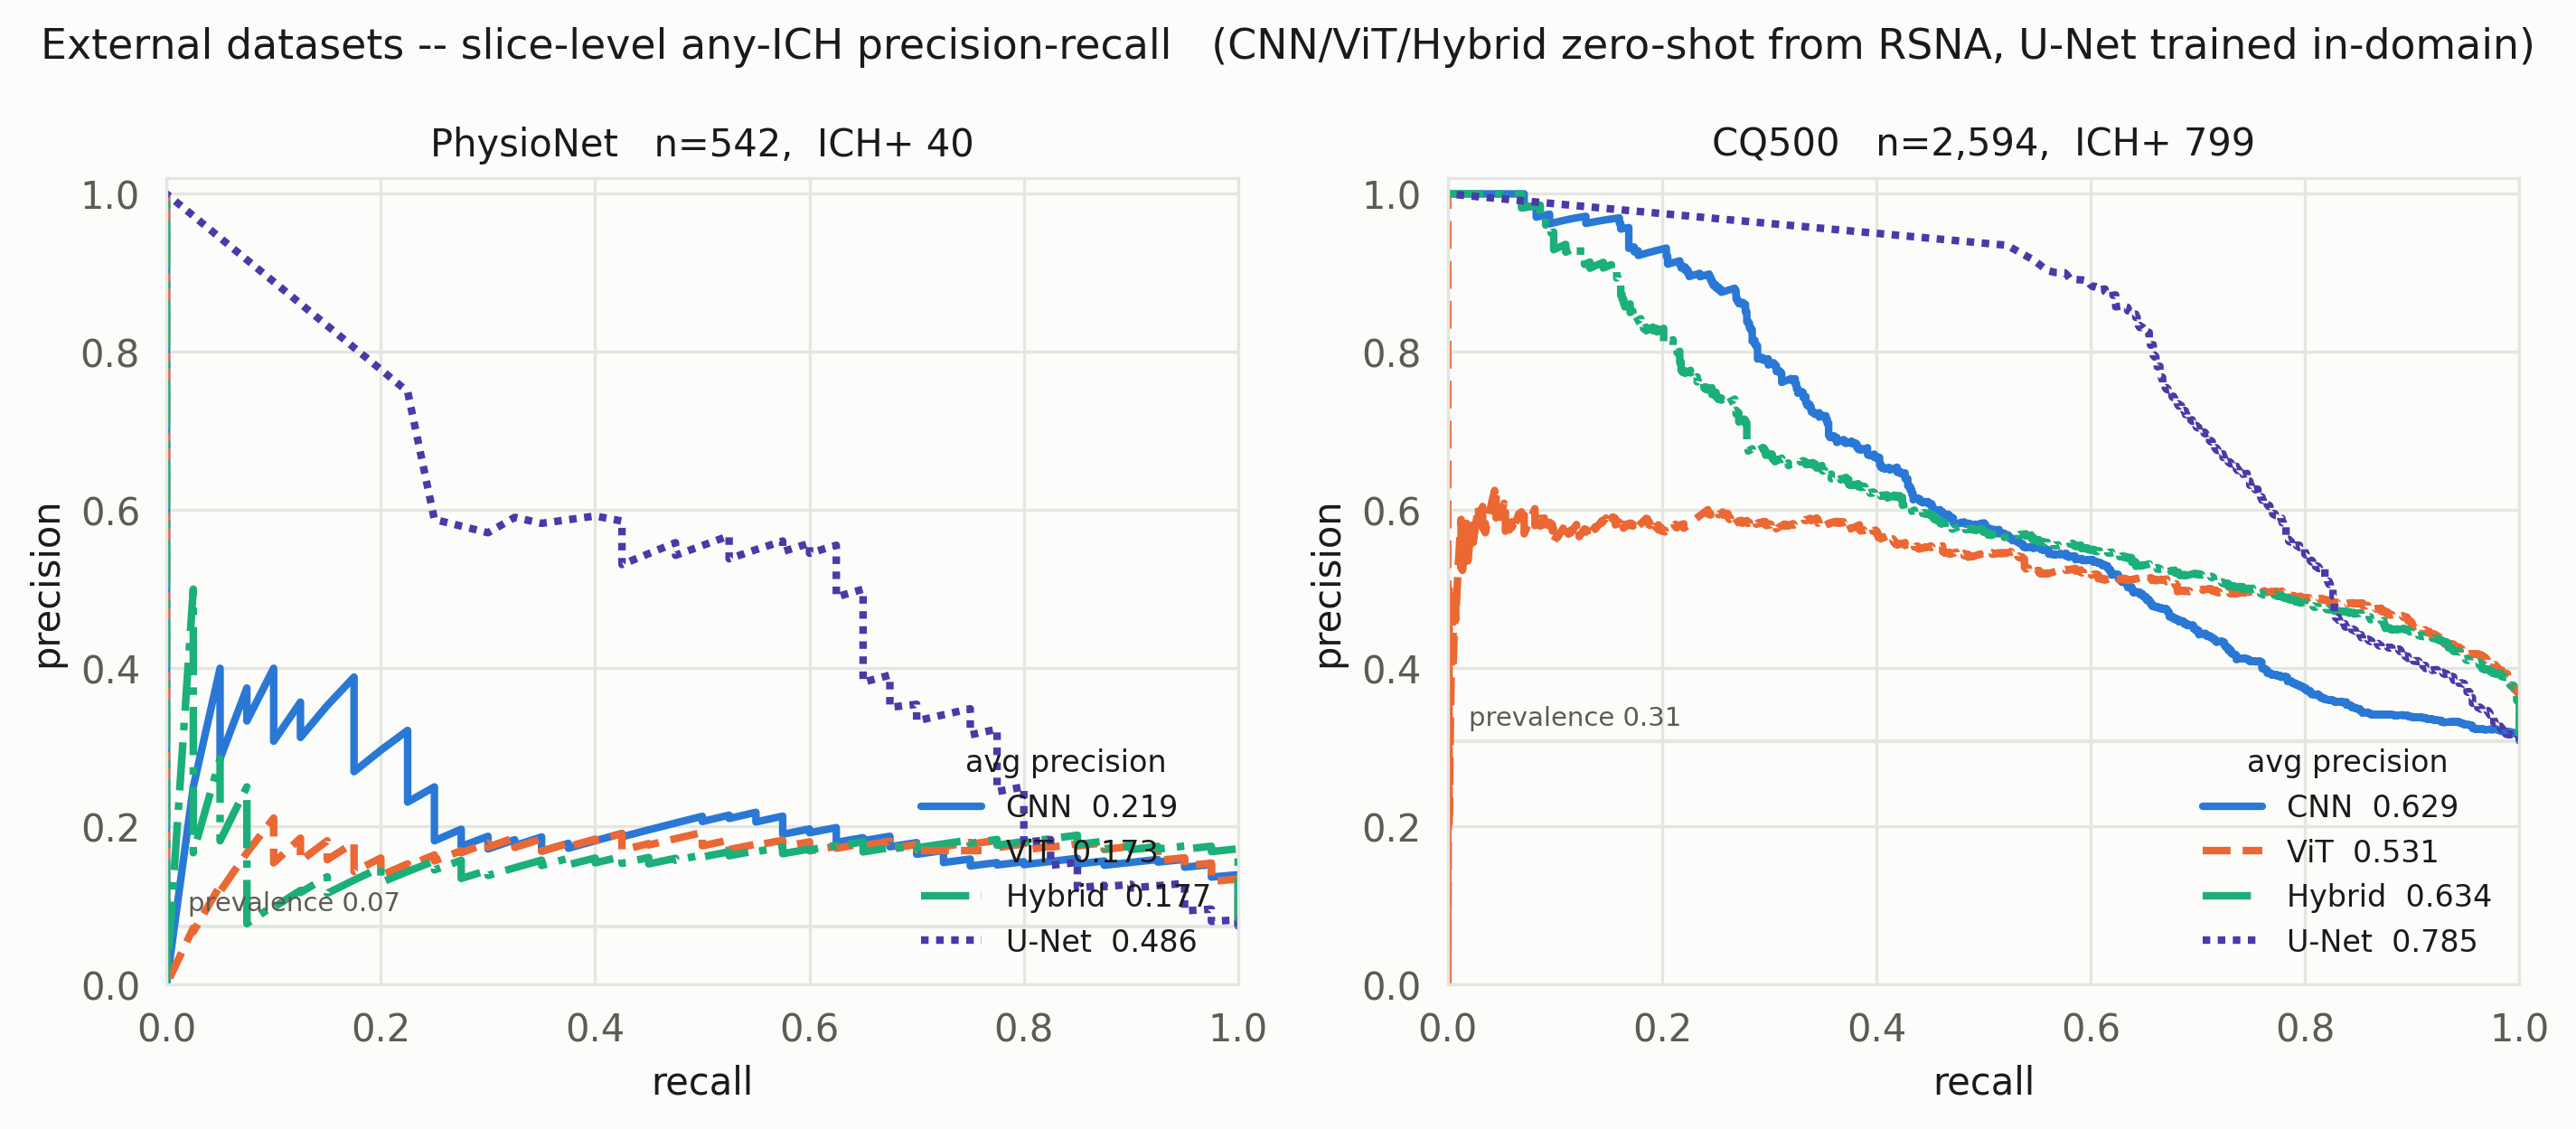

all_dist_dice_20260823_083800.png


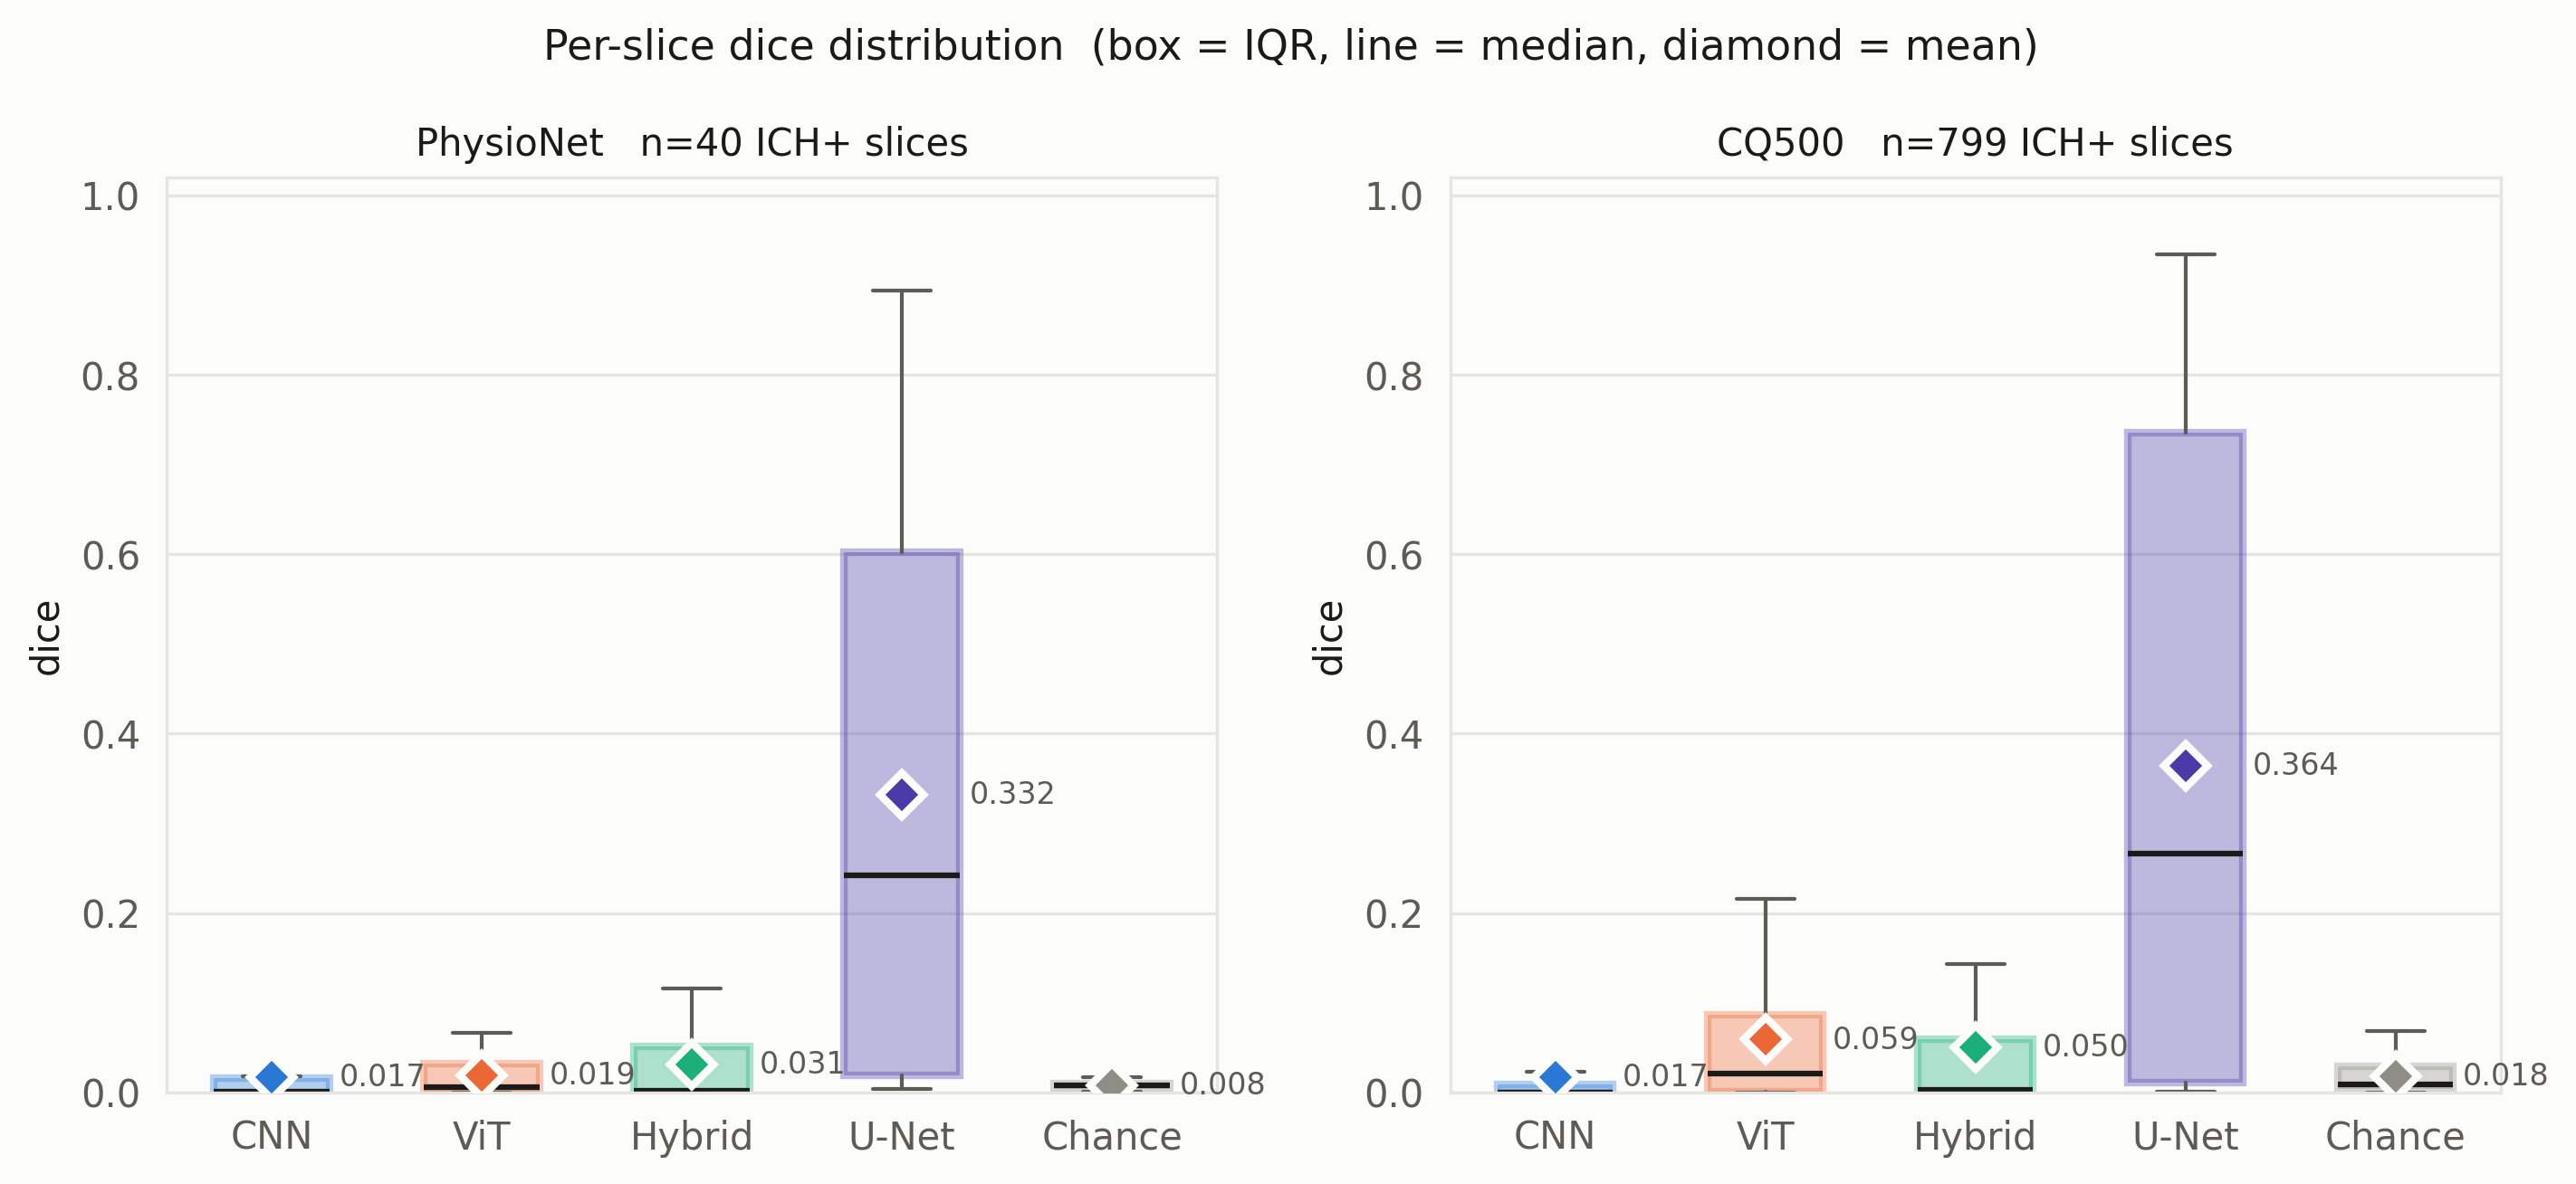

all_dist_iou_20260823_083800.png


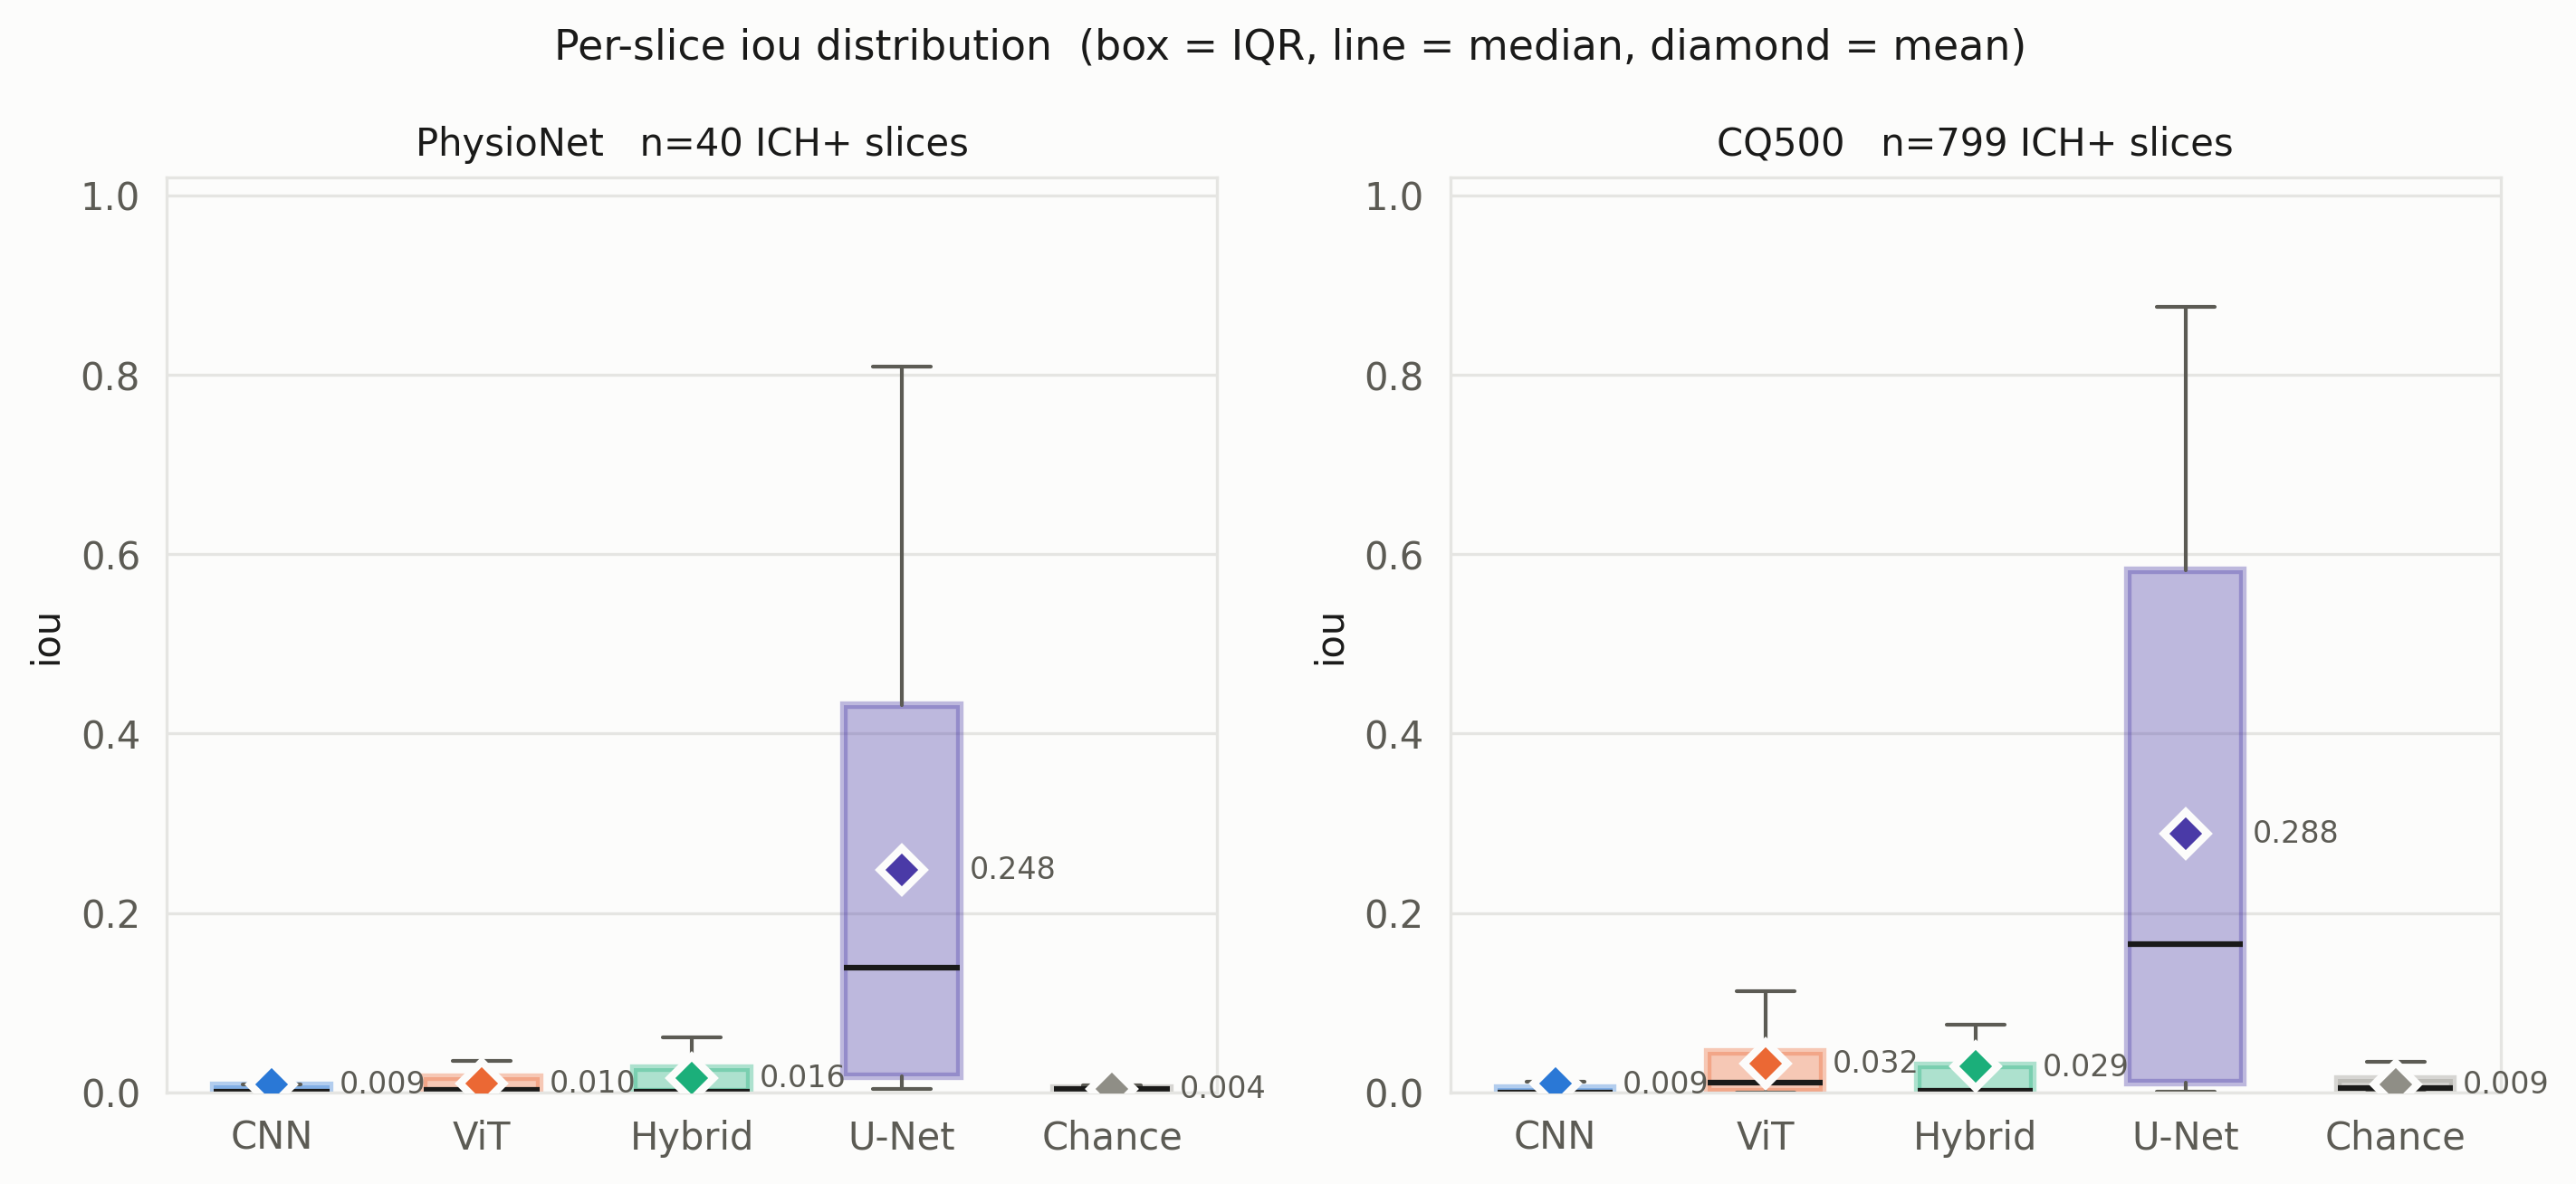

all_pvalues_dice_patient_20260823_083800.png


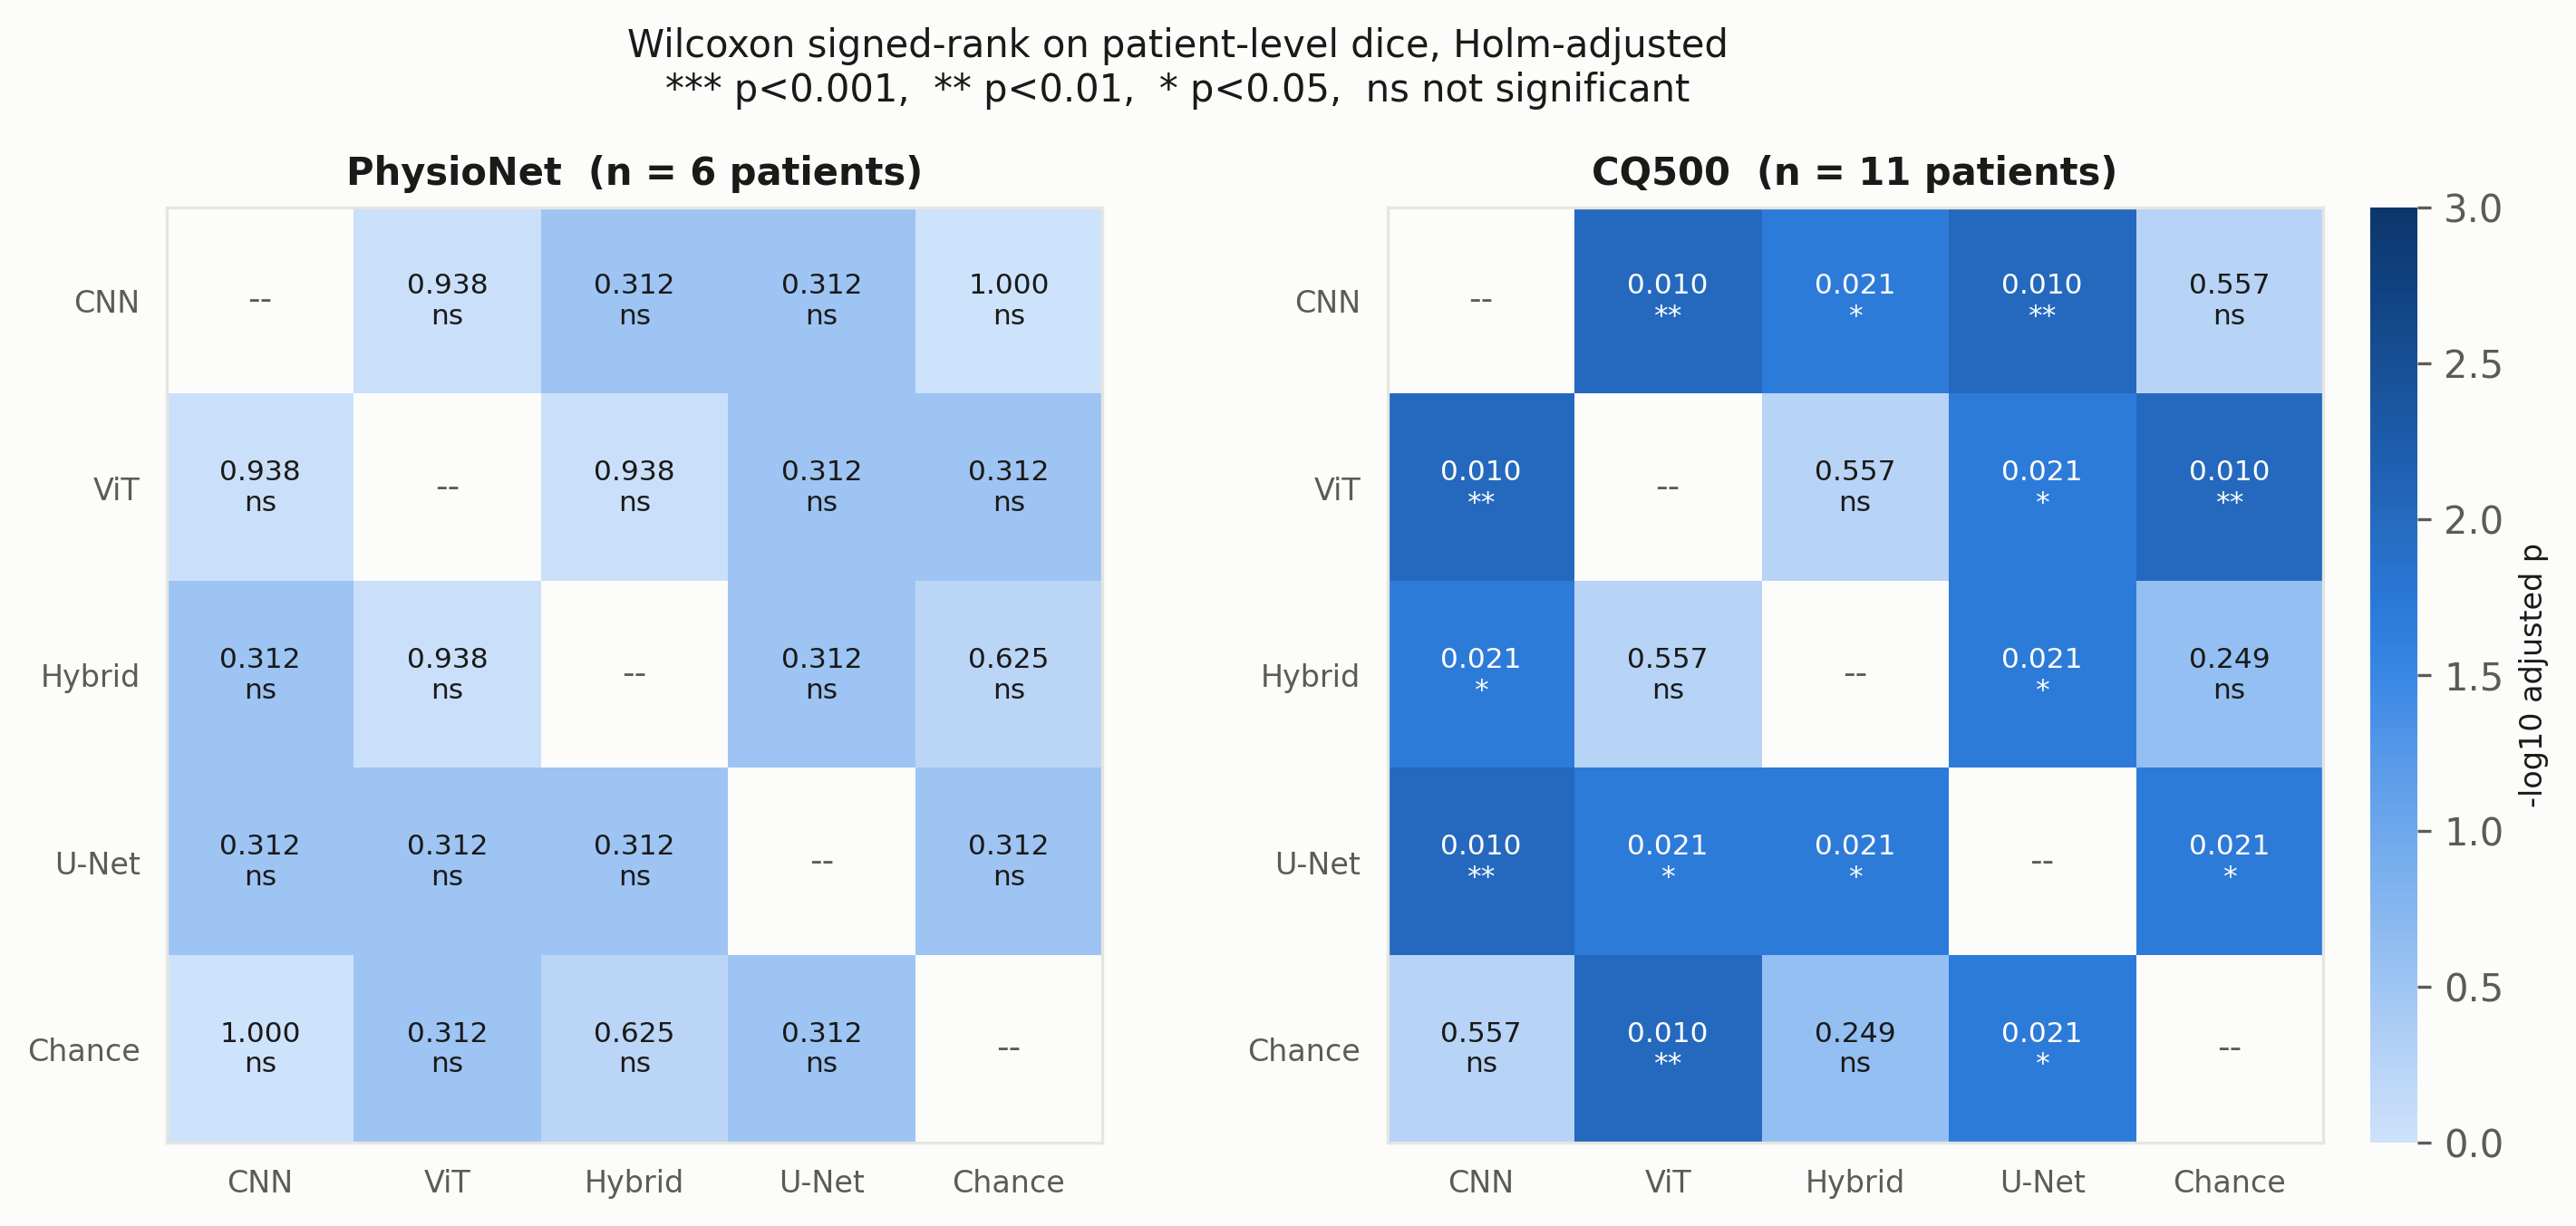

In [81]:
su.apply_style()

figs = [
    su.fig_rsna_roc(bundle,             RESULT_DIR / f'all_roc_rsna_{TS}.png'),
    su.fig_rsna_auc_dots(tables['auc'], RESULT_DIR / f'all_auc_rsna_dots_{TS}.png'),
    su.fig_auc_forest(tables['auc'],    RESULT_DIR / f'all_auc_forest_{TS}.png'),
    su.fig_external_curves(bundle,      RESULT_DIR / f'all_roc_external_{TS}.png', kind='roc'),
    su.fig_external_curves(bundle,      RESULT_DIR / f'all_pr_external_{TS}.png',  kind='pr'),
    su.fig_dice_distribution(bundle,    RESULT_DIR / f'all_dist_dice_{TS}.png', metric='dice'),
    su.fig_dice_distribution(bundle,    RESULT_DIR / f'all_dist_iou_{TS}.png',  metric='iou'),
    su.fig_pvalue_heatmap(tables['wilcoxon'],
                          RESULT_DIR / f'all_pvalues_dice_patient_{TS}.png',
                          metric='dice', unit='patient'),
]

for p in [f for f in figs if f]:
    print(p.name)
    display(Image(filename=str(p)))

### Statistical figures

The `su.fig_*` helpers write to `result/` and close the figure, so each is displayed from file.

The Dice and IoU distribution plots are worth reading against the choice of test made earlier. They show the spike at zero and the long right tail that ruled out repeated-measures ANOVA, making the justification for the rank-based tests visible in the data. The forest plot places every AUC beside its interval on one axis, which makes the internal-to-external drop and the width of the external intervals directly comparable. The p-value heatmap summarises the Wilcoxon table, where the block of non-significant comparisons among the CAM methods is the negative result in a single view.

In [82]:
#write every table and the report to result/
assert set(tables) == {'auc', 'delong', 'seg_desc',
                       'wilcoxon', 'mcnemar', 'chance'}, sorted(tables)

csv_map = {
    'auc':           f'all_auc_results_{TS}.csv',
    'delong':        f'all_stats_delong_{TS}.csv',
    'seg_desc':      f'all_seg_descriptive_{TS}.csv',
    'wilcoxon':      f'all_stats_wilcoxon_{TS}.csv',
    'mcnemar':       f'all_stats_mcnemar_{TS}.csv',
    'chance':        f'all_stats_chance_{TS}.csv',
}

report_path = RESULT_DIR / f'all_stats_report_{TS}.txt'

for key, fname in csv_map.items():
    df = tables[key]
    if not df.empty:
        df.to_csv(RESULT_DIR / fname, index=False)
        print(f'saved {fname}')

su.write_report(report_path, bundle, tables)
print(f'saved {report_path.name}')

saved all_auc_results_20260823_083800.csv
saved all_stats_delong_20260823_083800.csv
saved all_seg_descriptive_20260823_083800.csv
saved all_stats_wilcoxon_20260823_083800.csv
saved all_stats_mcnemar_20260823_083800.csv
saved all_stats_chance_20260823_083800.csv
saved all_stats_report_20260823_083800.txt


The timestamp is the bundle's own, so this run overwrites its own outputs in place and `result/` gains no new set on every execution.

## Results

The tables below are drawn from the analysis computed above, so every figure quoted here is one this notebook produced. They are arranged in the order of the research questions: classification first, then localisation against the pixel masks, then the tests that determine which of the gaps between them are real.

### Classification

RSNA is the internal test set. PhysioNet and Seg-CQ500 are external and are scored zero-shot as slice-level "any ICH", taken as the maximum over the five subtype probabilities. The `validation` column records which regime each row belongs to, and the U-Net rows on the external datasets are marked in-domain because those segmenters were trained on the dataset they are scored on.

In [83]:
auc_df   = tables['auc']
headline = auc_df[auc_df['target'].isin(['any ICH', 'weighted average'])]

print(headline[['dataset', 'target', 'model', 'n_pos', 'auc',
                'ci_lo', 'ci_hi', 'ap', 'validation']].round(4).to_string(index=False))

  dataset           target  model  n_pos    auc  ci_lo  ci_hi     ap         validation
     RSNA weighted average    CNN  18358 0.9467 0.9453 0.9486 0.6343           internal
     RSNA weighted average    ViT  18358 0.9407 0.9391 0.9424 0.5999           internal
     RSNA weighted average Hybrid  18358 0.9541 0.9527 0.9555 0.6612           internal
     RSNA weighted average  U-Net  18358 0.8957 0.8935 0.8979 0.3546           internal
PhysioNet          any ICH    CNN     40 0.8098 0.7600 0.8596 0.2193 zero-shot transfer
PhysioNet          any ICH    ViT     40 0.8047 0.7591 0.8503 0.1725 zero-shot transfer
PhysioNet          any ICH Hybrid     40 0.8015 0.7593 0.8436 0.1771 zero-shot transfer
PhysioNet          any ICH  U-Net     40 0.8618 0.7918 0.9318 0.4858          in-domain
    CQ500          any ICH    CNN    799 0.7234 0.7008 0.7460 0.6290 zero-shot transfer
    CQ500          any ICH    ViT    799 0.7746 0.7569 0.7923 0.5314 zero-shot transfer
    CQ500          any ICH Hybri

Per class on the RSNA internal test set:

In [84]:
per_class = auc_df[(auc_df['dataset'] == 'RSNA') &
                   (~auc_df['target'].isin(['weighted average', 'macro average', 'any ICH']))]

print(per_class.pivot(index='target', columns='model', values='auc').round(4).to_string())

model                CNN  Hybrid   U-Net     ViT
target                                          
epidural          0.9305  0.9321  0.9172  0.9110
intraparenchymal  0.9597  0.9673  0.9145  0.9567
intraventricular  0.9774  0.9802  0.9541  0.9711
subarachnoid      0.9308  0.9389  0.8867  0.9221
subdural          0.9323  0.9417  0.8545  0.9266


### Localisation

ICH-positive slices only, at a threshold of 0.5. Every row is read against the Chance row: Chance is a uniform random saliency map thresholded at the same cut-off, so it is what a map containing no spatial information scores on these same lesions. Its recall is close to 0.5 by construction and carries no information.

`n_patients` is the effective sample size for each row.

In [85]:
#from the descriptive table computed above, which also carries the patient-clustered intervals
sd  = tables['seg_desc']
loc = sd.pivot_table(index=['dataset', 'method'], columns='metric', values='mean')
loc = loc[['dice', 'iou', 'recall', 'precision', 'pg', 'ap']]
loc = loc.join(sd.groupby(['dataset', 'method'])[['n_slices', 'n_patients']].first())

idx = [(d, m) for d in su.order_datasets(sd['dataset'].unique())
              for m in su.order_methods(sd['method'].unique().tolist())]
print(loc.reindex(idx).round(4).to_string())

                    dice     iou  recall  precision      pg      ap  n_slices  n_patients
dataset   method                                                                         
PhysioNet CNN     0.0173  0.0092  0.0754     0.0102  0.0000  0.0143        40           6
          ViT     0.0187  0.0096  0.4040     0.0096  0.0500  0.0211        40           6
          Hybrid  0.0307  0.0164  0.1333     0.0182  0.0000  0.0202        40           6
          U-Net   0.3315  0.2482  0.2862     0.5420  0.7000  0.4477        40           6
          Chance  0.0080  0.0041  0.5053     0.0041  0.0000  0.0042        40           6
CQ500     CNN     0.0174  0.0094  0.0496     0.0114  0.0125  0.0268       799          11
          ViT     0.0589  0.0324  0.4932     0.0340  0.1014  0.0664       799          11
          Hybrid  0.0501  0.0286  0.1807     0.0339  0.0300  0.0506       799          11
          U-Net   0.3641  0.2882  0.3475     0.4686  0.5807  0.4525       799          11
          

### Statistical significance

DeLong for the classification AUCs, Wilcoxon at patient level for Dice, both Holm-corrected within their own family. The patient-level rows are quoted for the reason set out in the statistics section: slices within a scan are correlated, so the slice-level p-values are anti-conservative.

In [86]:
delong  = tables['delong']
sig_auc = delong[(delong['target'] == 'any ICH') & (delong['p_holm'] < 0.05)]

print('-- DeLong, any ICH, significant after Holm --')
if sig_auc.empty:
    print('  none: no classifier pair differs significantly on either external dataset')
else:
    print(sig_auc[['dataset', 'model_a', 'model_b', 'auc_a', 'auc_b',
                   'diff', 'p_holm']].round(4).to_string(index=False))

wilcox   = tables['wilcoxon']
sig_dice = wilcox[(wilcox['unit'] == 'patient') & (wilcox['metric'] == 'dice') &
                  (wilcox['p_holm'] < 0.05)]

print('\n-- Wilcoxon, dice, patient level, significant after Holm --')
print(sig_dice[['dataset', 'method_a', 'method_b', 'mean_a', 'mean_b',
                'effect_rank_biserial', 'p_holm']].round(4).to_string(index=False))

-- DeLong, any ICH, significant after Holm --
dataset model_a model_b  auc_a  auc_b    diff  p_holm
  CQ500     CNN     ViT 0.7234 0.7746 -0.0512     0.0
  CQ500     CNN  Hybrid 0.7234 0.7906 -0.0672     0.0
  CQ500     CNN   U-Net 0.7234 0.8467 -0.1233     0.0
  CQ500     ViT  Hybrid 0.7746 0.7906 -0.0160     0.0
  CQ500     ViT   U-Net 0.7746 0.8467 -0.0721     0.0
  CQ500  Hybrid   U-Net 0.7906 0.8467 -0.0561     0.0

-- Wilcoxon, dice, patient level, significant after Holm --
dataset method_a method_b  mean_a  mean_b  effect_rank_biserial  p_holm
  CQ500      CNN      ViT  0.0149  0.0484               -1.0000  0.0098
  CQ500      CNN   Hybrid  0.0149  0.0421               -0.9394  0.0205
  CQ500      CNN    U-Net  0.0149  0.3617               -1.0000  0.0098
  CQ500      ViT    U-Net  0.0484  0.3617               -0.9091  0.0205
  CQ500      ViT   Chance  0.0484  0.0139                1.0000  0.0098
  CQ500   Hybrid    U-Net  0.0421  0.3617               -0.9394  0.0205
  CQ500    

### Qualitative and per-dataset figures

These are the figures stage 7 produced from the images themselves. They require the CT slices and the masks, so they are read from `result/` and left as stage 7 wrote them. The statistics figures appear in the section above.

all_comparison_bar_physionet_20260823_083800.png


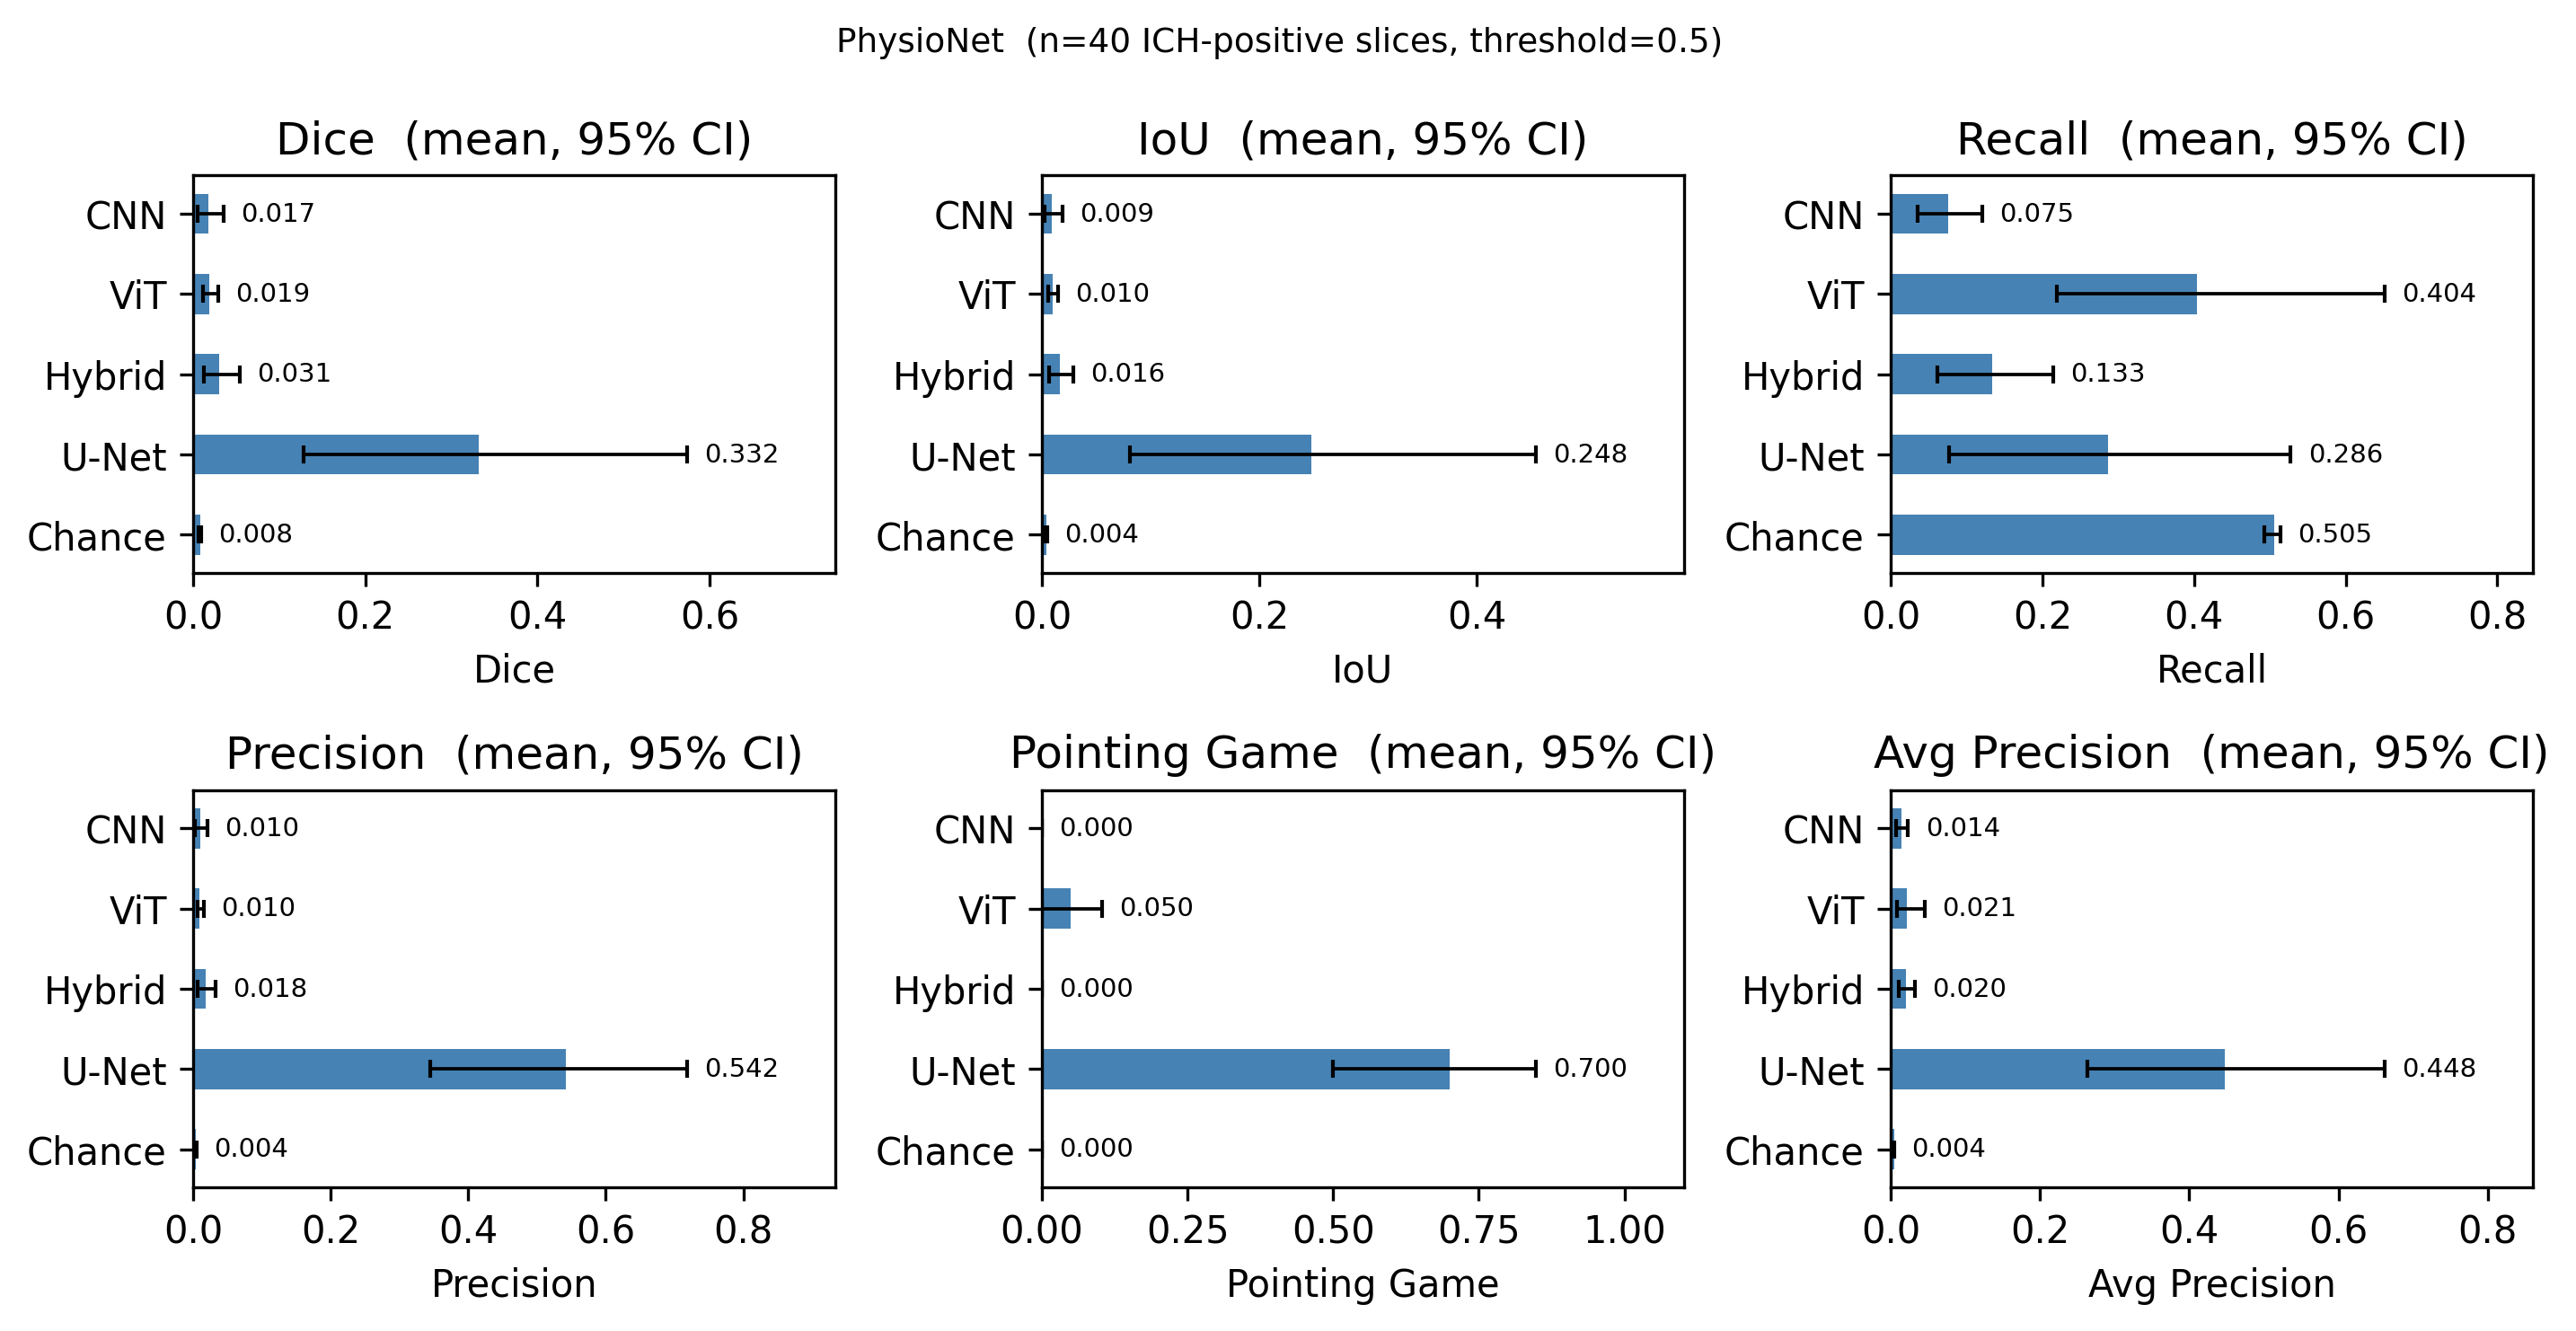

all_comparison_bar_cq500_20260823_083800.png


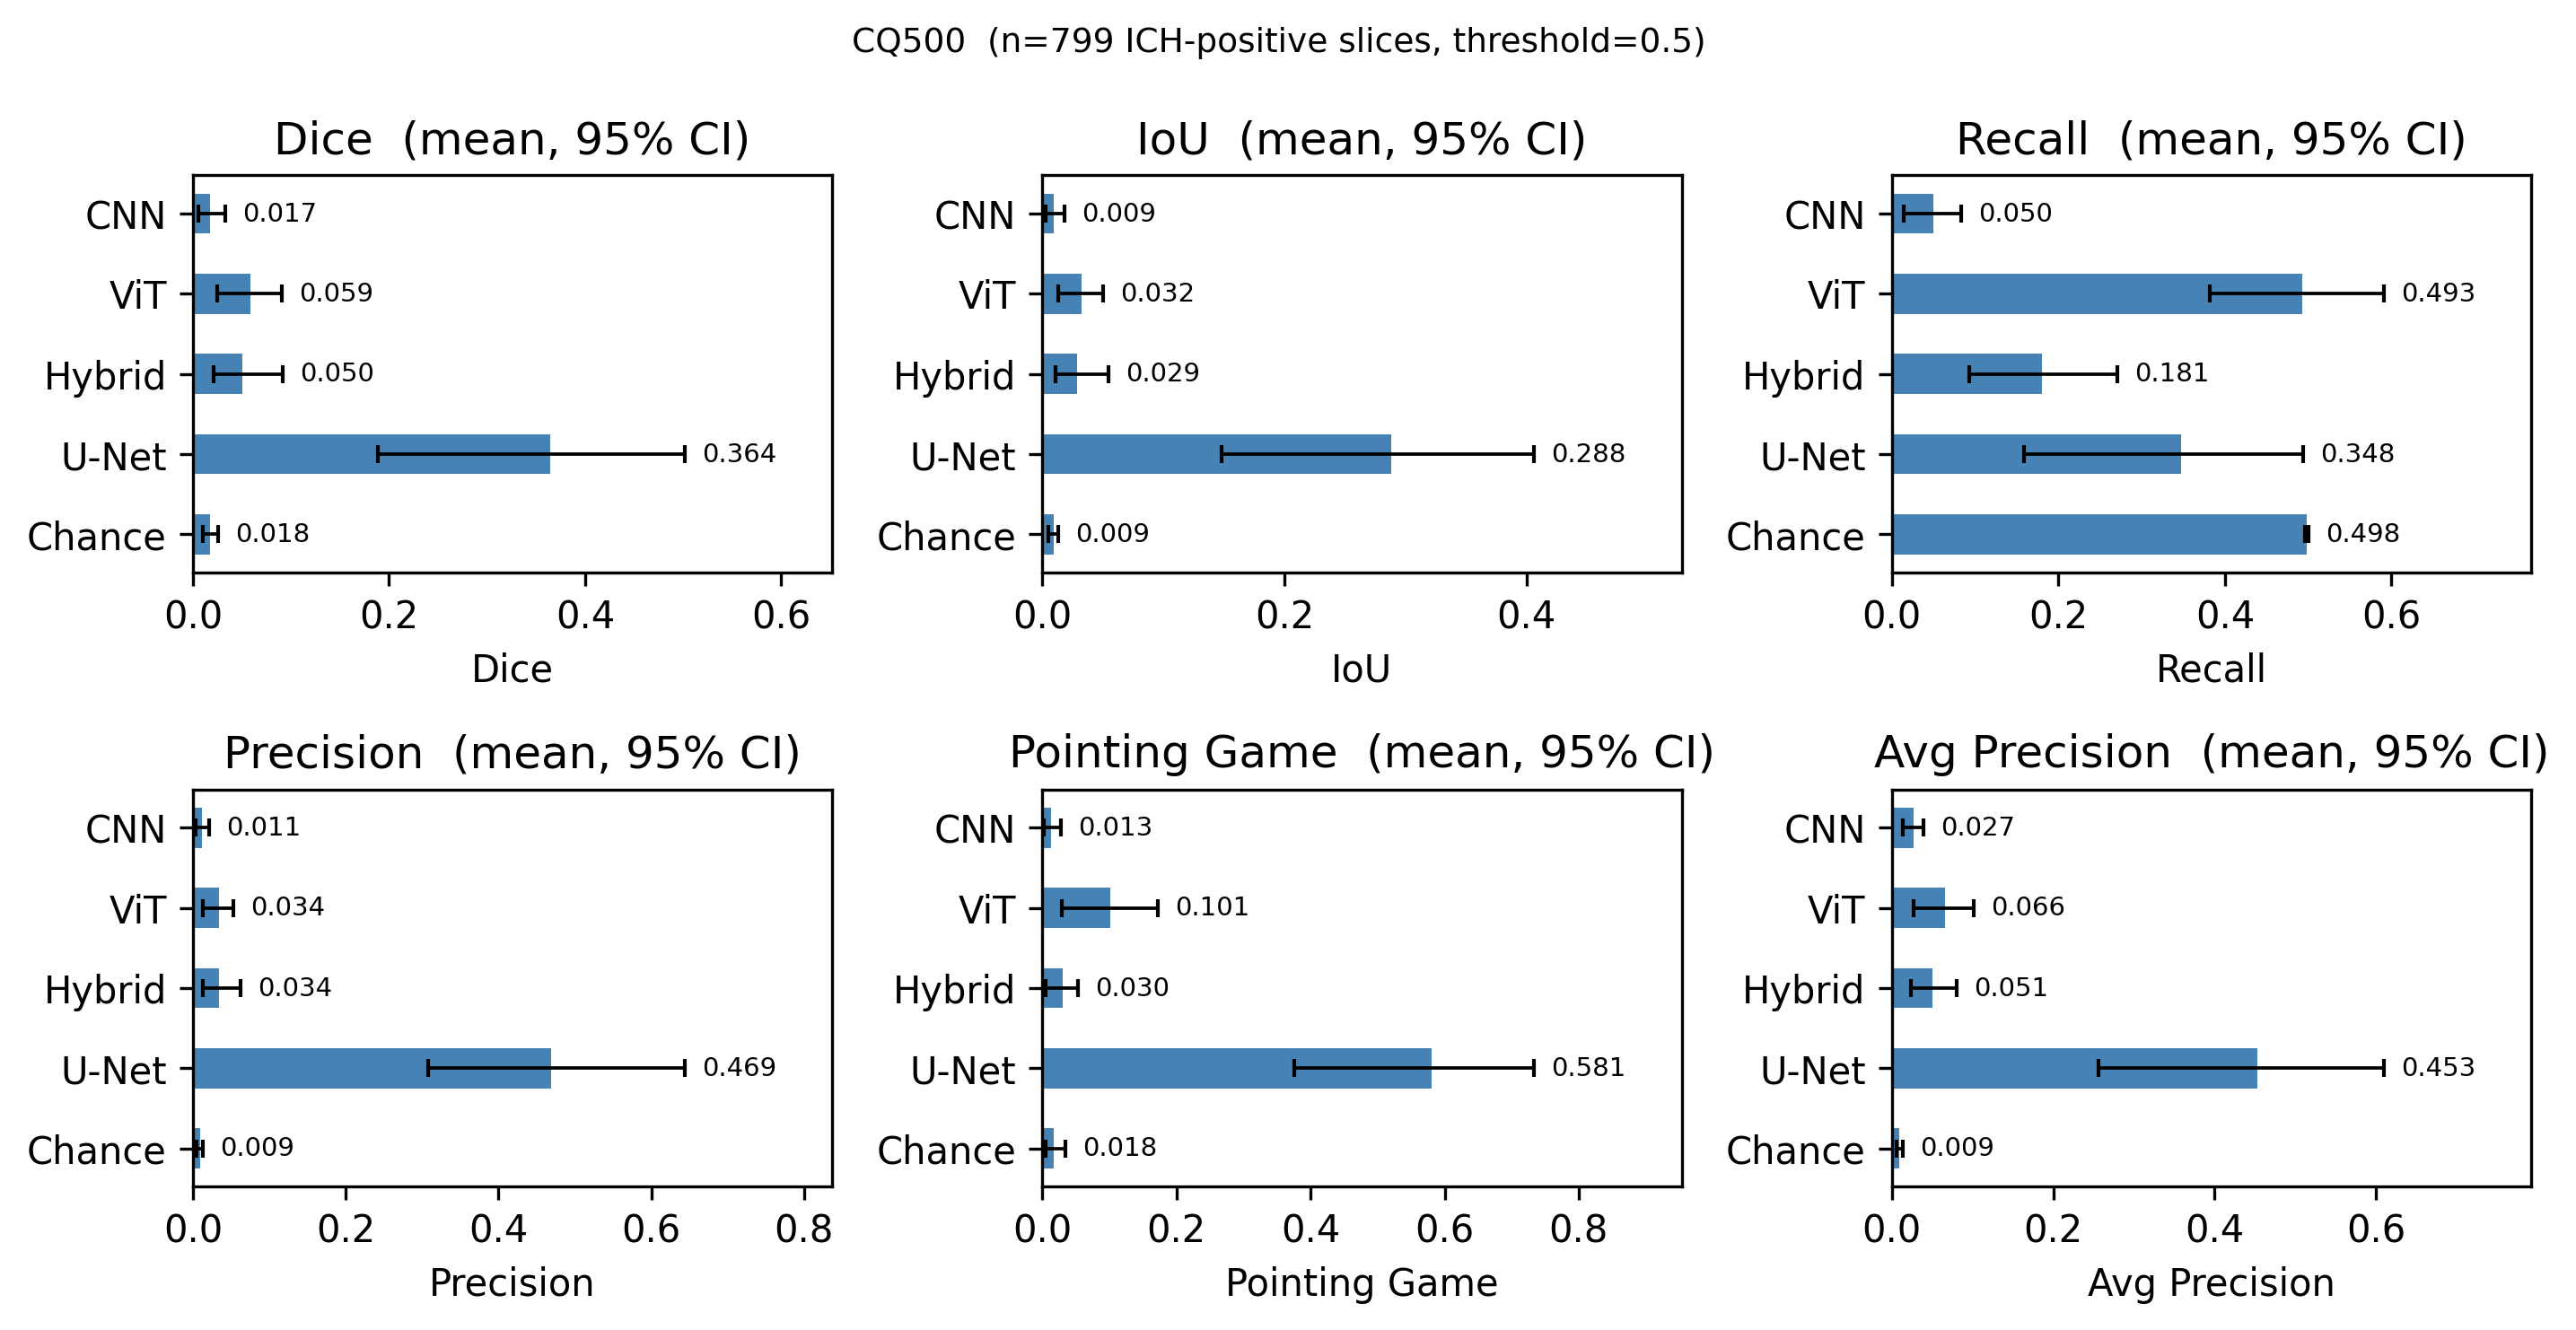

all_comparison_dice_combined_20260823_083800.png


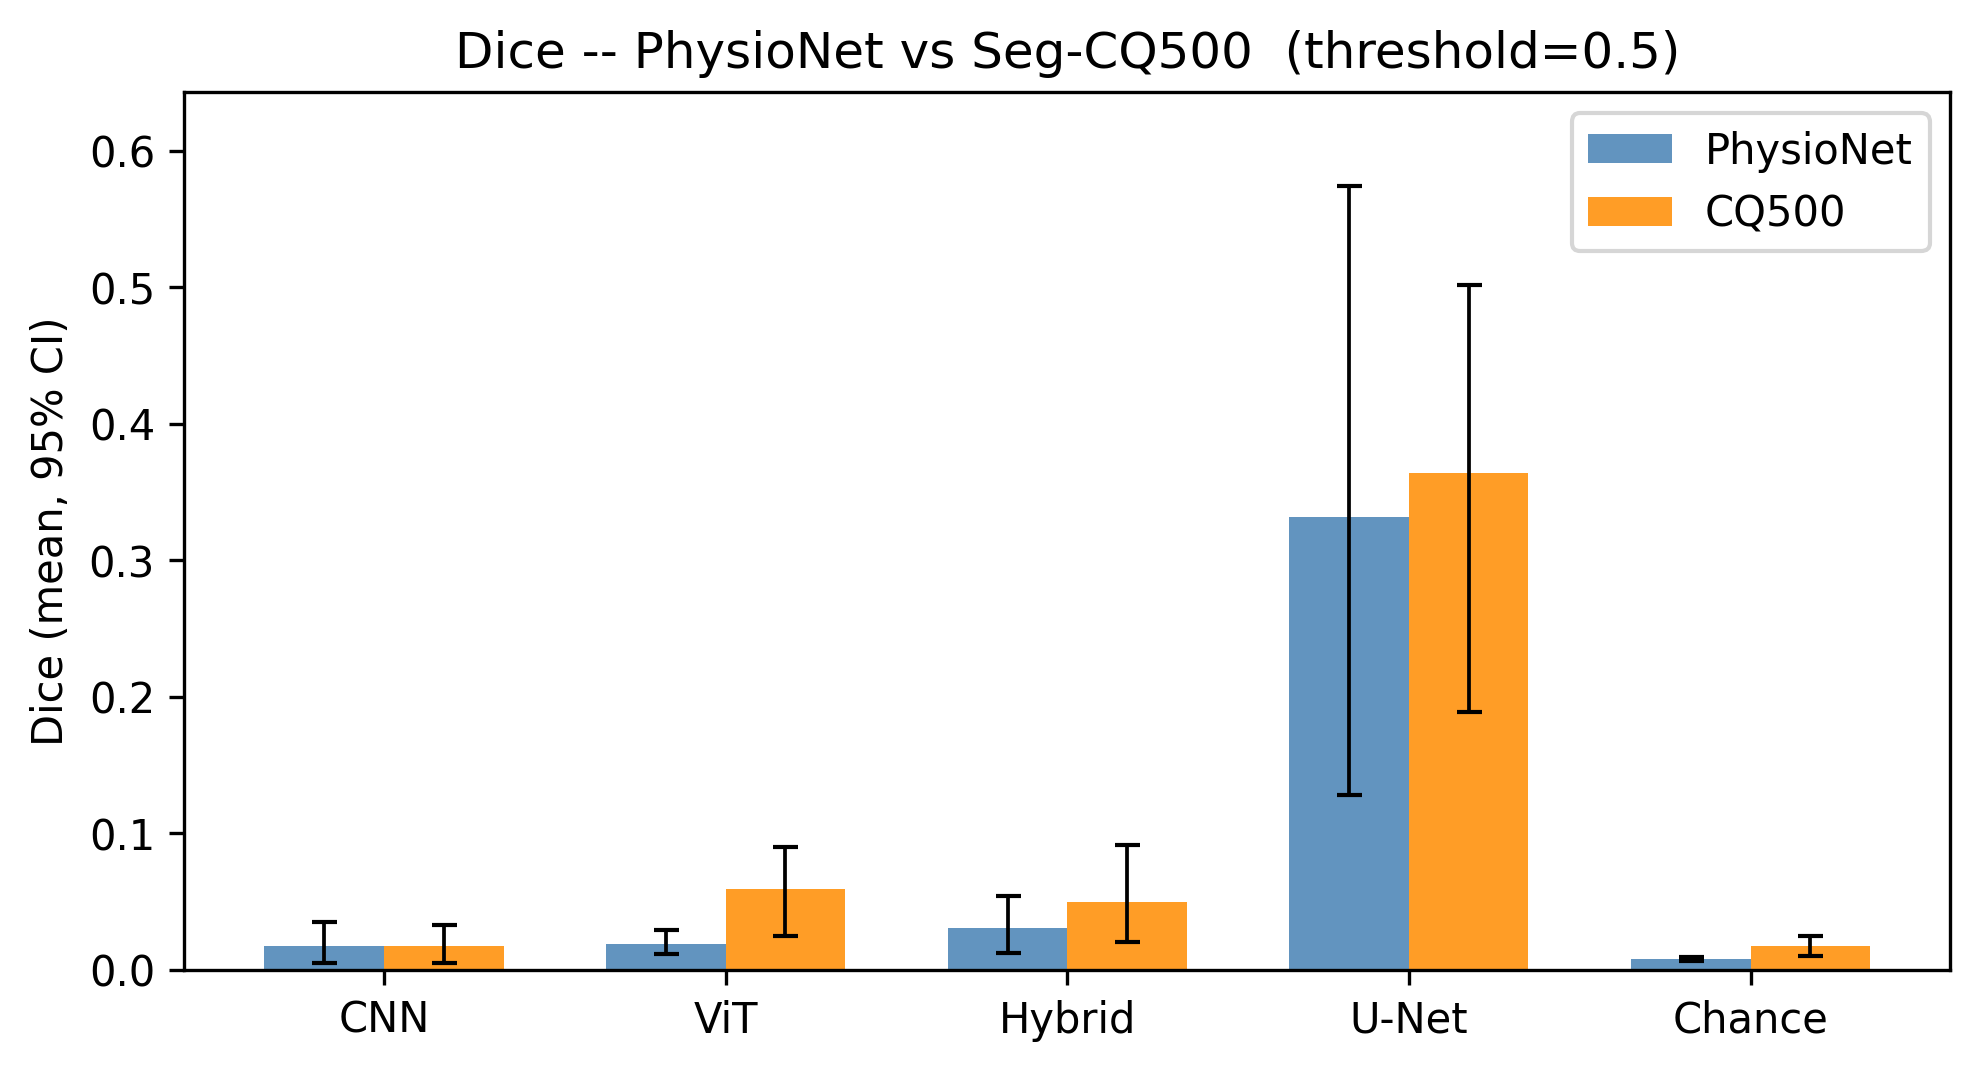

all_comparison_rsna_gradcam_20260823_083800.png


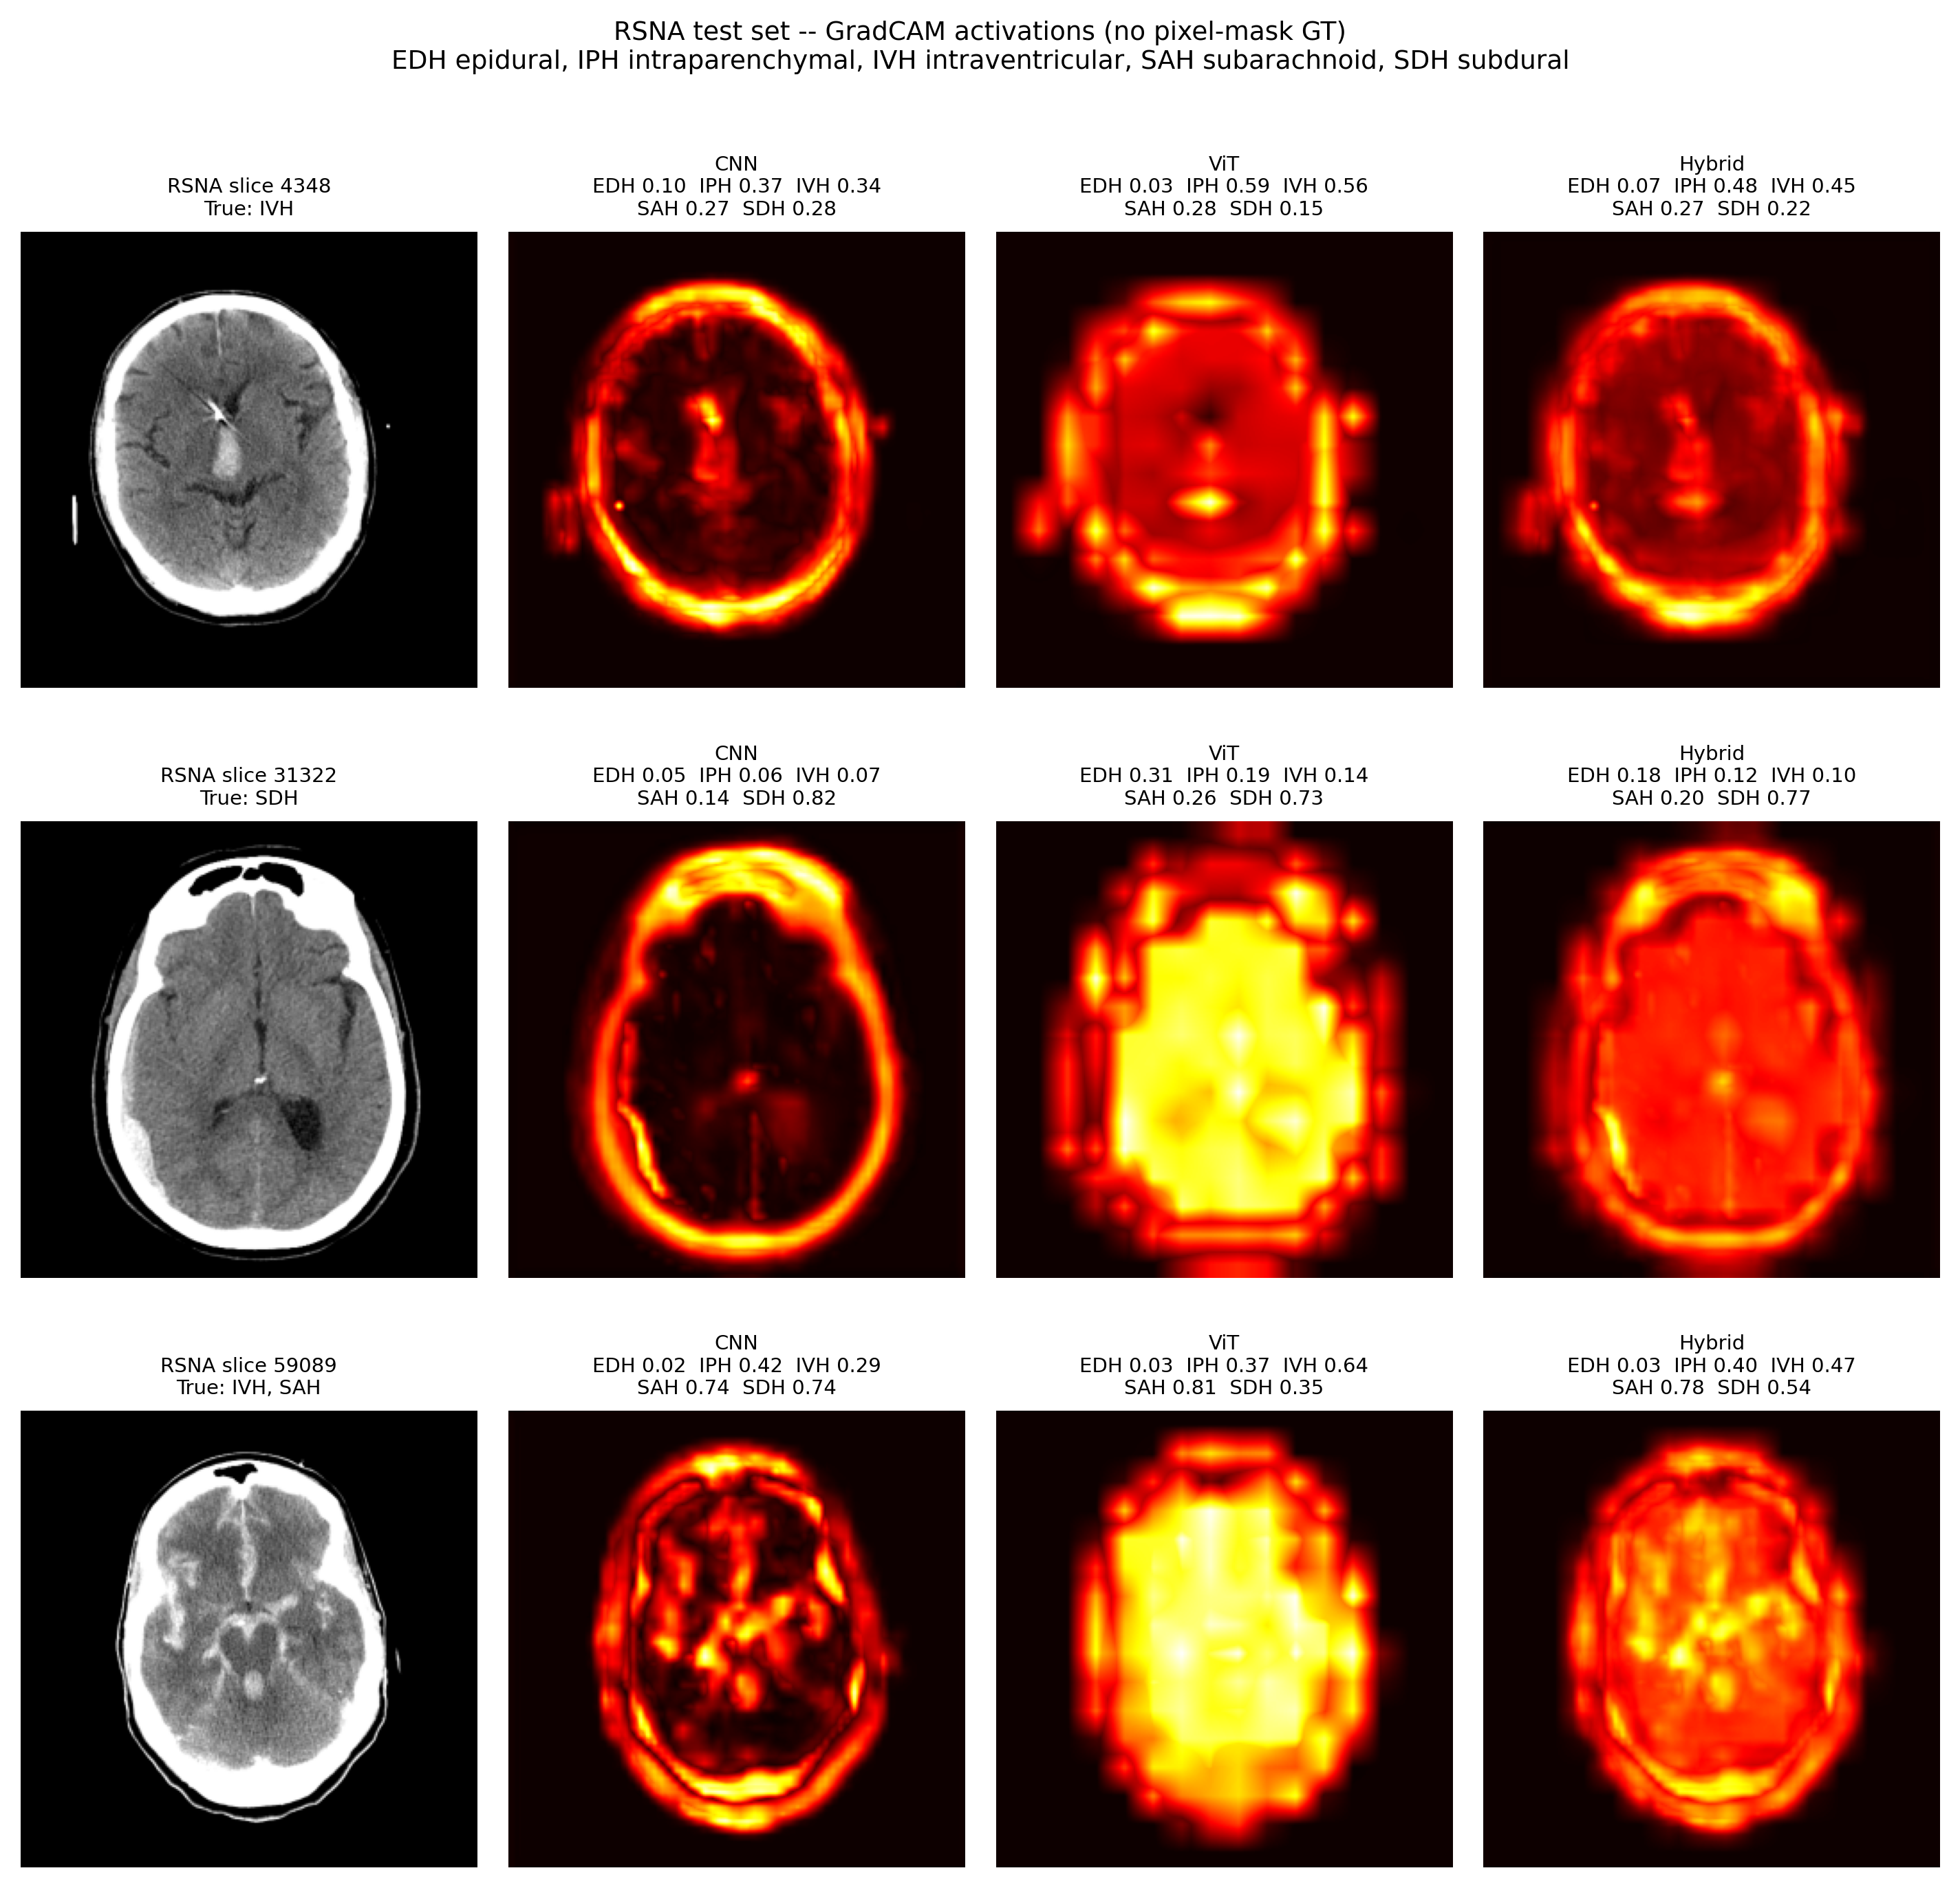

In [87]:
figures = [
    'all_comparison_bar_physionet',
    'all_comparison_bar_cq500',
    'all_comparison_dice_combined',
    'all_comparison_rsna_gradcam',
]

for name in figures:
    path = newest(f'{name}_*.png')
    print(path.name)
    display(Image(filename=str(path)))

### The full report

`all_stats_report_{ts}.txt` is the written form of every table above, including the section on how to read them and the notes carried forward from stage 7. The opening is shown; the file holds the rest.

In [88]:
report = newest('all_stats_report_*.txt').read_text()

print(report[:4000])
print(f'\n... {len(report.splitlines())} lines total, open the file for the rest')

CROSS-DATASET XAI COMPARISON -- STATISTICAL REPORT
  generated: 20260823_083800
  seed: 20260605
  img_size: 256
  cam_threshold: 0.5
  rsna_cache: rsna_tr12784_va2731_te2738_256_meta.json
  rsna_slices: 101823
  cnn_ckpt: rsna_cnn_20260722-BD_nan_auc.keras
  vit_ckpt: rsna_vit_20260713-ET_08916_auc.keras
  unet_cls_ckpt: rsna_unet_20260802-NB_nan_auc.keras
  physionet_unet: physionet_seg_maps_20260817_105446.npy
  cq500_unet: cq500_seg_maps_20260817_110225.npy
  hybrid_definition: mean of CNN and ViT probabilities / CAMs
  any_ich_score: max over the five subtype probabilities
  chance_seed: 20260606
  chance_definition: uniform random saliency map at the same threshold; its pointing game expectation is the mean lesion area fraction

  significance level: alpha = 0.05, two-sided
  multiple comparisons: Holm-Bonferroni within each test family
  CIs on a single AUC: DeLong analytic
  CIs on macro/weighted AUC: percentile bootstrap over slices (DeLong has no
   analytic form for an avera

## Discussion

The two research arms separate cleanly, and they separate in opposite directions.

**Classification degrades on new data, and the ranking inverts.** On the internal RSNA test set the three classifiers are strong and closely spaced: weighted AUCs of 0.9467 for the CNN, 0.9407 for the ViT and 0.9541 for the Hybrid. Scored zero-shot on data they have never seen, the same checkpoints fall to 0.80-0.81 on PhysioNet and 0.72-0.79 on Seg-CQ500, a loss of 0.14 to 0.22 AUC. The reordering is more instructive than the drop. The CNN is the second-best model internally and the worst of the three on Seg-CQ500, where all three pairwise DeLong comparisons are significant after Holm correction. On PhysioNet none of the three differs significantly from another, so its apparent ordering carries no weight. Internal performance is therefore an unreliable basis on which to select a model for deployment on another institution's data.

**Localisation does not follow from classification accuracy.** Every GradCAM variant scores a Dice between 0.017 and 0.059 against the pixel masks, the same order of magnitude as a uniform random saliency map thresholded identically (0.008 on PhysioNet, 0.018 on Seg-CQ500). At patient level, exactly one GradCAM comparison against Chance survives correction across both datasets: the ViT on Seg-CQ500, 0.0484 against 0.0139. The CNN never separates from Chance, and on Seg-CQ500 its mean of 0.0149 is indistinguishable from the Chance mean of 0.0139. Slice-level accuracy does not guarantee meaningful pixel-level localisation.

**Dice is the wrong instrument for a class activation map.** A CAM is produced at the spatial resolution of the final convolutional feature map and then upsampled, so it is coarse by construction and cannot trace the boundary of a small lesion however well it is centred. The pointing game and average precision are reported alongside it. The pointing game asks only whether the single strongest pixel falls inside the mask, which is a question a CAM can meaningfully answer, and its chance expectation is the mean lesion area fraction: 0.0040 on PhysioNet, 0.0091 on Seg-CQ500. On that metric the ViT reaches 0.1014 on Seg-CQ500 against an observed chance rate of 0.0175, roughly six times chance and the strongest localisation signal anywhere in these results, though with 11 test patients its interval still touches the Chance interval. Average precision orders the methods the same way.

**The U-Net marks a ceiling, not a comparison.** Dice of 0.3315 on PhysioNet and 0.3641 on Seg-CQ500, with an interval overlapping no other method on either dataset. It was trained on the distribution it is scored on, while the classifiers saw these datasets for the first time at evaluation. The comparison bounds what is achievable on these masks with this encoder, and it leaves open whether supervised segmentation beats explanation, since the two were given different information.

**PhysioNet is underpowered, and the Seg-CQ500 result carries the argument.** PhysioNet contributes 40 ICH-positive slices from 6 test patients. With 6 patients the smallest attainable two-sided Wilcoxon p is 0.031, which cannot survive correction across ten comparisons, so no PhysioNet comparison reaches significance, including the U-Net's 0.3036 against Chance at 0.0070. Its 0.00 pointing game scores are likewise indistinguishable from chance, since chance expects 0.16 hits across all 40 slices. PhysioNet should be read as consistent with the Seg-CQ500 findings, and it is too small to confirm them independently.

**Implication.** Slice-level discrimination and spatially reliable evidence are separable properties of the same model. A post-hoc CAM from an accurate classifier should be measured against a chance baseline on annotated data before it is presented as clinical justification, because these results show a model can be accurate and its explanation close to uninformative at the same time. The one partial exception, the ViT on Seg-CQ500, is also the case where the architecture differs most from the CNN encoder the segmenters reuse, which suggests the choice of architecture affects the localisation quality of the explanation independently of its accuracy. These data suggest that hypothesis without establishing it, and testing it would need a further experiment.

## Conclusion

This thesis investigated whether models that accurately detect intracranial haemorrhage also provide reliable spatial localisation for clinical interpretability. Three classifiers and a supervised segmenter were trained on the RSNA dataset and evaluated against expert radiologist annotations across two external cohorts. A uniform random saliency map was run through the same pipeline, so every metric could be read against a chance baseline.

Accuracy fell on the external data, and the CNN dropped from second place to last. Internal AUC is therefore an unreliable criterion for final model selection.

Localisation behaved as a separate property. The most accurate classifier produced heatmaps no better than random. The only explanation method to beat chance was the Vision Transformer, and only on the larger of the two external datasets. Being right about the slice did not make the model right about the pixels.

The supervised segmenter achieved Dice scores of 0.33 and 0.36 on the external datasets. This establishes the performance ceiling permitted by the annotations and encoder, rather than representing a like-for-like advantage over post-hoc explanation.

A heatmap should be tested against chance on annotated data before anyone is asked to act on it. Without that comparison, a map that means something and a map that means nothing look the same.

## Limitation

1. The U-Net had an advantage the classifiers did not. It was trained on the same datasets it was scored on, while the CNN, ViT and Hybrid saw PhysioNet and Seg-CQ500 for the first time at evaluation. Its scores mark what these masks allow with this encoder. They do not show that supervision beats explanation.

2. The localisation arm rests on few patients. PhysioNet contributed 40 ICH-positive slices from 6 test patients, Seg-CQ500 799 slices from 11. At six patients no comparison can reach significance after correction, whatever the effect size. PhysioNet therefore supports the Seg-CQ500 result rather than confirming it independently.

3. Dice was always going to be unkind to a class activation map. A CAM is computed at the resolution of the last convolutional layer and then stretched to full size, so it cannot follow a lesion edge even when it is centred correctly. The pointing game and average precision were reported because neither punishes coarseness, and the two agree with each other.

4. Every p-value quoted is the patient-level one. The slice-level tests treat slices from one patient as independent observations, which they are not, so those p-values are smaller than they should be.

5. Faithfulness was not tested. Every measure here compares a heatmap to what a radiologist drew, which Jin et al. (2023) call plausibility and place below faithfulness in their hierarchy. Establishing whether these maps track the models' own reasoning needs the model or its input perturbed, as in the prediction-saliency correlation of Zhang et al. (2024) or the weight randomisation check of Arun et al. (2021). Neither was run here.

6. Nothing here shows whether the explanations help. Overlap with a mask is not the same as changing a radiologist's decision, still less changing it in the right direction. That question needs a reader study of the kind Jin et al. (2023) describe.